<center>

# Forest Covertype Preprocessing, Tuning, Training, and Comparison

    Sample search first, full-dataset training second

</center>

## Workflow

This notebook uses the project implementation while keeping each major model in a separate cell. The workflow is:

1. Load the full UCI Covertype dataset.
2. Create an exact 20 percent full holdout split for batch models.
3. Use a stratified training sample to select feature subsets and hyperparameters quickly.
4. Train each model with its selected configuration on the full training split and save it immediately.
5. Compare full-test accuracy, Kappa, and per-class reports.
6. Evaluate stream trees sequentially over the full stream.

## Imports

In [70]:
%matplotlib inline

from pathlib import Path
import hashlib
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, f1_score, log_loss
from sklearn.model_selection import ParameterGrid, train_test_split

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from covertype_resource.data import exact_holdout_split, load_covertype
from covertype_resource.evaluation import save_json, save_model
from covertype_resource.models.distance_knn import DistanceKNNClassifier
from covertype_resource.models.knn_logeuclidean import LogEuclideanKNNClassifier
from covertype_resource.models.l1_svm_newton import L1LinearSVMNewton
from covertype_resource.models.opf import LibOPFClassifier
from covertype_resource.models.resource_rf import BudgetPrunedForestClassifier
from covertype_resource.models.scale_invariant_online import ScaleInvariantOnlineLinearClassifier
from covertype_resource.models.stream_trees import StreamTreeNBLeaves

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)


## Configuration

In [71]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
SAMPLE_TUNING_ROWS = 25_000
EXPENSIVE_TUNING_ROWS = 5_000
STREAM_TUNING_ROWS = 50_000
FULL_STREAM_REPORT_EVERY = 50_000

# Keep the fallback OPF graph bounded unless a native OPF backend is available.
OPF_FALLBACK_FULL_MAX_TRAIN = 10_000

MODEL_DIR = ROOT / "models" / "notebook_full"
TUNING_MODEL_DIR = ROOT / "models" / "notebook_tuning_cache"
REPORT_DIR = ROOT / "reports"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
TUNING_MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR


WindowsPath('c:/Users/vladm/VisualStudioCodeProjects/ATW Covertype/research/models/notebook_full')

## Load Full Dataset

In [72]:
dataset = load_covertype()
X = dataset.X
y = dataset.y

pd.DataFrame({"rows": [len(X)], "features": [X.shape[1]], "classes": [y.nunique()]})


,rows,features,classes
0,581012,54,7


## Preprocessing and Full Holdout Split

In [73]:
X_train_full, X_test_full, y_train_full, y_test_full = exact_holdout_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

wilderness_cols = [c for c in X.columns if c.startswith("Wilderness_Area")]
soil_cols = [c for c in X.columns if c.startswith("Soil_Type")]
binary_cols = wilderness_cols + soil_cols
continuous_cols = [c for c in X.columns if c not in binary_cols]

split_table = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train_full), len(X_test_full)],
        "percent": [80.0, 20.0],
    }
)
split_table


,split,rows,percent
0,train,464809,80.0
1,test,116203,20.0


## Sample for Fast Configuration Search

In [74]:
sample_rows = min(SAMPLE_TUNING_ROWS, len(X_train_full))
X_sample, _, y_sample, _ = train_test_split(
    X_train_full,
    y_train_full,
    train_size=sample_rows,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

X_tune_train, X_tune_valid, y_tune_train, y_tune_valid = train_test_split(
    X_sample,
    y_sample,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_sample,
)

pd.DataFrame(
    {
        "dataset": ["sample", "sample_train", "sample_valid"],
        "rows": [len(X_sample), len(X_tune_train), len(X_tune_valid)],
    }
)


,dataset,rows
0,sample,25000
1,sample_train,18750
2,sample_valid,6250


## Sample Feature Selection

In [75]:
discrete_mask = np.array([col in binary_cols for col in X.columns])
mi_scores = pd.Series(
    mutual_info_classif(
        X_sample,
        y_sample,
        discrete_features=discrete_mask,
        random_state=RANDOM_STATE,
    ),
    index=X.columns,
).sort_values(ascending=False)

feature_sets = {
    "all": list(X.columns),
    "top20_mi": list(mi_scores.head(20).index),
    "top35_mi": list(mi_scores.head(35).index),
    "continuous_plus_wilderness": continuous_cols + wilderness_cols,
}

mi_scores.head(20).to_frame("mutual_information")


,mutual_information
Elevation,0.453237
Wilderness_Area4,0.145564
Horizontal_Distance_To_Roadways,0.090302
Wilderness_Area1,0.066459
Soil_Type10,0.064647
Horizontal_Distance_To_Fire_Points,0.064425
Slope,0.041925
Soil_Type39,0.029521
Soil_Type38,0.029519
Soil_Type29,0.029158


## Domain-Specific Feature Engineering

These features come from the additional tree/deep-learning prompt. They are added as a separate feature table so the original resource-aware experiments remain comparable. Tree models receive these raw engineered features. Deep tabular models use quantile-normalized continuous variables later.

In [76]:
def add_domain_features(X_in):
    X_out = X_in.copy()
    horizontal_hydrology = X_out["Horizontal_Distance_To_Hydrology"]
    vertical_hydrology = X_out["Vertical_Distance_To_Hydrology"]
    fire_distance = X_out["Horizontal_Distance_To_Fire_Points"]
    road_distance = X_out["Horizontal_Distance_To_Roadways"]

    X_out["Euclidean_Distance_To_Hydrology"] = np.sqrt(horizontal_hydrology**2 + vertical_hydrology**2)
    X_out["Mean_Hydrology_Fire_Distance"] = (horizontal_hydrology + fire_distance) / 2.0
    X_out["Mean_Hydrology_Roadway_Distance"] = (horizontal_hydrology + road_distance) / 2.0
    X_out["Mean_Roadway_Fire_Distance"] = (road_distance + fire_distance) / 2.0
    X_out["Estimated_Water_Source_Elevation"] = X_out["Elevation"] - vertical_hydrology
    return X_out


X_domain = add_domain_features(X)
X_train_full_domain = X_domain.loc[X_train_full.index]
X_test_full_domain = X_domain.loc[X_test_full.index]
X_sample_domain = X_domain.loc[X_sample.index]
X_tune_train_domain = X_domain.loc[X_tune_train.index]
X_tune_valid_domain = X_domain.loc[X_tune_valid.index]

engineered_cols = [
    "Euclidean_Distance_To_Hydrology",
    "Mean_Hydrology_Fire_Distance",
    "Mean_Hydrology_Roadway_Distance",
    "Mean_Roadway_Fire_Distance",
    "Estimated_Water_Source_Elevation",
]
continuous_cols_domain = continuous_cols + engineered_cols
binary_cols_domain = binary_cols

pd.DataFrame(
    {
        "engineered_feature": engineered_cols,
        "description": [
            "Direct spatial distance to water from horizontal and vertical hydrology distances",
            "Mean of horizontal hydrology and fire-point distances",
            "Mean of horizontal hydrology and roadway distances",
            "Mean of roadway and fire-point distances",
            "Estimated elevation of nearest water source",
        ],
    }
)


,engineered_feature,description
0,Euclidean_Distance_To_Hydrology,Direct spatial distance to water from horizont...
1,Mean_Hydrology_Fire_Distance,Mean of horizontal hydrology and fire-point di...
2,Mean_Hydrology_Roadway_Distance,Mean of horizontal hydrology and roadway dista...
3,Mean_Roadway_Fire_Distance,Mean of roadway and fire-point distances
4,Estimated_Water_Source_Elevation,Estimated elevation of nearest water source


In [77]:
domain_discrete_mask = np.array([col in binary_cols_domain for col in X_domain.columns])
mi_scores_domain = pd.Series(
    mutual_info_classif(
        X_sample_domain,
        y_sample,
        discrete_features=domain_discrete_mask,
        random_state=RANDOM_STATE,
    ),
    index=X_domain.columns,
).sort_values(ascending=False)

feature_sets_domain = {
    "domain_all": list(X_domain.columns),
    "domain_top30_mi": list(mi_scores_domain.head(30).index),
    "domain_top40_mi": list(mi_scores_domain.head(40).index),
    "domain_top45_mi": list(mi_scores_domain.head(45).index),
    "domain_all_without_rare_soils": [c for c in X_domain.columns if c not in rare_soil_cols] if "rare_soil_cols" in globals() else list(X_domain.columns),
}

mi_scores_domain.head(20).to_frame("mutual_information_with_engineered_features")


,mutual_information_with_engineered_features
Estimated_Water_Source_Elevation,0.531700
Elevation,0.458047
Wilderness_Area4,0.145564
Mean_Roadway_Fire_Distance,0.138738
Mean_Hydrology_Roadway_Distance,0.101954
Horizontal_Distance_To_Roadways,0.089718
Mean_Hydrology_Fire_Distance,0.080689
Wilderness_Area1,0.066459
Soil_Type10,0.064647
Horizontal_Distance_To_Fire_Points,0.058988


## Helpers for Tuning and Evaluation

In [78]:
def evaluate_predictions(y_true, y_pred, y_proba=None, labels=None):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "classification_report": classification_report(y_true, y_pred, output_dict=True, zero_division=0),
    }
    if y_proba is not None:
        try:
            metrics["log_loss"] = float(log_loss(y_true, y_proba, labels=labels))
        except ValueError as exc:
            metrics["log_loss_error"] = str(exc)
    return metrics


def add_tuning_row(rows, model_name, feature_set, params, metrics, seconds):
    row = {
        "model": model_name,
        "feature_set": feature_set,
        "accuracy": metrics["accuracy"],
        "kappa": metrics["kappa"],
        "macro_f1": metrics.get("macro_f1"),
        "weighted_f1": metrics.get("weighted_f1"),
        "log_loss": metrics.get("log_loss"),
        "seconds": round(seconds, 3),
    }
    row.update(params)
    rows.append(row)


def best_rows(tuning_df):
    return (
        tuning_df.sort_values(["model", "accuracy", "kappa"], ascending=[True, False, False])
        .groupby("model", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )


def get_best_config(config_table, model_name):
    row = config_table.loc[config_table["model"] == model_name]
    if row.empty:
        raise KeyError(f"No best configuration found for {model_name}")
    return row.iloc[0].to_dict()


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in sorted(value.items(), key=lambda item: str(item[0]))}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, float) and np.isnan(value):
        return None
    return value


def make_cache_payload(model_name, feature_set, params, tuning_pass, feature_columns=None):
    return {
        "model_name": model_name,
        "feature_set": feature_set,
        "params": json_safe(params),
        "tuning_pass": tuning_pass,
        "random_state": RANDOM_STATE,
        "sample_rows": int(sample_rows) if "sample_rows" in globals() else None,
        "expensive_tuning_rows": int(EXPENSIVE_TUNING_ROWS) if "EXPENSIVE_TUNING_ROWS" in globals() else None,
        "feature_columns": list(feature_columns) if feature_columns is not None else None,
    }


def tuning_model_cache_path(model_name, feature_set, params, tuning_pass, feature_columns=None, suffix=".joblib"):
    payload = make_cache_payload(model_name, feature_set, params, tuning_pass, feature_columns)
    payload_json = json.dumps(payload, sort_keys=True, default=str)
    digest = hashlib.sha1(payload_json.encode("utf-8")).hexdigest()[:16]
    safe_name = model_name.replace("/", "_").replace(" ", "_")
    return TUNING_MODEL_DIR / f"{tuning_pass}__{safe_name}__{feature_set}__{digest}{suffix}"


def quarantine_bad_cache(path, exc):
    quarantine_path = path.with_name(f"{path.name}.corrupt_{int(time.time())}")
    try:
        path.replace(quarantine_path)
        print(f"Cache load failed for {path.name}; moved it to {quarantine_path.name} and retraining. Reason: {exc}")
    except OSError as move_exc:
        print(f"Cache load failed for {path.name}; could not move it ({move_exc}). Retraining will overwrite via atomic save. Reason: {exc}")
    return quarantine_path


def fit_or_load_tuning_model(model_name, feature_set, params, tuning_pass, feature_columns, fit_fn, suffix=".joblib"):
    path = tuning_model_cache_path(model_name, feature_set, params, tuning_pass, feature_columns, suffix=suffix)
    if path.exists():
        try:
            return joblib.load(path), path, True
        except Exception as exc:
            quarantine_bad_cache(path, exc)
    model = fit_fn()
    save_model(model, path)
    return model, path, False



tuning_rows = []
full_results = []
full_reports = {}


## Tuning Model Cache

Every sample-tuning model is saved immediately after it is trained in `models/notebook_tuning_cache/`. The cache filename is built from the model name, tuning pass, feature set, selected feature columns, random seed, and parameter values. If the same cell is run again with the same parameters, the notebook loads the model from disk and marks the row with `cache_loaded=True` instead of training it again. Final full-dataset models are saved in `models/notebook_full/` and loaded back on reruns when the selected configuration and feature columns match the saved metadata. Existing legacy full models without metadata are loaded once and assigned metadata for future exact checks.


## Tune Random Forest and BUDGETPRUNE on the Sample

In [79]:
rf_grid = ParameterGrid(
    {
        "feature_set": ["all", "top35_mi"],
        "max_features": ["sqrt", 0.5],
        "min_samples_leaf": [1, 3],
    }
)

for params in rf_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_rf_first_pass():
        model = RandomForestClassifier(
            n_estimators=40,
            criterion="entropy",
            max_features=params["max_features"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(X_tune_train[cols], y_tune_train)
        return model

    rf, rf_cache_path, rf_loaded = fit_or_load_tuning_model(
        "random_forest_entropy_40",
        params["feature_set"],
        {**params, "n_estimators": 40, "criterion": "entropy"},
        "first_pass",
        cols,
        fit_rf_first_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, rf.predict(X_tune_valid[cols]))
    row_params = {**params, "n_estimators": 40, "cache_path": str(rf_cache_path), "cache_loaded": rf_loaded}
    add_tuning_row(tuning_rows, "random_forest_entropy_40", params["feature_set"], row_params, metrics, time.perf_counter() - started)

    for cost_penalty, budget_fraction in [(0.005, 0.65), (0.01, 0.80), (0.02, 1.0)]:
        started = time.perf_counter()
        budget = max(1, int(round(len(cols) * budget_fraction)))
        tune_params = dict(params)
        tune_params.update({"cost_penalty": cost_penalty, "budget_fraction": budget_fraction, "budget": budget, "min_trees": 5, "n_estimators": 40})

        def fit_pruned_first_pass():
            model = BudgetPrunedForestClassifier(
                forest=rf,
                budget=budget,
                cost_penalty=cost_penalty,
                min_trees=5,
                solver="milp",
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
            model.fit(X_tune_train[cols], y_tune_train, X_val=X_tune_valid[cols], y_val=y_tune_valid)
            return model

        pruned, pruned_cache_path, pruned_loaded = fit_or_load_tuning_model(
            "budgetpruned_random_forest",
            params["feature_set"],
            tune_params,
            "first_pass",
            cols,
            fit_pruned_first_pass,
        )
        metrics = evaluate_predictions(y_tune_valid, pruned.predict(X_tune_valid[cols]))
        tune_params.update({"cache_path": str(pruned_cache_path), "cache_loaded": pruned_loaded})
        add_tuning_row(tuning_rows, "budgetpruned_random_forest", params["feature_set"], tune_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model in ['random_forest_entropy_40', 'budgetpruned_random_forest']").sort_values("accuracy", ascending=False).head(12)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees
11,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.117,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.020,1.00,54.0,5.0
10,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.114,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.010,0.80,43.0,5.0
9,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.119,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,35.0,5.0
8,random_forest_entropy_40,all,0.85536,0.764596,0.767584,0.853036,None,0.062,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN
24,random_forest_entropy_40,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.061,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN
25,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.116,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,23.0,5.0
26,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.113,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.010,0.80,28.0,5.0
27,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.108,0.5,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.020,1.00,35.0,5.0
12,random_forest_entropy_40,all,0.84496,0.746919,0.750740,0.841489,None,0.057,0.5,3,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,all,0.84496,0.746470,0.727623,0.841114,None,0.132,sqrt,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,35.0,5.0


## Tune Scale-Invariant Online Linear Model on the Sample

In [80]:
online_grid = ParameterGrid(
    {
        "feature_set": ["all", "top35_mi", "continuous_plus_wilderness"],
        "epochs": [1, 2],
    }
)

for params in online_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_online_first_pass():
        model = ScaleInvariantOnlineLinearClassifier(
            epochs=params["epochs"],
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        model.fit(X_tune_train[cols], y_tune_train)
        return model

    online, cache_path, cache_loaded = fit_or_load_tuning_model(
        "scale_invariant_online_linear",
        params["feature_set"],
        params,
        "first_pass",
        cols,
        fit_online_first_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, online.predict(X_tune_valid[cols]))
    row_params = {**params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(tuning_rows, "scale_invariant_online_linear", params["feature_set"], row_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model == 'scale_invariant_online_linear'").sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs
32,scale_invariant_online_linear,all,0.66912,0.454006,0.533587,0.655930,None,0.048,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0
33,scale_invariant_online_linear,top35_mi,0.66528,0.443991,0.521517,0.649901,None,0.044,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0
35,scale_invariant_online_linear,all,0.65936,0.426148,0.418956,0.629454,None,0.043,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,2.0
36,scale_invariant_online_linear,top35_mi,0.65456,0.414374,0.404039,0.619866,None,0.043,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,2.0
34,scale_invariant_online_linear,continuous_plus_wilderness,0.64384,0.393429,0.295463,0.616170,None,0.043,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0
37,scale_invariant_online_linear,continuous_plus_wilderness,0.62336,0.334112,0.264087,0.577006,None,0.044,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,2.0


## Tune L1 SVM with Active-Set Newton on the Sample

In [81]:
l1_rows = min(EXPENSIVE_TUNING_ROWS, len(X_tune_train))
X_l1_train, _, y_l1_train, _ = train_test_split(
    X_tune_train,
    y_tune_train,
    train_size=l1_rows,
    random_state=RANDOM_STATE,
    stratify=y_tune_train,
)

l1_grid = ParameterGrid(
    {
        "feature_set": ["top20_mi", "top35_mi", "all"],
        "C": [0.5, 1.0],
        "alpha": [1e-3, 5e-3],
    }
)

for params in l1_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_l1_first_pass():
        model = L1LinearSVMNewton(C=params["C"], alpha=params["alpha"], max_iter=40, random_state=RANDOM_STATE)
        model.fit(X_l1_train[cols], y_l1_train)
        return model

    svm, cache_path, cache_loaded = fit_or_load_tuning_model(
        "l1_svm_newton_active_set",
        params["feature_set"],
        {**params, "train_rows": int(l1_rows)},
        "first_pass",
        cols,
        fit_l1_first_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, svm.predict(X_tune_valid[cols]))
    row_params = {**params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(tuning_rows, "l1_svm_newton_active_set", params["feature_set"], row_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model == 'l1_svm_newton_active_set'").sort_values("accuracy", ascending=False).head(12)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha
38,l1_svm_newton_active_set,top20_mi,0.69648,0.494141,0.356577,0.672436,None,0.014,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.001
44,l1_svm_newton_active_set,top20_mi,0.69632,0.494091,0.357369,0.672485,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,1.0,0.001
47,l1_svm_newton_active_set,top20_mi,0.69424,0.488961,0.336542,0.667475,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,1.0,0.005
41,l1_svm_newton_active_set,top20_mi,0.69360,0.485844,0.315038,0.662717,None,0.013,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.005
39,l1_svm_newton_active_set,top35_mi,0.68752,0.480377,0.365090,0.666218,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.001
40,l1_svm_newton_active_set,all,0.68144,0.471264,0.391815,0.669083,None,0.013,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.001
43,l1_svm_newton_active_set,all,0.67536,0.456073,0.319151,0.646837,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.005
42,l1_svm_newton_active_set,top35_mi,0.67504,0.454078,0.310779,0.644892,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.005
46,l1_svm_newton_active_set,all,0.66720,0.457644,0.341286,0.646595,None,0.015,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,1.0,0.001
48,l1_svm_newton_active_set,top35_mi,0.66432,0.451086,0.357269,0.642364,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,1.0,0.005


## Tune OPF on the Sample

In [82]:
opf_rows = min(EXPENSIVE_TUNING_ROWS, len(X_tune_train))
X_opf_train, _, y_opf_train, _ = train_test_split(
    X_tune_train,
    y_tune_train,
    train_size=opf_rows,
    random_state=RANDOM_STATE,
    stratify=y_tune_train,
)

for feature_set in ["top20_mi", "top35_mi", "continuous_plus_wilderness"]:
    cols = feature_sets[feature_set]
    params = {"feature_set": feature_set, "max_train_samples": min(3000, len(X_opf_train)), "train_rows": int(opf_rows)}
    started = time.perf_counter()

    def fit_opf_first_pass():
        model = LibOPFClassifier(backend="auto", max_train_samples=params["max_train_samples"], random_state=RANDOM_STATE)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_opf_train[cols], y_opf_train)
        return model

    opf, cache_path, cache_loaded = fit_or_load_tuning_model(
        "opf_log_euclidean",
        feature_set,
        params,
        "first_pass",
        cols,
        fit_opf_first_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, opf.predict(X_tune_valid[cols]))
    row_params = {**params, "backend": opf.backend_, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(tuning_rows, "opf_log_euclidean", feature_set, row_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model == 'opf_log_euclidean'").sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend
51,opf_log_euclidean,top35_mi,0.64016,0.417252,0.528165,0.639623,None,0.233,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,5000.0,fallback_complete_graph_opf
50,opf_log_euclidean,top20_mi,0.62016,0.386784,0.482100,0.619580,None,0.228,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,5000.0,fallback_complete_graph_opf
52,opf_log_euclidean,continuous_plus_wilderness,0.57056,0.309587,0.431542,0.570399,None,0.231,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,5000.0,fallback_complete_graph_opf


## Tune k-NN with Leave-One-Out k Selection on the Sample

In [83]:
knn_rows = min(EXPENSIVE_TUNING_ROWS, len(X_tune_train))
X_knn_train, _, y_knn_train, _ = train_test_split(
    X_tune_train,
    y_tune_train,
    train_size=knn_rows,
    random_state=RANDOM_STATE,
    stratify=y_tune_train,
)

for feature_set in ["top20_mi", "top35_mi", "continuous_plus_wilderness"]:
    cols = feature_sets[feature_set]
    params = {"feature_set": feature_set, "k_values": [1, 3, 5], "train_rows": int(knn_rows), "weights": "uniform"}
    started = time.perf_counter()

    def fit_knn_first_pass():
        model = LogEuclideanKNNClassifier(k_values=(1, 3, 5), n_jobs=1)
        model.fit(X_knn_train[cols], y_knn_train)
        return model

    knn, cache_path, cache_loaded = fit_or_load_tuning_model(
        "knn_log_euclidean_loocv",
        feature_set,
        params,
        "first_pass",
        cols,
        fit_knn_first_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, knn.predict(X_tune_valid[cols]))
    row_params = {"feature_set": feature_set, "best_k": knn.best_k_, "weights": "uniform", "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(tuning_rows, "knn_log_euclidean_loocv", feature_set, row_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model == 'knn_log_euclidean_loocv'").sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights
54,knn_log_euclidean_loocv,top35_mi,0.67920,0.481478,0.550500,0.678910,None,0.045,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform
53,knn_log_euclidean_loocv,top20_mi,0.65200,0.421310,0.485702,0.644866,None,0.044,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,uniform
55,knn_log_euclidean_loocv,continuous_plus_wilderness,0.60272,0.360033,0.453222,0.601970,None,0.106,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform


## Tune Stream Tree on a Prefix of the Stream

In [84]:
stream_prefix = min(STREAM_TUNING_ROWS, len(X))
X_stream_tune = X.iloc[:stream_prefix]
y_stream_tune = y.iloc[:stream_prefix]

stream_grid = ParameterGrid(
    {
        "grace_period": [100, 200],
        "delta": [1e-7, 1e-5],
    }
)

for params in stream_grid:
    started = time.perf_counter()
    stream_params = {**params, "leaf_prediction": "nb", "stream_rows": int(stream_prefix)}

    def fit_stream_first_pass():
        model = StreamTreeNBLeaves(
            tree_type="efdt",
            grace_period=params["grace_period"],
            delta=params["delta"],
            leaf_prediction="nb",
            report_every=10_000,
        )
        model.fit_prequential(X_stream_tune, y_stream_tune)
        return model

    stream_model, cache_path, cache_loaded = fit_or_load_tuning_model(
        "efdt_nb_leaves",
        "all",
        stream_params,
        "first_pass",
        X.columns,
        fit_stream_first_pass,
    )
    metrics = {"accuracy": stream_model.final_metrics_["accuracy"], "kappa": stream_model.final_metrics_["kappa"]}
    row_params = {**stream_params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(tuning_rows, "efdt_nb_leaves", "all", row_params, metrics, time.perf_counter() - started)

pd.DataFrame(tuning_rows).query("model == 'efdt_nb_leaves'").sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows
56,efdt_nb_leaves,all,0.54910,0.350398,NaN,NaN,None,0.375,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,100.0,nb,50000.0
57,efdt_nb_leaves,all,0.52202,0.328083,NaN,NaN,None,0.355,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,200.0,nb,50000.0
58,efdt_nb_leaves,all,0.21008,0.077302,NaN,NaN,None,0.152,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-05,100.0,nb,50000.0
59,efdt_nb_leaves,all,0.20704,0.085300,NaN,NaN,None,0.150,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-05,200.0,nb,50000.0


## Select Best Sample Configurations

In [85]:
tuning_results = pd.DataFrame(tuning_rows)
best_by_model = best_rows(tuning_results)
overall_sample_best = tuning_results.sort_values(["accuracy", "kappa"], ascending=False).head(10)

display(best_by_model.sort_values("accuracy", ascending=False))
overall_sample_best


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows
0,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.119,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,35.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,random_forest_entropy_40,all,0.85536,0.764596,0.767584,0.853036,None,0.062,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,l1_svm_newton_active_set,top20_mi,0.69648,0.494141,0.356577,0.672436,None,0.014,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,knn_log_euclidean_loocv,top35_mi,0.67920,0.481478,0.550500,0.678910,None,0.045,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN,NaN,NaN
6,scale_invariant_online_linear,all,0.66912,0.454006,0.533587,0.655930,None,0.048,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,opf_log_euclidean,top35_mi,0.64016,0.417252,0.528165,0.639623,None,0.233,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,5000.0,fallback_complete_graph_opf,NaN,NaN,NaN,NaN,NaN,NaN
1,efdt_nb_leaves,all,0.54910,0.350398,NaN,NaN,None,0.375,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,100.0,nb,50000.0


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows
8,random_forest_entropy_40,all,0.85536,0.764596,0.767584,0.853036,None,0.062,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.119,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,35.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.114,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.010,0.80,43.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.117,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.020,1.00,54.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,random_forest_entropy_40,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.061,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.116,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,23.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.113,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.010,0.80,28.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,budgetpruned_random_forest,top35_mi,0.84912,0.754352,0.767095,0.846543,None,0.108,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.020,1.00,35.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,random_forest_entropy_40,all,0.84496,0.746919,0.750740,0.841489,None,0.057,0.5,3.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,random_forest_entropy_40,all,0.84496,0.746470,0.727623,0.841114,None,0.084,sqrt,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


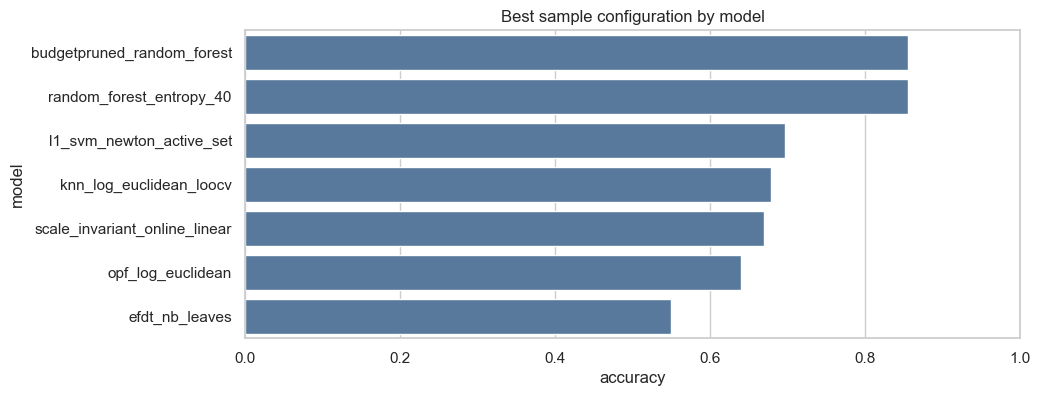

,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows
0,budgetpruned_random_forest,all,0.85536,0.764596,0.767584,0.853036,None,0.119,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.005,0.65,35.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,efdt_nb_leaves,all,0.54910,0.350398,NaN,NaN,None,0.375,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,100.0,nb,50000.0
2,knn_log_euclidean_loocv,top35_mi,0.67920,0.481478,0.550500,0.678910,None,0.045,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN,NaN,NaN
3,l1_svm_newton_active_set,top20_mi,0.69648,0.494141,0.356577,0.672436,None,0.014,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.5,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,opf_log_euclidean,top35_mi,0.64016,0.417252,0.528165,0.639623,None,0.233,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,5000.0,fallback_complete_graph_opf,NaN,NaN,NaN,NaN,NaN,NaN
5,random_forest_entropy_40,all,0.85536,0.764596,0.767584,0.853036,None,0.062,0.5,1.0,40.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,scale_invariant_online_linear,all,0.66912,0.454006,0.533587,0.655930,None,0.048,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
tuning_results.to_csv(REPORT_DIR / "notebook_sample_tuning_results.csv", index=False)
best_by_model.to_csv(REPORT_DIR / "notebook_best_sample_configs.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = best_by_model.sort_values("accuracy", ascending=False)
sns.barplot(data=plot_df, y="model", x="accuracy", color="#4c78a8", ax=ax)
ax.set_title("Best sample configuration by model")
ax.set_xlim(0, 1)
plt.show()

# If the second-pass section is skipped, full training uses the first-pass best configs.
best_by_model_for_full_training = best_by_model.copy()
best_by_model_for_full_training


## Second-Pass Sample Tuning After Observing First Results

The first tuning pass showed that Random Forest and BUDGETPRUNE are strongest, `all` and `top35_mi` are the best feature sets, k-NN prefers `top35_mi`, and several best values sit at the edge of the first grid. The cells below run a focused second pass using those observations. The results are saved with `second_pass` in the file names so they do not overwrite the first-pass CSV files.

In [87]:
# Extra feature sets motivated by the first-pass results.
rare_soil_threshold = 500
rare_soil_cols = X[soil_cols].sum()[lambda counts: counts < rare_soil_threshold].index.tolist()

feature_sets.update(
    {
        "top15_mi": list(mi_scores.head(15).index),
        "top25_mi": list(mi_scores.head(25).index),
        "top30_mi": list(mi_scores.head(30).index),
        "top40_mi": list(mi_scores.head(40).index),
        "top45_mi": list(mi_scores.head(45).index),
        "all_without_rare_soils": [c for c in X.columns if c not in rare_soil_cols],
    }
)

pd.DataFrame(
    {
        "feature_set": ["top15_mi", "top25_mi", "top30_mi", "top35_mi", "top40_mi", "top45_mi", "all", "all_without_rare_soils"],
        "n_features": [len(feature_sets[name]) for name in ["top15_mi", "top25_mi", "top30_mi", "top35_mi", "top40_mi", "top45_mi", "all", "all_without_rare_soils"]],
    }
)


,feature_set,n_features
0,top15_mi,15
1,top25_mi,25
2,top30_mi,30
3,top35_mi,35
4,top40_mi,40
5,top45_mi,45
6,all,54
7,all_without_rare_soils,48


In [88]:
second_pass_rows = []
second_pass_notes = {
    "reason": "Focused grids added after observing first-pass sample tuning results.",
    "first_pass_best_csv": str(REPORT_DIR / "notebook_best_sample_configs.csv"),
}


### Second-Pass Random Forest Search

The first pass favored `max_features=0.5`, `min_samples_leaf=1`, and all features. This second pass tests nearby `max_features` values, a slightly larger forest, and feature sets around `top35_mi`.

In [89]:
rf_second_grid = list(
    ParameterGrid(
        {
            "feature_set": ["all", "top35_mi", "top40_mi", "top45_mi", "all_without_rare_soils"],
            "max_features": [0.4, 0.5, 0.6, 0.75],
            "min_samples_leaf": [1, 2],
            "n_estimators": [40, 80],
            "max_depth": [None],
        }
    )
)

for params in rf_second_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_rf_second_pass():
        model = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            criterion="entropy",
            max_features=params["max_features"],
            min_samples_leaf=params["min_samples_leaf"],
            max_depth=params["max_depth"],
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(X_tune_train[cols], y_tune_train)
        return model

    rf, cache_path, cache_loaded = fit_or_load_tuning_model(
        "random_forest_entropy_40",
        params["feature_set"],
        params,
        "second_pass",
        cols,
        fit_rf_second_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, rf.predict(X_tune_valid[cols]))
    row_params = {**params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(
        second_pass_rows,
        "random_forest_entropy_40",
        params["feature_set"],
        row_params,
        metrics,
        time.perf_counter() - started,
    )

rf_second_results = pd.DataFrame(second_pass_rows).query("model == 'random_forest_entropy_40'").sort_values("accuracy", ascending=False)
rf_second_results.head(12)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_depth,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded
49,random_forest_entropy_40,top45_mi,0.86016,0.772115,0.766350,0.857172,None,0.105,None,0.40,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
48,random_forest_entropy_40,top45_mi,0.85968,0.771482,0.765207,0.856984,None,0.056,None,0.40,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
73,random_forest_entropy_40,all_without_rare_soils,0.85904,0.770600,0.779072,0.856594,None,0.104,None,0.60,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
57,random_forest_entropy_40,top45_mi,0.85856,0.769877,0.781415,0.856414,None,0.098,None,0.60,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
5,random_forest_entropy_40,all,0.85824,0.769028,0.772675,0.855420,None,0.100,None,0.50,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
65,random_forest_entropy_40,all_without_rare_soils,0.85760,0.767894,0.768534,0.854711,None,0.121,None,0.40,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
56,random_forest_entropy_40,top45_mi,0.85712,0.767472,0.781936,0.855038,None,0.055,None,0.60,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
52,random_forest_entropy_40,top45_mi,0.85664,0.766735,0.777752,0.854371,None,0.056,None,0.50,1,40,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
41,random_forest_entropy_40,top40_mi,0.85648,0.766400,0.778177,0.854177,None,0.105,None,0.60,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
45,random_forest_entropy_40,top40_mi,0.85648,0.766533,0.778640,0.854234,None,0.099,None,0.75,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True


### Second-Pass BUDGETPRUNE Search

BUDGETPRUNE matched the Random Forest in the first pass. Here we prune the best second-pass forest candidates with stricter feature budgets and several cost penalties to see how much feature acquisition cost can be reduced before accuracy drops.

In [90]:
top_rf_for_pruning = rf_second_results.head(4).to_dict(orient="records")
prune_second_grid = list(
    ParameterGrid(
        {
            "cost_penalty": [0.001, 0.003, 0.005, 0.01, 0.03],
            "budget_fraction": [0.35, 0.50, 0.65, 0.80, 1.0],
            "min_trees": [5, 10],
        }
    )
)

for rf_params in top_rf_for_pruning:
    cols = feature_sets[rf_params["feature_set"]]

    def fit_base_rf_for_pruning():
        model = RandomForestClassifier(
            n_estimators=int(rf_params["n_estimators"]),
            criterion="entropy",
            max_features=float(rf_params["max_features"]),
            min_samples_leaf=int(rf_params["min_samples_leaf"]),
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(X_tune_train[cols], y_tune_train)
        return model

    base_rf_params = {
        "feature_set": rf_params["feature_set"],
        "max_features": rf_params["max_features"],
        "min_samples_leaf": rf_params["min_samples_leaf"],
        "n_estimators": rf_params["n_estimators"],
        "max_depth": rf_params["max_depth"],
    }
    base_rf, base_rf_cache_path, base_rf_loaded = fit_or_load_tuning_model(
        "random_forest_entropy_40",
        rf_params["feature_set"],
        base_rf_params,
        "second_pass",
        cols,
        fit_base_rf_for_pruning,
    )

    for prune_params in prune_second_grid:
        started = time.perf_counter()
        budget = max(1, int(round(len(cols) * prune_params["budget_fraction"])))
        params = {
            "feature_set": rf_params["feature_set"],
            "max_features": rf_params["max_features"],
            "min_samples_leaf": rf_params["min_samples_leaf"],
            "n_estimators": rf_params["n_estimators"],
            "max_depth": rf_params["max_depth"],
            "budget": budget,
            **prune_params,
        }

        def fit_pruned_second_pass():
            model = BudgetPrunedForestClassifier(
                forest=base_rf,
                budget=budget,
                cost_penalty=prune_params["cost_penalty"],
                min_trees=prune_params["min_trees"],
                solver="milp",
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
            model.fit(X_tune_train[cols], y_tune_train, X_val=X_tune_valid[cols], y_val=y_tune_valid)
            return model

        pruned, cache_path, cache_loaded = fit_or_load_tuning_model(
            "budgetpruned_random_forest",
            rf_params["feature_set"],
            params,
            "second_pass",
            cols,
            fit_pruned_second_pass,
        )
        metrics = evaluate_predictions(y_tune_valid, pruned.predict(X_tune_valid[cols]))
        row_params = {**params, "base_rf_cache_path": str(base_rf_cache_path), "base_rf_cache_loaded": base_rf_loaded, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
        add_tuning_row(
            second_pass_rows,
            "budgetpruned_random_forest",
            rf_params["feature_set"],
            row_params,
            metrics,
            time.perf_counter() - started,
        )

pd.DataFrame(second_pass_rows).query("model == 'budgetpruned_random_forest'").sort_values(["accuracy", "budget"], ascending=[False, True]).head(15)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_depth,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,budget,budget_fraction,cost_penalty,min_trees,base_rf_cache_path,base_rf_cache_loaded
100,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.214,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.001,5.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
101,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.242,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.001,10.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
102,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.240,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.003,5.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
103,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.205,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.003,10.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
104,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.202,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.005,5.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
105,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.208,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.005,10.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
106,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.218,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.010,5.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
107,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.225,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.010,10.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
108,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.199,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.030,5.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True
109,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.76635,0.857172,None,0.207,None,0.4,1,80,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,29.0,0.65,0.030,10.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True


### Second-Pass Online Linear and L1 SVM Search

The online model preferred all features and one epoch. L1 SVM preferred a small feature subset and the smallest regularization values tested. This pass checks nearby feature sizes and smaller L1 penalties.

In [91]:
online_second_grid = list(
    ParameterGrid(
        {
            "feature_set": ["all", "top40_mi", "top45_mi", "all_without_rare_soils"],
            "epochs": [1, 2, 3],
        }
    )
)

for params in online_second_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_online_second_pass():
        model = ScaleInvariantOnlineLinearClassifier(
            epochs=params["epochs"],
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        model.fit(X_tune_train[cols], y_tune_train)
        return model

    online, cache_path, cache_loaded = fit_or_load_tuning_model(
        "scale_invariant_online_linear",
        params["feature_set"],
        params,
        "second_pass",
        cols,
        fit_online_second_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, online.predict(X_tune_valid[cols]))
    row_params = {**params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(second_pass_rows, "scale_invariant_online_linear", params["feature_set"], row_params, metrics, time.perf_counter() - started)

l1_second_rows = min(EXPENSIVE_TUNING_ROWS, len(X_tune_train))
X_l1_second_train, _, y_l1_second_train, _ = train_test_split(
    X_tune_train,
    y_tune_train,
    train_size=l1_second_rows,
    random_state=RANDOM_STATE,
    stratify=y_tune_train,
)

l1_second_grid = list(
    ParameterGrid(
        {
            "feature_set": ["top15_mi", "top20_mi", "top25_mi", "top35_mi"],
            "C": [0.1, 0.25, 0.5, 0.75, 1.0],
            "alpha": [0.0001, 0.0005, 0.001, 0.002, 0.005],
        }
    )
)

for params in l1_second_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_l1_second_pass():
        model = L1LinearSVMNewton(C=params["C"], alpha=params["alpha"], max_iter=40, random_state=RANDOM_STATE)
        model.fit(X_l1_second_train[cols], y_l1_second_train)
        return model

    svm, cache_path, cache_loaded = fit_or_load_tuning_model(
        "l1_svm_newton_active_set",
        params["feature_set"],
        {**params, "train_rows": int(l1_second_rows)},
        "second_pass",
        cols,
        fit_l1_second_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, svm.predict(X_tune_valid[cols]))
    row_params = {**params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(second_pass_rows, "l1_svm_newton_active_set", params["feature_set"], row_params, metrics, time.perf_counter() - started)

pd.DataFrame(second_pass_rows).query("model in ['scale_invariant_online_linear', 'l1_svm_newton_active_set']").sort_values(["model", "accuracy"], ascending=[True, False]).groupby("model").head(8)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_depth,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,budget,budget_fraction,cost_penalty,min_trees,base_rf_cache_path,base_rf_cache_loaded,epochs,C,alpha
315,l1_svm_newton_active_set,top35_mi,0.71056,0.522698,0.455601,0.694354,None,0.012,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.25,0.0001
374,l1_svm_newton_active_set,top25_mi,0.70976,0.520098,0.475239,0.693726,None,0.012,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.0001
334,l1_svm_newton_active_set,top25_mi,0.70912,0.518940,0.455762,0.692415,None,0.012,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.0001
355,l1_svm_newton_active_set,top35_mi,0.70864,0.519117,0.459568,0.692105,None,0.012,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.75,0.0001
375,l1_svm_newton_active_set,top35_mi,0.70816,0.518311,0.445044,0.691290,None,0.013,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.0001
295,l1_svm_newton_active_set,top35_mi,0.70800,0.517931,0.399864,0.689398,None,0.015,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.0001
335,l1_svm_newton_active_set,top35_mi,0.70800,0.517974,0.445522,0.691150,None,0.013,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.0001
354,l1_svm_newton_active_set,top25_mi,0.70784,0.516882,0.425551,0.690904,None,0.012,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.75,0.0001
280,scale_invariant_online_linear,all,0.66912,0.454006,0.533587,0.655930,None,0.049,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
283,scale_invariant_online_linear,all_without_rare_soils,0.66864,0.453010,0.534375,0.655362,None,0.046,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


### Second-Pass OPF and k-NN Search

The first pass showed that `top35_mi` works best for both OPF and k-NN. This pass checks nearby feature counts. k-NN still selects `k` strictly from `{1, 3, 5}`, and also tests uniform versus distance weighting.

In [92]:
knn_opf_feature_sets = ["top25_mi", "top30_mi", "top35_mi", "top40_mi", "top45_mi"]

for feature_set in knn_opf_feature_sets:
    cols = feature_sets[feature_set]
    for weights in ["uniform", "distance"]:
        started = time.perf_counter()
        params = {"feature_set": feature_set, "k_values": [1, 3, 5], "weights": weights, "train_rows": int(knn_rows)}

        def fit_knn_second_pass():
            model = LogEuclideanKNNClassifier(k_values=(1, 3, 5), weights=weights, n_jobs=1)
            model.fit(X_knn_train[cols], y_knn_train)
            return model

        knn, cache_path, cache_loaded = fit_or_load_tuning_model(
            "knn_log_euclidean_loocv",
            feature_set,
            params,
            "second_pass",
            cols,
            fit_knn_second_pass,
        )
        metrics = evaluate_predictions(y_tune_valid, knn.predict(X_tune_valid[cols]))
        row_params = {"feature_set": feature_set, "best_k": knn.best_k_, "weights": weights, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
        add_tuning_row(second_pass_rows, "knn_log_euclidean_loocv", feature_set, row_params, metrics, time.perf_counter() - started)

opf_second_grid = list(
    ParameterGrid(
        {
            "feature_set": knn_opf_feature_sets,
            "max_train_samples": [3000, 5000],
        }
    )
)

for params in opf_second_grid:
    cols = feature_sets[params["feature_set"]]
    started = time.perf_counter()

    def fit_opf_second_pass():
        model = LibOPFClassifier(backend="auto", max_train_samples=params["max_train_samples"], random_state=RANDOM_STATE)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_opf_train[cols], y_opf_train)
        return model

    opf, cache_path, cache_loaded = fit_or_load_tuning_model(
        "opf_log_euclidean",
        params["feature_set"],
        {**params, "train_rows": int(opf_rows)},
        "second_pass",
        cols,
        fit_opf_second_pass,
    )
    metrics = evaluate_predictions(y_tune_valid, opf.predict(X_tune_valid[cols]))
    row_params = {**params, "backend": opf.backend_, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(second_pass_rows, "opf_log_euclidean", params["feature_set"], row_params, metrics, time.perf_counter() - started)

pd.DataFrame(second_pass_rows).query("model in ['knn_log_euclidean_loocv', 'opf_log_euclidean']").sort_values(["model", "accuracy"], ascending=[True, False]).groupby("model").head(8)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_depth,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,budget,budget_fraction,cost_penalty,min_trees,base_rf_cache_path,base_rf_cache_loaded,epochs,C,alpha,best_k,weights,max_train_samples,backend
400,knn_log_euclidean_loocv,top45_mi,0.68672,0.494609,0.562850,0.686602,None,0.053,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN
401,knn_log_euclidean_loocv,top45_mi,0.68672,0.494609,0.562850,0.686602,None,0.058,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,distance,NaN,NaN
398,knn_log_euclidean_loocv,top40_mi,0.68352,0.489577,0.559674,0.683353,None,0.054,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN
399,knn_log_euclidean_loocv,top40_mi,0.68352,0.489577,0.559674,0.683353,None,0.053,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,distance,NaN,NaN
396,knn_log_euclidean_loocv,top35_mi,0.67920,0.481478,0.550500,0.678910,None,0.054,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN
397,knn_log_euclidean_loocv,top35_mi,0.67920,0.481478,0.550500,0.678910,None,0.055,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,distance,NaN,NaN
394,knn_log_euclidean_loocv,top30_mi,0.67280,0.470536,0.549021,0.672228,None,0.046,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN
395,knn_log_euclidean_loocv,top30_mi,0.67280,0.470536,0.549021,0.672228,None,0.052,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,distance,NaN,NaN
411,opf_log_euclidean,top45_mi,0.67616,0.478083,0.553509,0.676091,None,0.416,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,fallback_complete_graph_opf
409,opf_log_euclidean,top40_mi,0.67376,0.474276,0.551108,0.673663,None,0.439,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,fallback_complete_graph_opf


### Second-Pass Stream Tree Search

The stream tree was the slowest model in the first pass. This cell uses a small focused set of follow-up configurations rather than a full Cartesian grid. It tests faster split attempts, a smaller tie threshold, and adaptive Naive Bayes leaves (`nba`).

In [93]:
STREAM_SECOND_PASS_ROWS = min(10_000, len(X))
stream_second_configs = [
    {"grace_period": 50, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nb"},
    {"grace_period": 75, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nb"},
    {"grace_period": 100, "delta": 1e-8, "tau": 0.05, "leaf_prediction": "nb"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.03, "leaf_prediction": "nb"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nba"},
    {"grace_period": 150, "delta": 1e-7, "tau": 0.10, "leaf_prediction": "nba"},
]

X_stream_second = X.iloc[:STREAM_SECOND_PASS_ROWS]
y_stream_second = y.iloc[:STREAM_SECOND_PASS_ROWS]

for params in stream_second_configs:
    started = time.perf_counter()
    cache_params = {**params, "stream_rows": int(STREAM_SECOND_PASS_ROWS)}

    def fit_stream_second_pass():
        model = StreamTreeNBLeaves(
            tree_type="efdt",
            grace_period=params["grace_period"],
            delta=params["delta"],
            tau=params["tau"],
            leaf_prediction=params["leaf_prediction"],
            report_every=5_000,
        )
        model.fit_prequential(X_stream_second, y_stream_second)
        return model

    stream_model, cache_path, cache_loaded = fit_or_load_tuning_model(
        "efdt_nb_leaves",
        "all",
        cache_params,
        "second_pass",
        X.columns,
        fit_stream_second_pass,
    )
    metrics = {"accuracy": stream_model.final_metrics_["accuracy"], "kappa": stream_model.final_metrics_["kappa"]}
    row_params = {**cache_params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    add_tuning_row(second_pass_rows, "efdt_nb_leaves", "all", row_params, metrics, time.perf_counter() - started)

pd.DataFrame(second_pass_rows).query("model == 'efdt_nb_leaves'").sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_depth,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,budget,budget_fraction,cost_penalty,min_trees,base_rf_cache_path,base_rf_cache_loaded,epochs,C,alpha,best_k,weights,max_train_samples,backend,grace_period,delta,tau,leaf_prediction,stream_rows
416,efdt_nb_leaves,all,0.6254,0.562363,NaN,NaN,None,1.261,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,1.000000e-07,0.05,nba,10000.0
417,efdt_nb_leaves,all,0.6096,0.544119,NaN,NaN,None,1.512,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0,1.000000e-07,0.10,nba,10000.0
412,efdt_nb_leaves,all,0.4811,0.394161,NaN,NaN,None,1.740,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,1.000000e-07,0.05,nb,10000.0
413,efdt_nb_leaves,all,0.4712,0.383611,NaN,NaN,None,1.627,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0,1.000000e-07,0.05,nb,10000.0
414,efdt_nb_leaves,all,0.4669,0.377329,NaN,NaN,None,1.232,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,1.000000e-08,0.05,nb,10000.0
415,efdt_nb_leaves,all,0.4299,0.334772,NaN,NaN,None,1.214,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,1.000000e-07,0.03,nb,10000.0


### Save Second-Pass Results

These files are deliberately named separately from the first-pass CSVs. `notebook_second_pass_best_sample_configs.csv` is the refined best configuration table used by the full training cells below.

In [94]:
second_pass_tuning_results = pd.DataFrame(second_pass_rows)
second_pass_tuning_results["tuning_pass"] = "second_pass_after_first_tests"

first_pass_tuning_results = tuning_results.copy()
first_pass_tuning_results["tuning_pass"] = "first_pass_initial_grid"

combined_second_pass_tuning_results = pd.concat(
    [first_pass_tuning_results, second_pass_tuning_results],
    ignore_index=True,
    sort=False,
)

refined_best_by_model = best_rows(combined_second_pass_tuning_results)
best_by_model_for_full_training = refined_best_by_model.copy()

second_pass_tuning_results.to_csv(REPORT_DIR / "notebook_second_pass_sample_tuning_results.csv", index=False)
combined_second_pass_tuning_results.to_csv(REPORT_DIR / "notebook_second_pass_combined_tuning_results.csv", index=False)
refined_best_by_model.to_csv(REPORT_DIR / "notebook_second_pass_best_sample_configs.csv", index=False)

refined_best_by_model.sort_values("accuracy", ascending=False)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,cache_path,cache_loaded,cost_penalty,budget_fraction,budget,min_trees,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows,tuning_pass,max_depth,base_rf_cache_path,base_rf_cache_loaded,tau
0,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.857172,None,0.214,0.4,1.0,80.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,0.001,0.65,29.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,second_pass_after_first_tests,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN
5,random_forest_entropy_40,top45_mi,0.86016,0.772115,0.766350,0.857172,None,0.105,0.4,1.0,80.0,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,second_pass_after_first_tests,NaN,NaN,NaN,NaN
3,l1_svm_newton_active_set,top35_mi,0.71056,0.522698,0.455601,0.694354,None,0.012,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,0.25,0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,second_pass_after_first_tests,NaN,NaN,NaN,NaN
2,knn_log_euclidean_loocv,top45_mi,0.68672,0.494609,0.562850,0.686602,None,0.053,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,NaN,NaN,NaN,NaN,second_pass_after_first_tests,NaN,NaN,NaN,NaN
4,opf_log_euclidean,top45_mi,0.67616,0.478083,0.553509,0.676091,None,0.416,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,NaN,fallback_complete_graph_opf,NaN,NaN,NaN,NaN,NaN,NaN,second_pass_after_first_tests,NaN,NaN,NaN,NaN
6,scale_invariant_online_linear,all,0.66912,0.454006,0.533587,0.655930,None,0.048,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,first_pass_initial_grid,NaN,NaN,NaN,NaN
1,efdt_nb_leaves,all,0.62540,0.562363,NaN,NaN,None,1.261,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,100.0,nba,10000.0,second_pass_after_first_tests,NaN,NaN,NaN,0.05


## Prompt-Inspired Tree-Based and Deep Tabular Tests

These cells add the extra tree-based and deep-learning ideas from the later prompt. They keep the current split strategy used in this notebook. Tree-based models receive raw plus domain-engineered features. Deep tabular models use a `QuantileTransformer` on continuous variables and keep one-hot soil/wilderness indicators as binary inputs. The result files include `prompt_tree` or `prompt_deep` in their names so they are separate from the resource-aware tuning CSVs.

In [95]:
import importlib.util

optional_backend_available = {
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "catboost": importlib.util.find_spec("catboost") is not None,
    "torch": importlib.util.find_spec("torch") is not None,
    "pytorch_tabnet": importlib.util.find_spec("pytorch_tabnet") is not None,
}
optional_backend_available


{'xgboost': True, 'catboost': True, 'torch': True, 'pytorch_tabnet': True}

### Prompt Tree-Based Tuning

The prompt recommends XGBoost or CatBoost with deeper trees, learning rates between `1e-3` and `1.0`, and L2 regularization. If XGBoost/CatBoost are not installed, the cell records that and runs a scikit-learn histogram GBDT fallback so the tree-boosting comparison still has a runnable baseline.

In [96]:
prompt_tree_rows = []
classes_sorted = np.sort(y.unique())

# XGBoost branch, if installed.
if optional_backend_available["xgboost"]:
    from xgboost import XGBClassifier

    y_tune_train_zero = y_tune_train.to_numpy() - 1
    y_tune_valid_zero = y_tune_valid.to_numpy() - 1
    xgb_grid = list(
        ParameterGrid(
            {
                "feature_set": ["domain_all", "domain_top45_mi"],
                "learning_rate": [0.01, 0.03, 0.1, 0.3],
                "max_depth": [8, 10, 12],
                "reg_lambda": [1.0, 5.0, 10.0],
                "n_estimators": [400],
            }
        )
    )
    for params in xgb_grid:
        cols = feature_sets_domain[params["feature_set"]]
        started = time.perf_counter()

        def fit_xgb_prompt_tree():
            model = XGBClassifier(
                objective="multi:softprob",
                num_class=len(classes_sorted),
                tree_method="hist",
                eval_metric="mlogloss",
                n_jobs=1,
                random_state=RANDOM_STATE,
                learning_rate=params["learning_rate"],
                max_depth=params["max_depth"],
                reg_lambda=params["reg_lambda"],
                n_estimators=params["n_estimators"],
            )
            model.fit(
                X_tune_train_domain[cols],
                y_tune_train_zero,
                eval_set=[(X_tune_valid_domain[cols], y_tune_valid_zero)],
                verbose=False,
            )
            return model

        model, cache_path, cache_loaded = fit_or_load_tuning_model(
            "xgboost_gbdt",
            params["feature_set"],
            {**params, "backend": "xgboost"},
            "prompt_tree",
            cols,
            fit_xgb_prompt_tree,
        )
        pred_zero = model.predict(X_tune_valid_domain[cols])
        proba = model.predict_proba(X_tune_valid_domain[cols])
        metrics = evaluate_predictions(y_tune_valid, pred_zero + 1, y_proba=proba, labels=classes_sorted)
        add_tuning_row(prompt_tree_rows, "xgboost_gbdt", params["feature_set"], {**params, "backend": "xgboost", "cache_path": str(cache_path), "cache_loaded": cache_loaded}, metrics, time.perf_counter() - started)
else:
    prompt_tree_rows.append({"model": "xgboost_gbdt", "feature_set": "domain_all", "accuracy": np.nan, "kappa": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan, "log_loss": np.nan, "seconds": 0.0, "backend": "xgboost", "status": "skipped_missing_dependency"})

# CatBoost branch, if installed.
if optional_backend_available["catboost"]:
    from catboost import CatBoostClassifier

    cat_grid = list(
        ParameterGrid(
            {
                "feature_set": ["domain_all", "domain_top45_mi"],
                "learning_rate": [0.03, 0.1, 0.3],
                "depth": [8, 10, 12],
                "l2_leaf_reg": [3.0, 10.0],
                "iterations": [500],
            }
        )
    )
    for params in cat_grid:
        cols = feature_sets_domain[params["feature_set"]]
        started = time.perf_counter()

        def fit_cat_prompt_tree():
            model = CatBoostClassifier(
                loss_function="MultiClass",
                eval_metric="MultiClass",
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                learning_rate=params["learning_rate"],
                depth=params["depth"],
                l2_leaf_reg=params["l2_leaf_reg"],
                iterations=params["iterations"],
                od_type="Iter",
                od_wait=30,
            )
            model.fit(X_tune_train_domain[cols], y_tune_train, eval_set=(X_tune_valid_domain[cols], y_tune_valid))
            return model

        model, cache_path, cache_loaded = fit_or_load_tuning_model(
            "catboost_gbdt",
            params["feature_set"],
            {**params, "backend": "catboost"},
            "prompt_tree",
            cols,
            fit_cat_prompt_tree,
        )
        pred = model.predict(X_tune_valid_domain[cols]).reshape(-1).astype(int)
        proba = model.predict_proba(X_tune_valid_domain[cols])
        metrics = evaluate_predictions(y_tune_valid, pred, y_proba=proba, labels=classes_sorted)
        add_tuning_row(prompt_tree_rows, "catboost_gbdt", params["feature_set"], {**params, "backend": "catboost", "cache_path": str(cache_path), "cache_loaded": cache_loaded}, metrics, time.perf_counter() - started)
else:
    prompt_tree_rows.append({"model": "catboost_gbdt", "feature_set": "domain_all", "accuracy": np.nan, "kappa": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan, "log_loss": np.nan, "seconds": 0.0, "backend": "catboost", "status": "skipped_missing_dependency"})

# Always-runnable fallback GBDT, so the notebook can compare a boosted tree family even without optional packages.
from sklearn.ensemble import HistGradientBoostingClassifier

fallback_grid = list(
    ParameterGrid(
        {
            "feature_set": ["domain_all", "domain_top45_mi"],
            "learning_rate": [0.03, 0.1, 0.3],
            "max_leaf_nodes": [31, 63],
            "l2_regularization": [0.0, 1.0, 5.0],
            "max_iter": [250],
        }
    )
)
for params in fallback_grid:
    cols = feature_sets_domain[params["feature_set"]]
    started = time.perf_counter()

    def fit_fallback_prompt_tree():
        model = HistGradientBoostingClassifier(
            learning_rate=params["learning_rate"],
            max_leaf_nodes=params["max_leaf_nodes"],
            l2_regularization=params["l2_regularization"],
            max_iter=params["max_iter"],
            early_stopping=True,
            random_state=RANDOM_STATE,
        )
        model.fit(X_tune_train_domain[cols], y_tune_train)
        return model

    model, cache_path, cache_loaded = fit_or_load_tuning_model(
        "sklearn_hist_gbdt_fallback",
        params["feature_set"],
        {**params, "backend": "sklearn_hist_gradient_boosting"},
        "prompt_tree",
        cols,
        fit_fallback_prompt_tree,
    )
    pred = model.predict(X_tune_valid_domain[cols])
    proba = model.predict_proba(X_tune_valid_domain[cols])
    metrics = evaluate_predictions(y_tune_valid, pred, y_proba=proba, labels=classes_sorted)
    add_tuning_row(prompt_tree_rows, "sklearn_hist_gbdt_fallback", params["feature_set"], {**params, "backend": "sklearn_hist_gradient_boosting", "cache_path": str(cache_path), "cache_loaded": cache_loaded}, metrics, time.perf_counter() - started)

prompt_tree_tuning_results = pd.DataFrame(prompt_tree_rows)
prompt_tree_tuning_results["tuning_pass"] = "prompt_tree_after_resource_aware_tests"
prompt_tree_tuning_results.to_csv(REPORT_DIR / "notebook_prompt_tree_sample_tuning_results.csv", index=False)

prompt_tree_valid_results = prompt_tree_tuning_results.dropna(subset=["accuracy"])
prompt_tree_best = prompt_tree_valid_results.sort_values(["accuracy", "kappa"], ascending=False).head(1)
prompt_tree_best.to_csv(REPORT_DIR / "notebook_prompt_tree_best_sample_config.csv", index=False)
prompt_tree_tuning_results.sort_values("accuracy", ascending=False).head(15)


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,learning_rate,max_depth,n_estimators,reg_lambda,backend,cache_path,cache_loaded,depth,iterations,l2_leaf_reg,l2_regularization,max_iter,max_leaf_nodes,tuning_pass
71,xgboost_gbdt,domain_top45_mi,0.87920,0.803871,0.794654,0.877468,0.350361,0.817,0.3,12.0,400.0,10.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
24,xgboost_gbdt,domain_all,0.87920,0.803837,0.809982,0.877576,0.336104,0.776,0.1,12.0,400.0,1.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
35,xgboost_gbdt,domain_all,0.87648,0.799517,0.790327,0.874736,0.352920,0.761,0.3,12.0,400.0,10.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
33,xgboost_gbdt,domain_all,0.87632,0.799383,0.805336,0.874820,0.382105,0.612,0.3,12.0,400.0,1.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
31,xgboost_gbdt,domain_all,0.87600,0.798807,0.791279,0.874387,0.355574,0.624,0.3,10.0,400.0,5.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
67,xgboost_gbdt,domain_top45_mi,0.87600,0.798561,0.803272,0.874440,0.357053,0.628,0.3,10.0,400.0,5.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
66,xgboost_gbdt,domain_top45_mi,0.87536,0.797784,0.799849,0.873977,0.378490,0.569,0.3,10.0,400.0,1.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
69,xgboost_gbdt,domain_top45_mi,0.87536,0.797686,0.804965,0.873932,0.382186,0.622,0.3,12.0,400.0,1.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
34,xgboost_gbdt,domain_all,0.87520,0.797348,0.800988,0.873621,0.363857,0.696,0.3,12.0,400.0,5.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests
25,xgboost_gbdt,domain_all,0.87488,0.796656,0.793968,0.873165,0.325788,0.849,0.1,12.0,400.0,5.0,xgboost,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree_after_resource_aware_tests


### Prompt Deep-Tabular Preprocessing

The prompt says standard scaling is not enough for deep learning. This helper applies a `QuantileTransformer` to continuous variables, mapping them toward a normal distribution, and then appends the sparse one-hot indicators unchanged.

In [97]:
from sklearn.preprocessing import QuantileTransformer, LabelEncoder

def make_deep_design_matrices(X_train_in, X_valid_in, continuous_features, binary_features):
    n_quantiles = min(1000, len(X_train_in))
    transformer = QuantileTransformer(
        n_quantiles=n_quantiles,
        output_distribution="normal",
        random_state=RANDOM_STATE,
        subsample=min(100_000, len(X_train_in)),
    )
    X_train_cont = transformer.fit_transform(X_train_in[continuous_features])
    X_valid_cont = transformer.transform(X_valid_in[continuous_features])
    X_train_bin = X_train_in[binary_features].to_numpy(dtype=np.float32)
    X_valid_bin = X_valid_in[binary_features].to_numpy(dtype=np.float32)
    X_train_deep = np.hstack([X_train_cont, X_train_bin]).astype(np.float32)
    X_valid_deep = np.hstack([X_valid_cont, X_valid_bin]).astype(np.float32)
    deep_feature_names = list(continuous_features) + list(binary_features)
    return X_train_deep, X_valid_deep, transformer, deep_feature_names

DEEP_TUNING_ROWS = min(10_000, len(X_tune_train_domain))
X_deep_tune_train_pd, _, y_deep_tune_train, _ = train_test_split(
    X_tune_train_domain,
    y_tune_train,
    train_size=DEEP_TUNING_ROWS,
    random_state=RANDOM_STATE,
    stratify=y_tune_train,
)

X_deep_train, X_deep_valid, deep_quantile_transformer, deep_feature_names = make_deep_design_matrices(
    X_deep_tune_train_pd,
    X_tune_valid_domain,
    continuous_cols_domain,
    binary_cols_domain,
)
label_encoder = LabelEncoder().fit(y)
y_deep_train = label_encoder.transform(y_deep_tune_train)
y_deep_valid = label_encoder.transform(y_tune_valid)

pd.DataFrame({"deep_tuning_rows": [len(X_deep_train)], "deep_features_after_preprocessing": [X_deep_train.shape[1]]})


,deep_tuning_rows,deep_features_after_preprocessing
0,10000,59


### Prompt Deep-Tabular Tuning

This cell tests small versions of the requested deep families around the prompt values: ResNet, FT-Transformer, NODE-like differentiable oblivious trees, and TabNet. If PyTorch or PyTorch-TabNet is not installed, the relevant rows are marked as skipped instead of failing the notebook.

In [98]:
prompt_deep_rows = []

if not optional_backend_available["torch"]:
    for model_name in ["tabular_resnet", "ft_transformer", "node_lite", "tabnet"]:
        prompt_deep_rows.append({"model": model_name, "feature_set": "domain_quantile_all", "accuracy": np.nan, "kappa": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan, "log_loss": np.nan, "seconds": 0.0, "status": "skipped_missing_torch"})
else:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    torch.manual_seed(RANDOM_STATE)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class ResidualBlock(nn.Module):
        def __init__(self, width, dropout=0.1):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(width, width), nn.ReLU(), nn.Dropout(dropout), nn.Linear(width, width))
        def forward(self, x):
            return F.relu(x + self.net(x))

    class TabularResNet(nn.Module):
        def __init__(self, n_features, n_classes, width=256, depth=3, dropout=0.1):
            super().__init__()
            self.input = nn.Linear(n_features, width)
            self.blocks = nn.Sequential(*[ResidualBlock(width, dropout) for _ in range(depth)])
            self.output = nn.Linear(width, n_classes)
        def forward(self, x):
            return self.output(self.blocks(F.relu(self.input(x))))

    class FTTransformerMini(nn.Module):
        def __init__(self, n_features, n_classes, d_token=64, n_heads=4, n_layers=2, dropout=0.1):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
            self.bias = nn.Parameter(torch.zeros(n_features, d_token))
            self.cls = nn.Parameter(torch.zeros(1, 1, d_token))
            layer = nn.TransformerEncoderLayer(d_model=d_token, nhead=n_heads, dim_feedforward=d_token * 4, dropout=dropout, batch_first=True)
            self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head = nn.Linear(d_token, n_classes)
        def forward(self, x):
            tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
            cls = self.cls.expand(x.shape[0], -1, -1)
            encoded = self.encoder(torch.cat([cls, tokens], dim=1))
            return self.head(encoded[:, 0])

    class NODELite(nn.Module):
        def __init__(self, n_features, n_classes, depth=8, n_trees=32):
            super().__init__()
            self.depth = depth
            self.n_trees = n_trees
            self.feature_logits = nn.Parameter(torch.randn(n_trees, depth, n_features) * 0.01)
            self.thresholds = nn.Parameter(torch.zeros(n_trees, depth))
            self.log_temperatures = nn.Parameter(torch.zeros(n_trees, depth))
            self.leaf_logits = nn.Parameter(torch.randn(n_trees, 2 ** depth, n_classes) * 0.01)
            bits = torch.tensor([[int(b) for b in format(i, f"0{depth}b")] for i in range(2 ** depth)], dtype=torch.float32)
            self.register_buffer("bits", bits)
        def forward(self, x):
            selections = torch.softmax(self.feature_logits, dim=-1)
            selected = torch.einsum("bf,tdf->btd", x, selections)
            temp = torch.exp(self.log_temperatures).clamp_min(1e-3)
            p_right = torch.sigmoid((selected - self.thresholds.unsqueeze(0)) / temp.unsqueeze(0))
            probs = p_right.unsqueeze(2) * self.bits.view(1, 1, 2 ** self.depth, self.depth) + (1 - p_right.unsqueeze(2)) * (1 - self.bits.view(1, 1, 2 ** self.depth, self.depth))
            leaf_probs = probs.prod(dim=-1)
            tree_outputs = torch.einsum("btl,tlc->btc", leaf_probs, self.leaf_logits)
            return tree_outputs.mean(dim=1)

    def train_torch_classifier(model, X_train_np, y_train_np, X_valid_np, y_valid_np, lr=1e-3, weight_decay=1e-4, batch_size=4096, max_epochs=20, patience=4, scheduler_name=None):
        model = model.to(device)
        train_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np.astype(np.int64))),
            batch_size=batch_size,
            shuffle=True,
        )
        X_valid_tensor = torch.from_numpy(X_valid_np).to(device)
        y_valid_tensor = torch.from_numpy(y_valid_np.astype(np.int64)).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = None
        if scheduler_name == "step":
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
        elif scheduler_name == "exponential":
            scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
        best_state = None
        best_loss = np.inf
        bad_epochs = 0
        for epoch in range(max_epochs):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                optimizer.zero_grad()
                loss = F.cross_entropy(model(xb), yb)
                loss.backward()
                optimizer.step()
            if scheduler is not None:
                scheduler.step()
            model.eval()
            with torch.no_grad():
                valid_logits = model(X_valid_tensor)
                valid_loss = F.cross_entropy(valid_logits, y_valid_tensor).item()
            if valid_loss < best_loss:
                best_loss = valid_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            proba = torch.softmax(model(X_valid_tensor), dim=1).cpu().numpy()
        pred = label_encoder.inverse_transform(proba.argmax(axis=1))
        return model.cpu(), pred, proba, best_loss

    deep_configs = [
        {"model": "tabular_resnet", "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 4096, "width": 256, "depth": 3, "scheduler": "step"},
        {"model": "tabular_resnet", "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 8192, "width": 256, "depth": 4, "scheduler": "exponential"},
        {"model": "ft_transformer", "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 4096, "d_token": 64, "n_heads": 4, "scheduler": "step"},
        {"model": "ft_transformer", "lr": 3e-4, "weight_decay": 1e-3, "batch_size": 8192, "d_token": 32, "n_heads": 4, "scheduler": "exponential"},
        {"model": "node_lite", "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 4096, "depth": 8, "n_trees": 32, "scheduler": None},
        {"model": "node_lite", "lr": 3e-4, "weight_decay": 1e-4, "batch_size": 8192, "depth": 8, "n_trees": 32, "scheduler": None},
    ]

    def build_prompt_torch_model(params):
        if params["model"] == "tabular_resnet":
            return TabularResNet(X_deep_train.shape[1], len(label_encoder.classes_), width=params["width"], depth=params["depth"])
        if params["model"] == "ft_transformer":
            return FTTransformerMini(X_deep_train.shape[1], len(label_encoder.classes_), d_token=params["d_token"], n_heads=params["n_heads"])
        return NODELite(X_deep_train.shape[1], len(label_encoder.classes_), depth=params["depth"], n_trees=params["n_trees"])

    def predict_prompt_torch_model(model, X_np):
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            proba = torch.softmax(model(torch.from_numpy(X_np).to(device)), dim=1).cpu().numpy()
        pred = label_encoder.inverse_transform(proba.argmax(axis=1))
        return pred, proba

    for params in deep_configs:
        started = time.perf_counter()
        cache_path = tuning_model_cache_path(params["model"], "domain_quantile_all", params, "prompt_deep", deep_feature_names, suffix=".pt")
        cache_loaded = cache_path.exists()
        model = build_prompt_torch_model(params)
        if cache_loaded:
            checkpoint = torch.load(cache_path, map_location="cpu")
            model.load_state_dict(checkpoint["state_dict"])
            best_loss = checkpoint.get("best_valid_loss", np.nan)
            pred, proba = predict_prompt_torch_model(model, X_deep_valid)
            print(
                f"{'Loading from cache' if cache_loaded else 'Training'} "
                f"tabnet with params={cache_params}"
            )
        else:
            model, pred, proba, best_loss = train_torch_classifier(
                model,
                X_deep_train,
                y_deep_train,
                X_deep_valid,
                y_deep_valid,
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                batch_size=params["batch_size"],
                scheduler_name=params["scheduler"],
            )
            torch.save(
                {
                    "model_name": params["model"],
                    "state_dict": model.state_dict(),
                    "params": params,
                    "best_valid_loss": best_loss,
                    "feature_names": deep_feature_names,
                },
                cache_path,
            )
        metrics = evaluate_predictions(y_tune_valid, pred, y_proba=proba, labels=classes_sorted)
        row_params = {**params, "best_valid_loss": best_loss, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
        add_tuning_row(prompt_deep_rows, params["model"], "domain_quantile_all", row_params, metrics, time.perf_counter() - started)

    if optional_backend_available["pytorch_tabnet"]:
        from pytorch_tabnet.tab_model import TabNetClassifier
        tabnet_grid = list(ParameterGrid({"lambda_sparse": [1e-4, 3e-4], "batch_size": [8192, 16384], "scheduler": ["step", "exponential"]}))
        for params in tabnet_grid:
            started = time.perf_counter()
            scheduler_fn = torch.optim.lr_scheduler.StepLR if params["scheduler"] == "step" else torch.optim.lr_scheduler.ExponentialLR
            scheduler_params = {"step_size": 5, "gamma": 0.5} if params["scheduler"] == "step" else {"gamma": 0.9}
            cache_params = {**params, "n_d": 64, "n_a": 64, "model": "tabnet"}
            cache_path = tuning_model_cache_path("tabnet", "domain_quantile_all", cache_params, "prompt_deep", deep_feature_names, suffix=".zip")
            cache_loaded = cache_path.exists()
            tabnet = TabNetClassifier(
                n_d=64,
                n_a=64,
                lambda_sparse=params["lambda_sparse"],
                optimizer_fn=torch.optim.AdamW,
                optimizer_params={"lr": 1e-3},
                scheduler_fn=scheduler_fn,
                scheduler_params=scheduler_params,
                seed=RANDOM_STATE,
                verbose=0,
            )
            if cache_loaded:
                tabnet.load_model(str(cache_path))
                print(
                    f"{'Loading from cache' if cache_loaded else 'Training'} "
                    f"tabnet with params={cache_params}"
                )
            else:
                tabnet.fit(
                    X_deep_train,
                    y_deep_train,
                    eval_set=[(X_deep_valid, y_deep_valid)],
                    eval_metric=["logloss"],
                    max_epochs=40,
                    patience=5,
                    batch_size=params["batch_size"],
                    virtual_batch_size=1024,
                )
                tabnet.save_model(str(cache_path).replace(".zip", ""))
            proba = tabnet.predict_proba(X_deep_valid)
            pred = label_encoder.inverse_transform(proba.argmax(axis=1))
            metrics = evaluate_predictions(y_tune_valid, pred, y_proba=proba, labels=classes_sorted)
            row_params = {**params, "n_d": 64, "n_a": 64, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
            add_tuning_row(prompt_deep_rows, "tabnet", "domain_quantile_all", row_params, metrics, time.perf_counter() - started)
    else:
        prompt_deep_rows.append({"model": "tabnet", "feature_set": "domain_quantile_all", "accuracy": np.nan, "kappa": np.nan, "macro_f1": np.nan, "weighted_f1": np.nan, "log_loss": np.nan, "seconds": 0.0, "status": "skipped_missing_pytorch_tabnet"})

prompt_deep_tuning_results = pd.DataFrame(prompt_deep_rows)
prompt_deep_tuning_results["tuning_pass"] = "prompt_deep_after_resource_aware_tests"
prompt_deep_tuning_results.to_csv(REPORT_DIR / "notebook_prompt_deep_sample_tuning_results.csv", index=False)

prompt_deep_valid_results = prompt_deep_tuning_results.dropna(subset=["accuracy"])
prompt_deep_best = prompt_deep_valid_results.sort_values(["accuracy", "kappa"], ascending=False).head(1)
prompt_deep_best.to_csv(REPORT_DIR / "notebook_prompt_deep_best_sample_config.csv", index=False)
prompt_deep_tuning_results.sort_values("accuracy", ascending=False).head(15)


Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'grace_period': 150, 'delta': 1e-07, 'tau': 0.1, 'leaf_prediction': 'nba', 'stream_rows': 10000}
Loading from cache tabnet with params={'batch_size': 8192, 'lambda_sparse': 0.0001, 'scheduler': 'step', 'n_d': 64, 'n_a': 64, 'model': 'tabnet'}
Loading from cache tabnet with params=

,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,lr,weight_decay,batch_size,width,depth,scheduler,best_valid_loss,cache_path,cache_loaded,d_token,n_heads,n_trees,lambda_sparse,n_d,n_a,tuning_pass
0,tabular_resnet,domain_quantile_all,0.70480,0.505694,0.311321,0.673286,0.707084,0.106,0.0010,0.0001,4096,256.0,3.0,step,0.707084,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
2,ft_transformer,domain_quantile_all,0.70096,0.502267,0.311745,0.670129,0.776150,1.572,0.0010,0.0001,4096,NaN,NaN,step,0.776150,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,64.0,4.0,NaN,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
1,tabular_resnet,domain_quantile_all,0.60320,0.272555,0.179516,0.544368,1.059611,0.052,0.0003,0.0010,8192,256.0,4.0,exponential,1.059612,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
3,ft_transformer,domain_quantile_all,0.52624,0.091688,0.126926,0.407518,1.149441,0.460,0.0003,0.0010,8192,NaN,NaN,exponential,1.149441,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,32.0,4.0,NaN,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
4,node_lite,domain_quantile_all,0.48752,0.000000,0.093640,0.319560,1.879771,2.100,0.0010,0.0001,4096,NaN,8.0,None,1.879771,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,32.0,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
5,node_lite,domain_quantile_all,0.48752,0.000000,0.093640,0.319560,1.932401,0.553,0.0003,0.0001,8192,NaN,8.0,None,1.932401,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,32.0,NaN,NaN,NaN,prompt_deep_after_resource_aware_tests
9,tabnet,domain_quantile_all,0.33664,0.050678,0.136598,0.247797,1.768701,0.318,NaN,NaN,8192,NaN,NaN,exponential,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,0.0003,64.0,64.0,prompt_deep_after_resource_aware_tests
7,tabnet,domain_quantile_all,0.32976,0.040363,0.134090,0.252127,1.761658,0.348,NaN,NaN,8192,NaN,NaN,exponential,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,0.0001,64.0,64.0,prompt_deep_after_resource_aware_tests
6,tabnet,domain_quantile_all,0.32928,0.034741,0.133970,0.250406,1.753080,0.571,NaN,NaN,8192,NaN,NaN,step,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,0.0001,64.0,64.0,prompt_deep_after_resource_aware_tests
8,tabnet,domain_quantile_all,0.29776,0.010420,0.139701,0.245292,1.757367,0.332,NaN,NaN,8192,NaN,NaN,step,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,NaN,NaN,NaN,0.0003,64.0,64.0,prompt_deep_after_resource_aware_tests


## Literature-Motivated Ablations After Related Work

The related work suggests several sharper comparisons than a single final score: a BUDGETPRUNE budget curve, EFDT leaf-prediction ablations, k-NN distance-transform ablations, and tree feature-engineering ablations. These cells run after the first and second sample passes. They first reuse any matching rows already produced by the earlier tuning CSVs, then train only the configurations that are still missing. Results are saved with `notebook_literature_ablation` in the file names so they do not overwrite the earlier searches.

In [99]:
LITERATURE_ABLATION_ALLOW_NEW_TRAINING = True
LITERATURE_ABLATION_ROWS = []
LITERATURE_ABLATION_MISSING_CONFIGS = []

LITERATURE_ABLATION_FILES = {
    "budget_curve": REPORT_DIR / "notebook_literature_budget_curve_sample_results.csv",
    "distance_metrics": REPORT_DIR / "notebook_literature_distance_ablation_sample_results.csv",
    "stream_leaf": REPORT_DIR / "notebook_literature_stream_leaf_ablation_sample_results.csv",
    "tree_features": REPORT_DIR / "notebook_literature_tree_feature_ablation_sample_results.csv",
    "combined": REPORT_DIR / "notebook_literature_ablation_combined_results.csv",
    "best": REPORT_DIR / "notebook_literature_ablation_best_configs.csv",
    "missing": REPORT_DIR / "notebook_literature_ablation_missing_configs.csv",
}


def load_existing_tuning_sources():
    frames = []
    variable_names = [
        "combined_second_pass_tuning_results",
        "second_pass_tuning_results",
        "tuning_results",
        "prompt_tree_results",
        "prompt_deep_results",
    ]
    for name in variable_names:
        if name in globals() and isinstance(globals()[name], pd.DataFrame) and not globals()[name].empty:
            frame = globals()[name].copy()
            frame["reuse_source"] = name
            frames.append(frame)

    file_names = [
        "notebook_second_pass_combined_tuning_results.csv",
        "notebook_second_pass_sample_tuning_results.csv",
        "notebook_sample_tuning_results.csv",
        "notebook_prompt_tree_sample_tuning_results.csv",
        "notebook_prompt_deep_sample_tuning_results.csv",
    ]
    for file_name in file_names:
        path = REPORT_DIR / file_name
        if path.exists():
            frame = pd.read_csv(path)
            frame["reuse_source"] = file_name
            frames.append(frame)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False).drop_duplicates()


EXISTING_TUNING_LOOKUP = load_existing_tuning_sources()

if "rare_soil_cols" in globals() and "feature_sets_domain" in globals():
    feature_sets_domain["domain_all_without_rare_soils"] = [c for c in X_domain.columns if c not in rare_soil_cols]


def _values_match(actual, expected):
    if expected is None:
        return pd.isna(actual) or str(actual) in {"None", "nan", "NaN"}
    if isinstance(expected, float):
        try:
            return np.isclose(float(actual), expected, equal_nan=False)
        except (TypeError, ValueError):
            return False
    if isinstance(expected, int):
        try:
            return int(float(actual)) == expected
        except (TypeError, ValueError):
            return False
    return str(actual) == str(expected)


def find_existing_tuning_result(model_name, feature_set, params, match_keys, lookup_df=None):
    lookup_df = EXISTING_TUNING_LOOKUP if lookup_df is None else lookup_df
    if lookup_df.empty or "model" not in lookup_df.columns or "feature_set" not in lookup_df.columns:
        return None
    candidates = lookup_df[(lookup_df["model"].astype(str) == str(model_name)) & (lookup_df["feature_set"].astype(str) == str(feature_set))].copy()
    for key in match_keys:
        if key not in candidates.columns:
            return None
        expected = params.get(key)
        candidates = candidates[candidates[key].apply(lambda actual: _values_match(actual, expected))]
        if candidates.empty:
            return None
    return candidates.sort_values(["accuracy", "kappa"], ascending=False).iloc[0].to_dict()


def append_reused_ablation_row(rows, existing_row, ablation, experiment, params=None, model_name=None):
    row = dict(existing_row)
    if model_name is not None:
        row["base_model"] = row.get("model")
        row["model"] = model_name
    if params:
        row.update(params)
    row.update(
        {
            "ablation": ablation,
            "experiment": experiment,
            "reused_existing_result": True,
            "literature_pass": "literature_ablation_after_related_work",
        }
    )
    rows.append(row)
    return row


def append_new_ablation_row(rows, model_name, feature_set, params, metrics, seconds, ablation, experiment):
    local_rows = []
    add_tuning_row(local_rows, model_name, feature_set, params, metrics, seconds)
    row = local_rows[0]
    row.update(
        {
            "ablation": ablation,
            "experiment": experiment,
            "reused_existing_result": False,
            "literature_pass": "literature_ablation_after_related_work",
        }
    )
    rows.append(row)
    return row


def record_missing_ablation_config(ablation, experiment, model_name, feature_set, params):
    missing = {"ablation": ablation, "experiment": experiment, "model": model_name, "feature_set": feature_set}
    missing.update(params)
    LITERATURE_ABLATION_MISSING_CONFIGS.append(missing)
    return missing


pd.DataFrame(
    {
        "setting": ["LITERATURE_ABLATION_ALLOW_NEW_TRAINING", "existing_reusable_rows"],
        "value": [LITERATURE_ABLATION_ALLOW_NEW_TRAINING, len(EXISTING_TUNING_LOOKUP)],
    }
)


C:\Users\vladm\AppData\Local\Temp\ipykernel_19116\1703335834.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True, sort=False).drop_duplicates()


,setting,value
0,LITERATURE_ABLATION_ALLOW_NEW_TRAINING,True
1,existing_reusable_rows,2070


### BUDGETPRUNE Budget Curve

The BUDGETPRUNE paper is mostly about the accuracy-cost trade-off, so this cell tests several feature-budget fractions and cost penalties around the best Random Forest configuration. Existing Random Forest or pruned-forest rows with the same parameters are reused first.

In [100]:
literature_budget_rows = []
BUDGET_CURVE_FEATURE_SET = "top45_mi"
BUDGET_CURVE_COLS = feature_sets[BUDGET_CURVE_FEATURE_SET]
BUDGET_CURVE_BASE_RF_PARAMS = {
    "feature_set": BUDGET_CURVE_FEATURE_SET,
    "max_features": 0.4,
    "min_samples_leaf": 1,
    "n_estimators": 80,
    "max_depth": None,
}


def fit_budget_curve_base_rf():
    model = RandomForestClassifier(
        n_estimators=BUDGET_CURVE_BASE_RF_PARAMS["n_estimators"],
        criterion="entropy",
        max_features=BUDGET_CURVE_BASE_RF_PARAMS["max_features"],
        min_samples_leaf=BUDGET_CURVE_BASE_RF_PARAMS["min_samples_leaf"],
        max_depth=BUDGET_CURVE_BASE_RF_PARAMS["max_depth"],
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X_tune_train[BUDGET_CURVE_COLS], y_tune_train)
    return model


base_budget_rf, base_budget_rf_cache_path, base_budget_rf_loaded = fit_or_load_tuning_model(
    "random_forest_entropy_40",
    BUDGET_CURVE_FEATURE_SET,
    BUDGET_CURVE_BASE_RF_PARAMS,
    "second_pass",
    BUDGET_CURVE_COLS,
    fit_budget_curve_base_rf,
)
base_budget_rf_metrics = evaluate_predictions(y_tune_valid, base_budget_rf.predict(X_tune_valid[BUDGET_CURVE_COLS]))
base_budget_accuracy = base_budget_rf_metrics["accuracy"]

budget_curve_grid = list(
    ParameterGrid(
        {
            "budget_fraction": [0.25, 0.40, 0.50, 0.65, 0.80, 1.00],
            "cost_penalty": [0.0, 0.0001, 0.001, 0.01],
            "min_trees": [5],
        }
    )
)

for prune_params in budget_curve_grid:
    budget = max(1, int(round(len(BUDGET_CURVE_COLS) * prune_params["budget_fraction"])))
    params = {**BUDGET_CURVE_BASE_RF_PARAMS, **prune_params, "budget": budget}
    match_keys = ["max_features", "min_samples_leaf", "n_estimators", "max_depth", "budget_fraction", "cost_penalty", "min_trees", "budget"]
    existing = find_existing_tuning_result("budgetpruned_random_forest", BUDGET_CURVE_FEATURE_SET, params, match_keys)
    if existing is not None:
        row = append_reused_ablation_row(literature_budget_rows, existing, "budget_curve", "budgetprune_accuracy_cost", params=params)
        row["base_rf_accuracy"] = base_budget_accuracy
        row["accuracy_delta_from_base_rf"] = row.get("accuracy", np.nan) - base_budget_accuracy
        continue

    if not LITERATURE_ABLATION_ALLOW_NEW_TRAINING:
        record_missing_ablation_config("budget_curve", "budgetprune_accuracy_cost", "budgetpruned_random_forest", BUDGET_CURVE_FEATURE_SET, params)
        continue

    started = time.perf_counter()

    def fit_pruned_budget_curve():
        model = BudgetPrunedForestClassifier(
            forest=base_budget_rf,
            budget=budget,
            cost_penalty=prune_params["cost_penalty"],
            min_trees=prune_params["min_trees"],
            solver="milp",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(X_tune_train[BUDGET_CURVE_COLS], y_tune_train, X_val=X_tune_valid[BUDGET_CURVE_COLS], y_val=y_tune_valid)
        return model

    pruned, cache_path, cache_loaded = fit_or_load_tuning_model(
        "budgetpruned_random_forest",
        BUDGET_CURVE_FEATURE_SET,
        params,
        "literature_budget_curve",
        BUDGET_CURVE_COLS,
        fit_pruned_budget_curve,
    )
    metrics = evaluate_predictions(y_tune_valid, pruned.predict(X_tune_valid[BUDGET_CURVE_COLS]))
    row_params = {
        **params,
        "base_rf_accuracy": base_budget_accuracy,
        "accuracy_delta_from_base_rf": metrics["accuracy"] - base_budget_accuracy,
        "selected_trees": len(getattr(pruned, "selected_tree_indices_", [])),
        "feature_acquisition_cost": getattr(pruned, "feature_acquisition_cost_", np.nan),
        "solver": getattr(getattr(pruned, "solution_", None), "solver", np.nan),
        "base_rf_cache_path": str(base_budget_rf_cache_path),
        "base_rf_cache_loaded": base_budget_rf_loaded,
        "cache_path": str(cache_path),
        "cache_loaded": cache_loaded,
    }
    append_new_ablation_row(
        literature_budget_rows,
        "budgetpruned_random_forest",
        BUDGET_CURVE_FEATURE_SET,
        row_params,
        metrics,
        time.perf_counter() - started,
        "budget_curve",
        "budgetprune_accuracy_cost",
    )

literature_budget_df = pd.DataFrame(literature_budget_rows).sort_values(["budget_fraction", "cost_penalty"])
literature_budget_df.to_csv(LITERATURE_ABLATION_FILES["budget_curve"], index=False)
LITERATURE_ABLATION_ROWS.extend(literature_budget_rows)
literature_budget_df[["model", "feature_set", "accuracy", "kappa", "budget_fraction", "cost_penalty", "budget", "accuracy_delta_from_base_rf", "reused_existing_result"]].head(20)


,model,feature_set,accuracy,kappa,budget_fraction,cost_penalty,budget,accuracy_delta_from_base_rf,reused_existing_result
0,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.25,0.0000,11,-0.0992,False
1,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.25,0.0001,11,-0.0992,False
2,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.25,0.0010,11,-0.0992,False
3,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.25,0.0100,11,-0.0992,False
4,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.40,0.0000,18,-0.0992,False
5,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.40,0.0001,18,-0.0992,False
6,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.40,0.0010,18,-0.0992,False
7,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.40,0.0100,18,-0.0992,False
8,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.50,0.0000,22,-0.0992,False
9,budgetpruned_random_forest,top45_mi,0.76096,0.615787,0.50,0.0001,22,-0.0992,False


### EFDT Leaf and Sensitivity Ablation

This cell compares majority-class leaves, Naive Bayes leaves, and adaptive Naive Bayes leaves on the same stream prefix. It also checks a small sensitivity set for `grace_period`, `delta`, and `tau` around the current EFDT configuration.

In [101]:
literature_stream_rows = []
STREAM_LITERATURE_ROWS = min(10_000, len(X))
X_stream_literature = X.iloc[:STREAM_LITERATURE_ROWS]
y_stream_literature = y.iloc[:STREAM_LITERATURE_ROWS]

stream_leaf_configs = [
    {"grace_period": 100, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "mc", "experiment": "leaf_prediction"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nb", "experiment": "leaf_prediction"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nba", "experiment": "leaf_prediction"},
    {"grace_period": 50, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nba", "experiment": "grace_period_sensitivity"},
    {"grace_period": 200, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nba", "experiment": "grace_period_sensitivity"},
    {"grace_period": 100, "delta": 1e-5, "tau": 0.05, "leaf_prediction": "nba", "experiment": "delta_sensitivity"},
    {"grace_period": 100, "delta": 1e-9, "tau": 0.05, "leaf_prediction": "nba", "experiment": "delta_sensitivity"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.025, "leaf_prediction": "nba", "experiment": "tau_sensitivity"},
    {"grace_period": 100, "delta": 1e-7, "tau": 0.10, "leaf_prediction": "nba", "experiment": "tau_sensitivity"},
]

for config in stream_leaf_configs:
    params = {k: v for k, v in config.items() if k != "experiment"}
    experiment = config["experiment"]
    cache_params = {**params, "stream_rows": int(STREAM_LITERATURE_ROWS)}
    match_keys = ["grace_period", "delta", "tau", "leaf_prediction", "stream_rows"]
    existing = find_existing_tuning_result("efdt_nb_leaves", "all", cache_params, match_keys)
    if existing is not None:
        append_reused_ablation_row(literature_stream_rows, existing, "stream_leaf_and_sensitivity", experiment, params=cache_params)
        continue

    if not LITERATURE_ABLATION_ALLOW_NEW_TRAINING:
        record_missing_ablation_config("stream_leaf_and_sensitivity", experiment, "efdt_nb_leaves", "all", cache_params)
        continue

    started = time.perf_counter()

    def fit_stream_literature():
        model = StreamTreeNBLeaves(
            tree_type="efdt",
            grace_period=params["grace_period"],
            delta=params["delta"],
            tau=params["tau"],
            leaf_prediction=params["leaf_prediction"],
            report_every=5_000,
        )
        model.fit_prequential(X_stream_literature, y_stream_literature)
        return model

    stream_model, cache_path, cache_loaded = fit_or_load_tuning_model(
        "efdt_nb_leaves",
        "all",
        cache_params,
        "literature_stream_leaf",
        X.columns,
        fit_stream_literature,
    )
    metrics = {"accuracy": stream_model.final_metrics_["accuracy"], "kappa": stream_model.final_metrics_["kappa"]}
    row_params = {**cache_params, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    append_new_ablation_row(
        literature_stream_rows,
        "efdt_nb_leaves",
        "all",
        row_params,
        metrics,
        time.perf_counter() - started,
        "stream_leaf_and_sensitivity",
        experiment,
    )

literature_stream_df = pd.DataFrame(literature_stream_rows).sort_values(["experiment", "accuracy"], ascending=[True, False])
literature_stream_df.to_csv(LITERATURE_ABLATION_FILES["stream_leaf"], index=False)
LITERATURE_ABLATION_ROWS.extend(literature_stream_rows)
literature_stream_df[["experiment", "leaf_prediction", "grace_period", "delta", "tau", "accuracy", "kappa", "reused_existing_result"]]


,experiment,leaf_prediction,grace_period,delta,tau,accuracy,kappa,reused_existing_result
6,delta_sensitivity,nba,100,1.000000e-09,0.050,0.6347,0.572770,False
5,delta_sensitivity,nba,100,1.000000e-05,0.050,0.6259,0.562948,False
3,grace_period_sensitivity,nba,50,1.000000e-07,0.050,0.6605,0.603202,False
4,grace_period_sensitivity,nba,200,1.000000e-07,0.050,0.6076,0.541658,False
2,leaf_prediction,nba,100,1.000000e-07,0.050,0.6254,0.562363,True
0,leaf_prediction,mc,100,1.000000e-07,0.050,0.5869,0.517027,False
1,leaf_prediction,nb,100,1.000000e-07,0.050,0.4299,0.334772,False
7,tau_sensitivity,nba,100,1.000000e-07,0.025,0.6254,0.562363,False
8,tau_sensitivity,nba,100,1.000000e-07,0.100,0.6247,0.561508,False


### k-NN Distance-Transform Ablation

The original requirement uses Log-Euclidean distance. To show whether this helps, this cell compares raw Euclidean, standardized Euclidean, and Log-Euclidean distances using the same leave-one-out `k` search over `{1, 3, 5}`.

In [102]:
literature_distance_rows = []
distance_feature_sets = ["top35_mi", "top45_mi"]
distance_transforms = ["raw_euclidean", "standardized_euclidean", "log_euclidean"]
distance_weights = ["uniform", "distance"]

for feature_set in distance_feature_sets:
    cols = feature_sets[feature_set]
    for distance_transform in distance_transforms:
        for weights in distance_weights:
            params = {
                "feature_set": feature_set,
                "distance_transform": distance_transform,
                "k_values": [1, 3, 5],
                "weights": weights,
                "train_rows": int(knn_rows),
            }
            if distance_transform == "log_euclidean":
                existing = find_existing_tuning_result(
                    "knn_log_euclidean_loocv",
                    feature_set,
                    {"weights": weights, "train_rows": int(knn_rows)},
                    ["weights", "train_rows"],
                )
                if existing is not None:
                    append_reused_ablation_row(
                        literature_distance_rows,
                        existing,
                        "distance_metric",
                        "knn_distance_transform",
                        params=params,
                        model_name="knn_distance_loocv",
                    )
                    continue

            if not LITERATURE_ABLATION_ALLOW_NEW_TRAINING:
                record_missing_ablation_config("distance_metric", "knn_distance_transform", "knn_distance_loocv", feature_set, params)
                continue

            started = time.perf_counter()

            def fit_distance_knn():
                model = DistanceKNNClassifier(
                    distance_transform=distance_transform,
                    k_values=(1, 3, 5),
                    weights=weights,
                    n_jobs=1,
                )
                model.fit(X_knn_train[cols], y_knn_train)
                return model

            knn_model, cache_path, cache_loaded = fit_or_load_tuning_model(
                "knn_distance_loocv",
                feature_set,
                params,
                "literature_distance_metric",
                cols,
                fit_distance_knn,
            )
            metrics = evaluate_predictions(y_tune_valid, knn_model.predict(X_tune_valid[cols]))
            row_params = {**params, "best_k": knn_model.best_k_, "cache_path": str(cache_path), "cache_loaded": cache_loaded}
            append_new_ablation_row(
                literature_distance_rows,
                "knn_distance_loocv",
                feature_set,
                row_params,
                metrics,
                time.perf_counter() - started,
                "distance_metric",
                "knn_distance_transform",
            )

literature_distance_df = pd.DataFrame(literature_distance_rows).sort_values(["feature_set", "accuracy"], ascending=[True, False])
literature_distance_df.to_csv(LITERATURE_ABLATION_FILES["distance_metrics"], index=False)
LITERATURE_ABLATION_ROWS.extend(literature_distance_rows)
literature_distance_df[["feature_set", "distance_transform", "weights", "best_k", "accuracy", "kappa", "reused_existing_result"]]


,feature_set,distance_transform,weights,best_k,accuracy,kappa,reused_existing_result
0,top35_mi,raw_euclidean,uniform,1,0.73936,0.578459,False
1,top35_mi,raw_euclidean,distance,1,0.73936,0.578459,False
2,top35_mi,standardized_euclidean,uniform,1,0.72688,0.561985,False
3,top35_mi,standardized_euclidean,distance,1,0.72688,0.561985,False
4,top35_mi,log_euclidean,uniform,1,0.67920,0.481478,False
5,top35_mi,log_euclidean,distance,1,0.67920,0.481478,False
6,top45_mi,raw_euclidean,uniform,1,0.73936,0.578459,False
7,top45_mi,raw_euclidean,distance,1,0.73936,0.578459,False
8,top45_mi,standardized_euclidean,uniform,1,0.73184,0.569920,False
9,top45_mi,standardized_euclidean,distance,1,0.73184,0.569920,False


### Tree Feature-Engineering Ablation

Tree models do not need scaling, but the domain-specific features may still help. This cell compares raw features, mutual-information subsets, and raw plus engineered hydrology/fire/elevation features using the same Random Forest settings.

In [103]:
literature_tree_feature_rows = []
TREE_FEATURE_ABLATION_RF_PARAMS = {
    "max_features": 0.4,
    "min_samples_leaf": 1,
    "n_estimators": 80,
    "max_depth": None,
    "criterion": "entropy",
}

tree_feature_ablation_specs = [
    {"feature_set": "all", "data_view": "raw_all", "cols": feature_sets["all"], "X_train": X_tune_train, "X_valid": X_tune_valid},
    {"feature_set": "top45_mi", "data_view": "raw_top45_mi", "cols": feature_sets["top45_mi"], "X_train": X_tune_train, "X_valid": X_tune_valid},
    {"feature_set": "all_without_rare_soils", "data_view": "raw_without_rare_soils", "cols": feature_sets["all_without_rare_soils"], "X_train": X_tune_train, "X_valid": X_tune_valid},
    {"feature_set": "domain_all", "data_view": "domain_all", "cols": feature_sets_domain["domain_all"], "X_train": X_tune_train_domain, "X_valid": X_tune_valid_domain},
    {"feature_set": "domain_top45_mi", "data_view": "domain_top45_mi", "cols": feature_sets_domain["domain_top45_mi"], "X_train": X_tune_train_domain, "X_valid": X_tune_valid_domain},
    {"feature_set": "domain_all_without_rare_soils", "data_view": "domain_without_rare_soils", "cols": feature_sets_domain["domain_all_without_rare_soils"], "X_train": X_tune_train_domain, "X_valid": X_tune_valid_domain},
]

for spec in tree_feature_ablation_specs:
    feature_set = spec["feature_set"]
    cols = spec["cols"]
    params = {**TREE_FEATURE_ABLATION_RF_PARAMS, "feature_set": feature_set, "data_view": spec["data_view"]}

    existing = None
    if feature_set in feature_sets:
        existing = find_existing_tuning_result(
            "random_forest_entropy_40",
            feature_set,
            params,
            ["max_features", "min_samples_leaf", "n_estimators", "max_depth"],
        )
    if existing is not None:
        append_reused_ablation_row(
            literature_tree_feature_rows,
            existing,
            "tree_feature_engineering",
            "random_forest_raw_vs_domain_features",
            params=params,
            model_name="random_forest_feature_ablation",
        )
        continue

    if not LITERATURE_ABLATION_ALLOW_NEW_TRAINING:
        record_missing_ablation_config("tree_feature_engineering", "random_forest_raw_vs_domain_features", "random_forest_feature_ablation", feature_set, params)
        continue

    started = time.perf_counter()

    def fit_feature_ablation_rf():
        model = RandomForestClassifier(
            n_estimators=TREE_FEATURE_ABLATION_RF_PARAMS["n_estimators"],
            criterion=TREE_FEATURE_ABLATION_RF_PARAMS["criterion"],
            max_features=TREE_FEATURE_ABLATION_RF_PARAMS["max_features"],
            min_samples_leaf=TREE_FEATURE_ABLATION_RF_PARAMS["min_samples_leaf"],
            max_depth=TREE_FEATURE_ABLATION_RF_PARAMS["max_depth"],
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(spec["X_train"][cols], y_tune_train)
        return model

    rf_model, cache_path, cache_loaded = fit_or_load_tuning_model(
        "random_forest_feature_ablation",
        feature_set,
        params,
        "literature_tree_feature_ablation",
        cols,
        fit_feature_ablation_rf,
    )
    metrics = evaluate_predictions(y_tune_valid, rf_model.predict(spec["X_valid"][cols]))
    row_params = {**params, "selected_features": len(cols), "cache_path": str(cache_path), "cache_loaded": cache_loaded}
    append_new_ablation_row(
        literature_tree_feature_rows,
        "random_forest_feature_ablation",
        feature_set,
        row_params,
        metrics,
        time.perf_counter() - started,
        "tree_feature_engineering",
        "random_forest_raw_vs_domain_features",
    )

literature_tree_feature_df = pd.DataFrame(literature_tree_feature_rows).sort_values("accuracy", ascending=False)
literature_tree_feature_df.to_csv(LITERATURE_ABLATION_FILES["tree_features"], index=False)
LITERATURE_ABLATION_ROWS.extend(literature_tree_feature_rows)
literature_tree_feature_df[["data_view", "feature_set", "selected_features", "accuracy", "kappa", "macro_f1", "reused_existing_result"]]


,data_view,feature_set,selected_features,accuracy,kappa,macro_f1,reused_existing_result
4,domain_top45_mi,domain_top45_mi,45.0,0.87360,0.794309,0.796572,False
5,domain_without_rare_soils,domain_all_without_rare_soils,53.0,0.87312,0.793467,0.793588,False
3,domain_all,domain_all,59.0,0.87280,0.793004,0.803382,False
1,raw_top45_mi,top45_mi,NaN,0.86016,0.772115,0.766350,True
2,raw_without_rare_soils,all_without_rare_soils,NaN,0.85760,0.767894,0.768534,True
0,raw_all,all,NaN,0.85632,0.765970,0.765412,True


### Save and Plot Literature Ablations

This cell writes one combined ablation file and creates the comparison plots used to decide which ideas are worth promoting to full training.

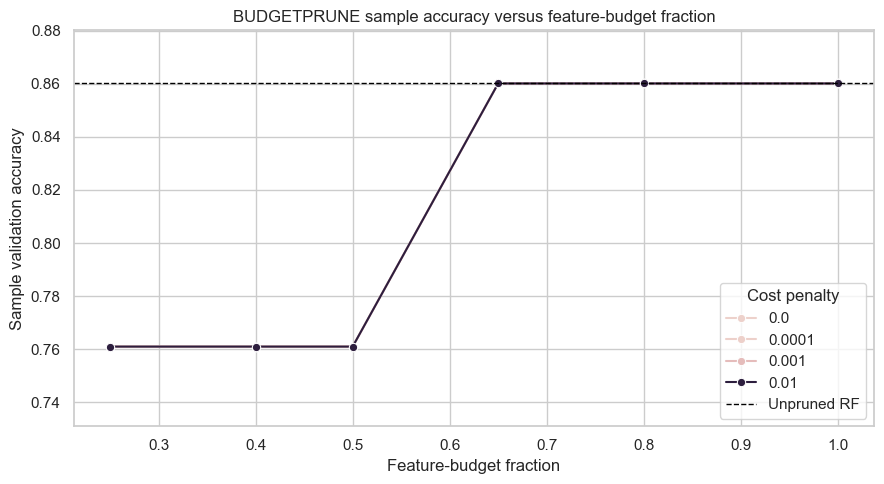

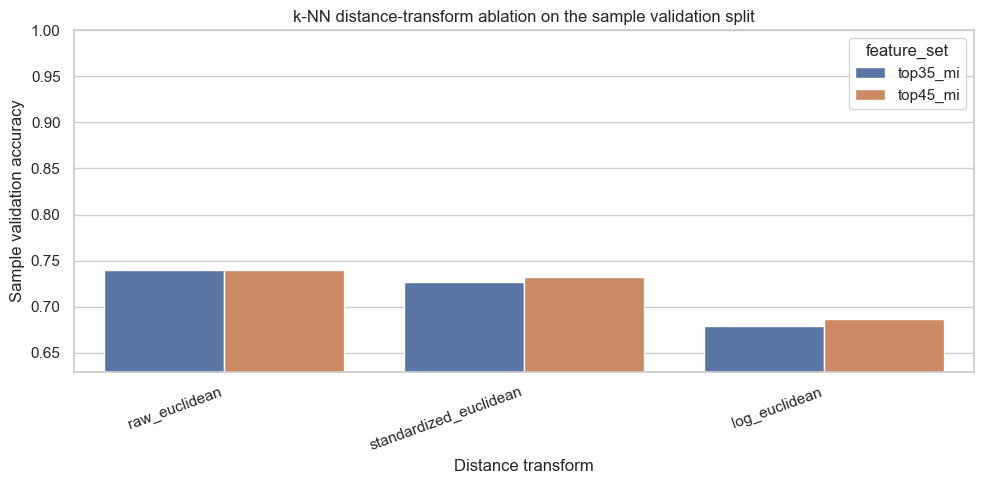

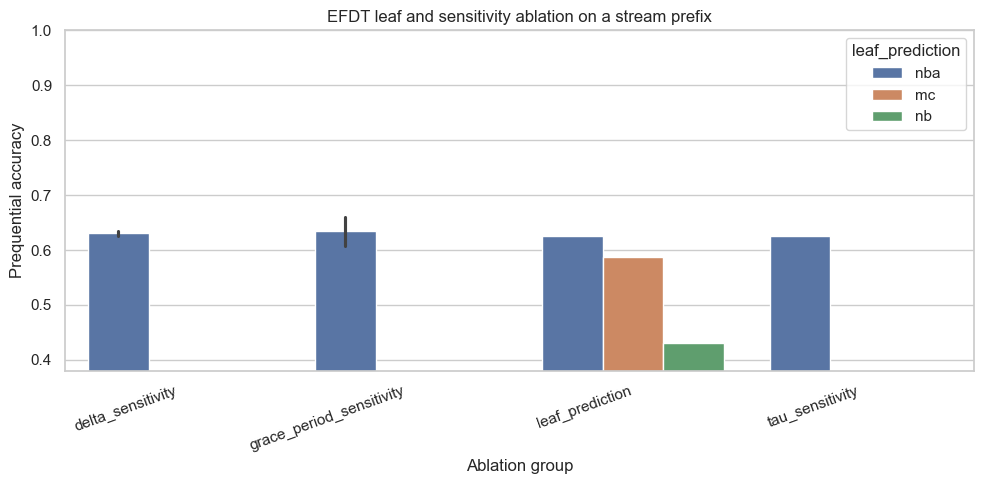

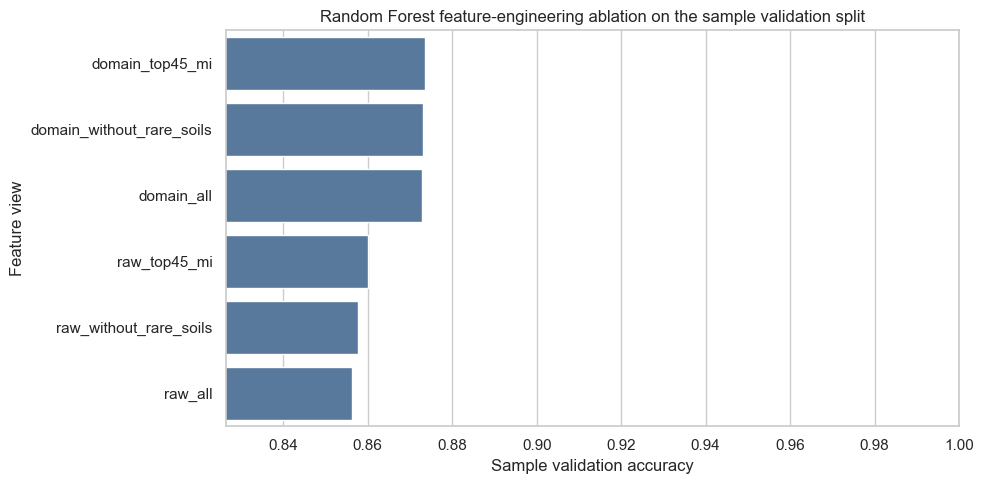

Best literature-motivated sample ablation from each group


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,max_depth,budget_fraction,cost_penalty,min_trees,budget,base_rf_accuracy,accuracy_delta_from_base_rf,selected_trees,feature_acquisition_cost,solver,base_rf_cache_path,base_rf_cache_loaded,cache_path,cache_loaded,ablation,experiment,reused_existing_result,literature_pass,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows,tuning_pass,tau,reuse_source,learning_rate,reg_lambda,depth,iterations,l2_leaf_reg,l2_regularization,max_iter,max_leaf_nodes,lr,weight_decay,batch_size,width,scheduler,best_valid_loss,d_token,n_heads,n_trees,lambda_sparse,n_d,n_a,distance_transform,k_values,base_model,criterion,data_view,selected_features
0,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.857172,NaN,0.273,0.4,1.0,80.0,NaN,0.65,0.0,5.0,29.0,0.86016,0.0,80.0,45.0,lp_relaxation_fallback,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,budget_curve,budgetprune_accuracy_cost,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,knn_distance_loocv,top35_mi,0.73936,0.578459,0.603856,0.738388,NaN,0.437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,distance_metric,knn_distance_transform,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,5000.0,NaN,1.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,raw_euclidean,"[1, 3, 5]",NaN,NaN,NaN,NaN
2,efdt_nb_leaves,all,0.66050,0.603202,NaN,NaN,NaN,1.682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,stream_leaf_and_sensitivity,grace_period_sensitivity,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,50.0,nba,10000.0,NaN,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,random_forest_feature_ablation,domain_top45_mi,0.87360,0.794309,0.796572,0.871572,NaN,0.226,0.4,1.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,tree_feature_engineering,random_forest_raw_vs_domain_features,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,entropy,domain_top45_mi,45.0


Missing configurations skipped because new training was disabled


,note
0,No missing ablation configurations.


In [104]:
literature_ablation_results = pd.DataFrame(LITERATURE_ABLATION_ROWS)
if not literature_ablation_results.empty:
    literature_ablation_results = literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False]).reset_index(drop=True)
    literature_ablation_results.to_csv(LITERATURE_ABLATION_FILES["combined"], index=False)

    literature_ablation_best = (
        literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False])
        .groupby("ablation", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    literature_ablation_best.to_csv(LITERATURE_ABLATION_FILES["best"], index=False)
else:
    literature_ablation_best = pd.DataFrame()

missing_ablation_df = pd.DataFrame(LITERATURE_ABLATION_MISSING_CONFIGS)
missing_ablation_df.to_csv(LITERATURE_ABLATION_FILES["missing"], index=False)

if not literature_budget_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.lineplot(data=literature_budget_df, x="budget_fraction", y="accuracy", hue="cost_penalty", marker="o", ax=ax)
    ax.axhline(base_budget_accuracy, color="black", linestyle="--", linewidth=1, label="Unpruned RF")
    ax.set_title("BUDGETPRUNE sample accuracy versus feature-budget fraction")
    ax.set_xlabel("Feature-budget fraction")
    ax.set_ylabel("Sample validation accuracy")
    ax.set_ylim(max(0, literature_budget_df["accuracy"].min() - 0.03), min(1, max(base_budget_accuracy, literature_budget_df["accuracy"].max()) + 0.02))
    ax.legend(title="Cost penalty", loc="lower right")
    plt.tight_layout()
    plt.show()

if not literature_distance_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=literature_distance_df, x="distance_transform", y="accuracy", hue="feature_set", ax=ax)
    ax.set_title("k-NN distance-transform ablation on the sample validation split")
    ax.set_xlabel("Distance transform")
    ax.set_ylabel("Sample validation accuracy")
    ax.set_ylim(max(0, literature_distance_df["accuracy"].min() - 0.05), 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

if not literature_stream_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=literature_stream_df, x="experiment", y="accuracy", hue="leaf_prediction", ax=ax)
    ax.set_title("EFDT leaf and sensitivity ablation on a stream prefix")
    ax.set_xlabel("Ablation group")
    ax.set_ylabel("Prequential accuracy")
    ax.set_ylim(max(0, literature_stream_df["accuracy"].min() - 0.05), 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

if not literature_tree_feature_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=literature_tree_feature_df, y="data_view", x="accuracy", color="#4c78a8", ax=ax)
    ax.set_title("Random Forest feature-engineering ablation on the sample validation split")
    ax.set_xlabel("Sample validation accuracy")
    ax.set_ylabel("Feature view")
    ax.set_xlim(max(0, literature_tree_feature_df["accuracy"].min() - 0.03), 1)
    plt.tight_layout()
    plt.show()

print("Best literature-motivated sample ablation from each group")
display(literature_ablation_best)
print("Missing configurations skipped because new training was disabled")
display(missing_ablation_df if not missing_ablation_df.empty else pd.DataFrame({"note": ["No missing ablation configurations."]}))


**Interpretation.** These ablations should be read as sample-level evidence, not as final full-test scores. The budget curve is useful for deciding whether a cheaper forest is acceptable. The EFDT leaf comparison checks the literature claim that Naive Bayes leaves improve stream learning. The distance ablation tests whether Log-Euclidean preprocessing is better than simpler Euclidean choices. The tree feature ablation checks whether domain features are worth carrying into full training.

## Full Training Helper

In [105]:
def cfg_value(cfg, key, default=None):
    value = cfg.get(key, default)
    if value is None:
        return default
    if isinstance(value, float) and np.isnan(value):
        return default
    if isinstance(value, str) and value.strip() in {"", "nan", "NaN"}:
        return default
    return value


def cfg_int(cfg, key, default):
    return int(float(cfg_value(cfg, key, default)))


def cfg_float(cfg, key, default):
    return float(cfg_value(cfg, key, default))


def cfg_optional_int(cfg, key):
    value = cfg_value(cfg, key, None)
    if value is None or str(value) == "None":
        return None
    return int(float(value))


def cfg_max_features(cfg, default="sqrt"):
    value = cfg_value(cfg, "max_features", default)
    if isinstance(value, str) and value == "None":
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return value


def full_model_metadata_path(model_path):
    model_path = Path(model_path)
    return model_path.with_name(f"{model_path.name}.meta.json")


def make_full_model_payload(model_name, feature_set, params, feature_columns=None):
    return {
        "model_name": model_name,
        "feature_set": feature_set,
        "params": json_safe(params),
        "random_state": RANDOM_STATE,
        "full_train_rows": int(len(X_train_full)) if "X_train_full" in globals() else None,
        "full_test_rows": int(len(X_test_full)) if "X_test_full" in globals() else None,
        "feature_columns": list(feature_columns) if feature_columns is not None else None,
    }


def full_model_metadata_matches(model_path, expected_payload):
    meta_path = full_model_metadata_path(model_path)
    if not meta_path.exists():
        return None
    try:
        saved_payload = json.loads(meta_path.read_text(encoding="utf-8"))
    except Exception:
        return False
    return saved_payload == json_safe(expected_payload)


def load_model_by_path(model_path, use_pickle=False):
    model_path = Path(model_path)
    if use_pickle:
        import pickle
        with model_path.open("rb") as fh:
            return pickle.load(fh)
    return joblib.load(model_path)


def fit_or_load_full_model(
    model_name,
    feature_set,
    params,
    feature_columns,
    model_path,
    fit_fn,
    use_pickle=False,
    load_fn=None,
    save_fn=None,
    allow_legacy_without_metadata=True,
):
    model_path = Path(model_path)
    payload = make_full_model_payload(model_name, feature_set, params, feature_columns)
    if model_path.exists():
        match = full_model_metadata_matches(model_path, payload)
        if match or (match is None and allow_legacy_without_metadata):
            try:
                model = load_fn(model_path) if load_fn is not None else load_model_by_path(model_path, use_pickle=use_pickle)
                if match is None:
                    save_json(payload, full_model_metadata_path(model_path))
                    print(f"Loaded legacy full-model cache for {model_name}; wrote metadata for future exact config checks.")
                else:
                    print(f"Loaded full-model cache for {model_name}: {model_path.name}")
                return model, model_path, True
            except Exception as exc:
                quarantine_bad_cache(model_path, exc)
        elif match is False:
            print(f"Full-model cache exists for {model_name}, but metadata does not match the selected configuration. Retraining.")

    model = fit_fn()
    if save_fn is not None:
        save_fn(model, model_path)
    else:
        save_model(model, model_path, use_pickle=use_pickle)
    save_json(payload, full_model_metadata_path(model_path))
    return model, model_path, False


def record_full_result(model_name, feature_set, metrics, model_path, seconds, extra=None):
    row = {
        "model": model_name,
        "feature_set": feature_set,
        "accuracy": metrics["accuracy"],
        "kappa": metrics["kappa"],
        "macro_f1": metrics.get("macro_f1"),
        "weighted_f1": metrics.get("weighted_f1"),
        "log_loss": metrics.get("log_loss"),
        "seconds": round(seconds, 3),
        "model_path": str(model_path),
    }
    if extra:
        row.update(extra)
    full_results[:] = [existing for existing in full_results if existing.get("model") != model_name]
    full_results.append(row)
    if "classification_report" in metrics:
        full_reports[model_name] = metrics["classification_report"]
    return row


def display_current_full_results():
    return pd.DataFrame(full_results).sort_values(["accuracy", "kappa"], ascending=False)


# Full Dataset Training and Testing

## Full Random Forest Baseline

In [106]:
cfg = get_best_config(best_by_model_for_full_training, "random_forest_entropy_40")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

rf_n_estimators = cfg_int(cfg, "n_estimators", 40)
rf_max_features = cfg_max_features(cfg, default="sqrt")
rf_min_samples_leaf = cfg_int(cfg, "min_samples_leaf", 1)
rf_max_depth = cfg_optional_int(cfg, "max_depth")
rf_params = {
    "n_estimators": rf_n_estimators,
    "criterion": "entropy",
    "max_features": rf_max_features,
    "min_samples_leaf": rf_min_samples_leaf,
    "max_depth": rf_max_depth,
}


def fit_rf_full():
    model = RandomForestClassifier(
        **rf_params,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X_train_full[cols], y_train_full)
    return model


rf_full, rf_path, rf_cache_loaded = fit_or_load_full_model(
    "random_forest_entropy_40",
    cfg["feature_set"],
    rf_params,
    cols,
    MODEL_DIR / "random_forest_entropy_40_best.joblib",
    fit_rf_full,
)
rf_metrics = evaluate_predictions(y_test_full, rf_full.predict(X_test_full[cols]))

record_full_result(
    "random_forest_entropy_40",
    cfg["feature_set"],
    rf_metrics,
    rf_path,
    time.perf_counter() - started,
    {
        "selected_features": len(cols),
        "cache_loaded": rf_cache_loaded,
        **rf_params,
    },
)
display_current_full_results()


Loaded full-model cache for random_forest_entropy_40: random_forest_entropy_40_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80,entropy,0.4,1,None


## Full BUDGETPRUNE Random Forest

In [107]:
cfg = get_best_config(best_by_model_for_full_training, "budgetpruned_random_forest")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

bp_n_estimators = cfg_int(cfg, "n_estimators", 40)
bp_max_features = cfg_max_features(cfg, default="sqrt")
bp_min_samples_leaf = cfg_int(cfg, "min_samples_leaf", 1)
bp_max_depth = cfg_optional_int(cfg, "max_depth")
bp_min_trees = cfg_int(cfg, "min_trees", 5)
budget = max(1, int(round(len(cols) * cfg_float(cfg, "budget_fraction", 1.0))))
bp_params = {
    "n_estimators": bp_n_estimators,
    "criterion": "entropy",
    "max_features": bp_max_features,
    "min_samples_leaf": bp_min_samples_leaf,
    "max_depth": bp_max_depth,
    "min_trees": bp_min_trees,
    "budget": budget,
    "budget_fraction": cfg_float(cfg, "budget_fraction", 1.0),
    "cost_penalty": cfg_float(cfg, "cost_penalty", 0.005),
}


def fit_budgetprune_full():
    X_rf_fit, X_prune_val, y_rf_fit, y_prune_val = train_test_split(
        X_train_full[cols],
        y_train_full,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
    forest_for_pruning = RandomForestClassifier(
        n_estimators=bp_n_estimators,
        criterion="entropy",
        max_features=bp_max_features,
        min_samples_leaf=bp_min_samples_leaf,
        max_depth=bp_max_depth,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    forest_for_pruning.fit(X_rf_fit, y_rf_fit)
    model = BudgetPrunedForestClassifier(
        forest=forest_for_pruning,
        budget=budget,
        cost_penalty=bp_params["cost_penalty"],
        min_trees=bp_min_trees,
        solver="milp",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X_rf_fit, y_rf_fit, X_val=X_prune_val, y_val=y_prune_val)
    return model


budgetprune_full, bp_path, bp_cache_loaded = fit_or_load_full_model(
    "budgetpruned_random_forest",
    cfg["feature_set"],
    bp_params,
    cols,
    MODEL_DIR / "budgetpruned_random_forest_best.joblib",
    fit_budgetprune_full,
)
bp_metrics = evaluate_predictions(y_test_full, budgetprune_full.predict(X_test_full[cols]))

record_full_result(
    "budgetpruned_random_forest",
    cfg["feature_set"],
    bp_metrics,
    bp_path,
    time.perf_counter() - started,
    {
        "selected_features": int(len(budgetprune_full.selected_features_)),
        "selected_trees": int(len(budgetprune_full.selected_tree_indices_)),
        "feature_acquisition_cost": budgetprune_full.feature_acquisition_cost_,
        "cache_loaded": bp_cache_loaded,
        **bp_params,
    },
)
display_current_full_results()


Loaded full-model cache for budgetpruned_random_forest: budgetpruned_random_forest_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80,entropy,0.4,1,None,NaN,NaN,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,None,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80,entropy,0.4,1,None,80.0,45.0,5.0,29.0,0.65,0.001


## Full Scale-Invariant Online Linear Model

In [108]:
cfg = get_best_config(best_by_model_for_full_training, "scale_invariant_online_linear")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

online_epochs = cfg_int(cfg, "epochs", 1)
online_params = {"epochs": online_epochs, "shuffle": True}


def fit_online_full():
    model = ScaleInvariantOnlineLinearClassifier(
        epochs=online_epochs,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_full[cols], y_train_full)
    return model


online_full, online_path, online_cache_loaded = fit_or_load_full_model(
    "scale_invariant_online_linear",
    cfg["feature_set"],
    online_params,
    cols,
    MODEL_DIR / "scale_invariant_online_linear_best.joblib",
    fit_online_full,
)
online_metrics = evaluate_predictions(y_test_full, online_full.predict(X_test_full[cols]))

record_full_result(
    "scale_invariant_online_linear",
    cfg["feature_set"],
    online_metrics,
    online_path,
    time.perf_counter() - started,
    {"selected_features": len(cols), "cache_loaded": online_cache_loaded, **online_params},
)
display_current_full_results()


Loaded full-model cache for scale_invariant_online_linear: scale_invariant_online_linear_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,None,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN
2,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,None,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True


## Full L1 SVM with Active-Set Newton

In [109]:
cfg = get_best_config(best_by_model_for_full_training, "l1_svm_newton_active_set")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

l1_C = cfg_float(cfg, "C", 0.5)
l1_alpha = cfg_float(cfg, "alpha", 0.001)
l1_params = {"C": l1_C, "alpha": l1_alpha, "max_iter": 40}


def fit_l1_full():
    model = L1LinearSVMNewton(
        C=l1_C,
        alpha=l1_alpha,
        max_iter=40,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_full[cols], y_train_full)
    return model


l1_full, l1_path, l1_cache_loaded = fit_or_load_full_model(
    "l1_svm_newton_active_set",
    cfg["feature_set"],
    l1_params,
    cols,
    MODEL_DIR / "l1_svm_newton_active_set_best.joblib",
    fit_l1_full,
)
l1_metrics = evaluate_predictions(y_test_full, l1_full.predict(X_test_full[cols]))

record_full_result(
    "l1_svm_newton_active_set",
    cfg["feature_set"],
    l1_metrics,
    l1_path,
    time.perf_counter() - started,
    {
        "selected_features": len(cols),
        "newton_iterations": int(getattr(l1_full, "n_iter_", np.nan)),
        "cache_loaded": l1_cache_loaded,
        **l1_params,
    },
)
display_current_full_results()


Loaded full-model cache for l1_svm_newton_active_set: l1_svm_newton_active_set_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle,newton_iterations,C,alpha,max_iter
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,None,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN,NaN,NaN,NaN,NaN
3,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,None,0.126,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,35,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.25,0.0001,40.0
2,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,None,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN


## Full OPF Baseline

The original LibOPF algorithm is parameter-free. If a native OPF backend is not installed, this project uses a complete-graph OPF fallback. The fallback is exact on the retained training subset but quadratic in memory, so the full notebook bounds it with `OPF_FALLBACK_FULL_MAX_TRAIN`.

In [110]:
cfg = get_best_config(best_by_model_for_full_training, "opf_log_euclidean")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

opf_max_train_samples = cfg_int(cfg, "max_train_samples", OPF_FALLBACK_FULL_MAX_TRAIN)
opf_params = {"backend": "auto", "max_train_samples": opf_max_train_samples}


def fit_opf_full():
    model = LibOPFClassifier(
        backend="auto",
        max_train_samples=opf_max_train_samples,
        random_state=RANDOM_STATE,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(X_train_full[cols], y_train_full)
    return model


opf_full, opf_path, opf_cache_loaded = fit_or_load_full_model(
    "opf_log_euclidean",
    cfg["feature_set"],
    opf_params,
    cols,
    MODEL_DIR / "opf_log_euclidean_best.joblib",
    fit_opf_full,
)
opf_metrics = evaluate_predictions(y_test_full, opf_full.predict(X_test_full[cols]))

record_full_result(
    "opf_log_euclidean",
    cfg["feature_set"],
    opf_metrics,
    opf_path,
    time.perf_counter() - started,
    {"backend": opf_full.backend_, "cache_loaded": opf_cache_loaded, "selected_features": len(cols), **opf_params},
)
display_current_full_results()


Loaded full-model cache for opf_log_euclidean: opf_log_euclidean_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle,newton_iterations,C,alpha,max_iter,backend,max_train_samples
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,None,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,None,0.126,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,35,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.25,0.0001,40.0,NaN,NaN
2,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,None,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,0.669224,None,7.522,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,5000.0


## Full k-NN with Sample-Selected Feature Set and Exact k

The sample stage selected the feature set and exact leave-one-out value of `k` from `{1, 3, 5}`. This cell refits k-NN on the full training split using that selected feature set. Full prediction can be computationally expensive because every test row searches the retained training set.

In [111]:
cfg = get_best_config(best_by_model_for_full_training, "knn_log_euclidean_loocv")
cols = feature_sets[cfg["feature_set"]]
started = time.perf_counter()

knn_best_k = cfg_int(cfg, "best_k", 1)
knn_weights = cfg_value(cfg, "weights", "uniform")
knn_params = {"best_k": knn_best_k, "weights": knn_weights, "tune_k": False}


def fit_knn_full():
    model = LogEuclideanKNNClassifier(k_values=(knn_best_k,), weights=knn_weights, n_jobs=1, tune_k=False)
    model.fit(X_train_full[cols], y_train_full)
    return model


knn_full, knn_path, knn_cache_loaded = fit_or_load_full_model(
    "knn_log_euclidean_loocv",
    cfg["feature_set"],
    knn_params,
    cols,
    MODEL_DIR / "knn_log_euclidean_loocv_best.joblib",
    fit_knn_full,
)
knn_metrics = evaluate_predictions(y_test_full, knn_full.predict(X_test_full[cols]))

record_full_result(
    "knn_log_euclidean_loocv",
    cfg["feature_set"],
    knn_metrics,
    knn_path,
    time.perf_counter() - started,
    {"cache_loaded": knn_cache_loaded, "selected_features": len(cols), **knn_params},
)
display_current_full_results()


Loaded full-model cache for knn_log_euclidean_loocv: knn_log_euclidean_loocv_best.joblib


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle,newton_iterations,C,alpha,max_iter,backend,max_train_samples,best_k,weights,tune_k
0,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,None,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,None,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179,0.911130,None,38.508,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,False
3,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,None,0.126,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,35,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.25,0.0001,40.0,NaN,NaN,NaN,NaN,NaN
2,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,None,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,0.669224,None,7.522,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,5000.0,NaN,NaN,NaN


## Full Sequential Stream Evaluation with EFDT and Naive Bayes Leaves

In [112]:
cfg = get_best_config(best_by_model_for_full_training, "efdt_nb_leaves")
started = time.perf_counter()

stream_grace_period = cfg_int(cfg, "grace_period", 100)
stream_delta = cfg_float(cfg, "delta", 1e-7)
stream_tau = cfg_float(cfg, "tau", 0.05)
stream_leaf_prediction = cfg_value(cfg, "leaf_prediction", "nb")
stream_params = {
    "tree_type": "efdt",
    "grace_period": stream_grace_period,
    "delta": stream_delta,
    "tau": stream_tau,
    "leaf_prediction": stream_leaf_prediction,
    "report_every": FULL_STREAM_REPORT_EVERY,
}


def fit_stream_full():
    model = StreamTreeNBLeaves(**stream_params)
    model.fit_prequential(X, y)
    return model


stream_full, stream_path, stream_cache_loaded = fit_or_load_full_model(
    "efdt_nb_leaves",
    "all",
    stream_params,
    list(X.columns),
    MODEL_DIR / "efdt_nb_leaves_full_stream.pkl",
    fit_stream_full,
    use_pickle=True,
)

stream_metrics = {"accuracy": stream_full.final_metrics_["accuracy"], "kappa": stream_full.final_metrics_["kappa"]}
record_full_result(
    "efdt_nb_leaves",
    "all",
    stream_metrics,
    stream_path,
    time.perf_counter() - started,
    {
        "evaluation": "prequential_full_stream",
        "n": stream_full.final_metrics_["n"],
        "cache_loaded": stream_cache_loaded,
        **stream_params,
    },
)
pd.DataFrame(stream_full.timeline_).tail()


Loaded full-model cache for efdt_nb_leaves: efdt_nb_leaves_full_stream.pkl


,n,accuracy,kappa
8,400000,0.764728,0.597517
9,450000,0.766560,0.608441
10,500000,0.758210,0.596642
11,550000,0.758576,0.600763
12,581012,0.752069,0.591300


## Full Prompt-Inspired Boosted Tree Model

This cell trains the best prompt-inspired boosted tree candidate on the current full train split and evaluates it on the current full test split. It keeps the notebook's existing split rather than switching to the 80/10/10 split from the prompt.

In [113]:
if "prompt_tree_best" not in globals() or prompt_tree_best.empty:
    display(pd.DataFrame({"status": ["No prompt tree model was available to train. Run the prompt tree tuning cell first."]}))
else:
    cfg = prompt_tree_best.iloc[0].to_dict()
    cols = feature_sets_domain[cfg["feature_set"]]
    backend = cfg_value(cfg, "backend", "sklearn_hist_gradient_boosting")
    started = time.perf_counter()
    model_name = cfg["model"]

    if backend == "xgboost" and optional_backend_available["xgboost"]:
        from xgboost import XGBClassifier
        prompt_tree_params = {
            "backend": backend,
            "objective": "multi:softprob",
            "num_class": len(classes_sorted),
            "tree_method": "hist",
            "eval_metric": "mlogloss",
            "learning_rate": cfg_float(cfg, "learning_rate", 0.1),
            "max_depth": cfg_int(cfg, "max_depth", 10),
            "reg_lambda": cfg_float(cfg, "reg_lambda", 5.0),
            "n_estimators": cfg_int(cfg, "n_estimators", 400),
        }

        def fit_prompt_tree_full():
            model = XGBClassifier(
                **{k: v for k, v in prompt_tree_params.items() if k != "backend"},
                n_jobs=1,
                random_state=RANDOM_STATE,
            )
            model.fit(X_train_full_domain[cols], y_train_full.to_numpy() - 1, verbose=False)
            return model

        model_path = MODEL_DIR / "xgboost_gbdt_prompt_best.joblib"
        model, model_path, prompt_tree_cache_loaded = fit_or_load_full_model(
            model_name,
            cfg["feature_set"],
            prompt_tree_params,
            cols,
            model_path,
            fit_prompt_tree_full,
        )
        pred = model.predict(X_test_full_domain[cols]) + 1
        proba = model.predict_proba(X_test_full_domain[cols])
    elif backend == "catboost" and optional_backend_available["catboost"]:
        from catboost import CatBoostClassifier
        prompt_tree_params = {
            "backend": backend,
            "loss_function": "MultiClass",
            "eval_metric": "MultiClass",
            "learning_rate": cfg_float(cfg, "learning_rate", 0.1),
            "depth": cfg_int(cfg, "depth", 10),
            "l2_leaf_reg": cfg_float(cfg, "l2_leaf_reg", 10.0),
            "iterations": cfg_int(cfg, "iterations", 500),
        }

        def fit_prompt_tree_full():
            model = CatBoostClassifier(
                **{k: v for k, v in prompt_tree_params.items() if k != "backend"},
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
            )
            model.fit(X_train_full_domain[cols], y_train_full)
            return model

        model_path = MODEL_DIR / "catboost_gbdt_prompt_best.joblib"
        model, model_path, prompt_tree_cache_loaded = fit_or_load_full_model(
            model_name,
            cfg["feature_set"],
            prompt_tree_params,
            cols,
            model_path,
            fit_prompt_tree_full,
        )
        pred = model.predict(X_test_full_domain[cols]).reshape(-1).astype(int)
        proba = model.predict_proba(X_test_full_domain[cols])
    else:
        from sklearn.ensemble import HistGradientBoostingClassifier
        prompt_tree_params = {
            "backend": "sklearn_hist_gradient_boosting",
            "learning_rate": cfg_float(cfg, "learning_rate", 0.1),
            "max_leaf_nodes": cfg_int(cfg, "max_leaf_nodes", 63),
            "l2_regularization": cfg_float(cfg, "l2_regularization", 1.0),
            "max_iter": cfg_int(cfg, "max_iter", 250),
            "early_stopping": True,
        }

        def fit_prompt_tree_full():
            model = HistGradientBoostingClassifier(
                **{k: v for k, v in prompt_tree_params.items() if k != "backend"},
                random_state=RANDOM_STATE,
            )
            model.fit(X_train_full_domain[cols], y_train_full)
            return model

        model_path = MODEL_DIR / "sklearn_hist_gbdt_prompt_best.joblib"
        model, model_path, prompt_tree_cache_loaded = fit_or_load_full_model(
            model_name,
            cfg["feature_set"],
            prompt_tree_params,
            cols,
            model_path,
            fit_prompt_tree_full,
        )
        pred = model.predict(X_test_full_domain[cols])
        proba = model.predict_proba(X_test_full_domain[cols])

    metrics = evaluate_predictions(y_test_full, pred, y_proba=proba, labels=classes_sorted)
    record_full_result(
        model_name,
        cfg["feature_set"],
        metrics,
        model_path,
        time.perf_counter() - started,
        {"backend": backend, "cache_loaded": prompt_tree_cache_loaded, "selected_features": len(cols), "source": "prompt_tree"},
    )
    display_current_full_results()


Loaded full-model cache for xgboost_gbdt: xgboost_gbdt_prompt_best.joblib


## Full Prompt-Inspired Deep Tabular Model

This cell trains the best available deep-tabular candidate from the prompt-inspired tuning section. It uses a validation split inside the current training split for early stopping, then evaluates on the same full test split used by the other batch models.

In [114]:
if "prompt_deep_best" not in globals() or prompt_deep_best.empty or not optional_backend_available.get("torch", False):
    display(pd.DataFrame({"status": ["No prompt deep model was available to train. Install torch / pytorch-tabnet and run prompt deep tuning first."]}))
else:
    import torch
    import torch.nn.functional as F

    cfg = prompt_deep_best.iloc[0].to_dict()
    started = time.perf_counter()

    X_deep_fit_pd, X_deep_val_pd, y_deep_fit, y_deep_val = train_test_split(
        X_train_full_domain,
        y_train_full,
        test_size=0.10,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
    X_deep_fit, X_deep_val, full_deep_quantile_transformer, full_deep_feature_names = make_deep_design_matrices(
        X_deep_fit_pd,
        X_deep_val_pd,
        continuous_cols_domain,
        binary_cols_domain,
    )
    X_deep_test_cont = full_deep_quantile_transformer.transform(X_test_full_domain[continuous_cols_domain])
    X_deep_test_bin = X_test_full_domain[binary_cols_domain].to_numpy(dtype=np.float32)
    X_deep_test = np.hstack([X_deep_test_cont, X_deep_test_bin]).astype(np.float32)
    y_deep_fit_encoded = label_encoder.transform(y_deep_fit)
    y_deep_val_encoded = label_encoder.transform(y_deep_val)

    model_name = cfg["model"]
    deep_params = {
        "model_name": model_name,
        "input_features": X_deep_fit.shape[1],
        "n_classes": len(label_encoder.classes_),
        "lr": cfg_float(cfg, "lr", 1e-3),
        "weight_decay": cfg_float(cfg, "weight_decay", 1e-4),
        "batch_size": cfg_int(cfg, "batch_size", 4096),
        "scheduler": cfg_value(cfg, "scheduler", None),
        "continuous_transform": "QuantileTransformer(output_distribution='normal')",
    }

    if model_name == "tabnet" and optional_backend_available.get("pytorch_tabnet", False):
        from pytorch_tabnet.tab_model import TabNetClassifier
        scheduler_name = cfg_value(cfg, "scheduler", "step")
        scheduler_fn = torch.optim.lr_scheduler.StepLR if scheduler_name == "step" else torch.optim.lr_scheduler.ExponentialLR
        scheduler_params = {"step_size": 5, "gamma": 0.5} if scheduler_name == "step" else {"gamma": 0.9}
        deep_params.update({
            "n_d": 64,
            "n_a": 64,
            "lambda_sparse": cfg_float(cfg, "lambda_sparse", 1e-4),
            "scheduler": scheduler_name,
            "max_epochs": 60,
            "patience": 6,
            "virtual_batch_size": 1024,
        })

        def build_tabnet_model():
            return TabNetClassifier(
                n_d=64,
                n_a=64,
                lambda_sparse=deep_params["lambda_sparse"],
                optimizer_fn=torch.optim.AdamW,
                optimizer_params={"lr": 1e-3},
                scheduler_fn=scheduler_fn,
                scheduler_params=scheduler_params,
                seed=RANDOM_STATE,
                verbose=0,
            )

        def fit_deep_full():
            model = build_tabnet_model()
            model.fit(
                X_deep_fit,
                y_deep_fit_encoded,
                eval_set=[(X_deep_val, y_deep_val_encoded)],
                eval_metric=["logloss"],
                max_epochs=60,
                patience=6,
                batch_size=deep_params["batch_size"],
                virtual_batch_size=1024,
            )
            return model

        def load_tabnet_full(model_path):
            model = build_tabnet_model()
            model.load_model(str(model_path))
            return model

        def save_tabnet_full(model, model_path):
            model.save_model(str(model_path).replace(".zip", ""))

        model_path = MODEL_DIR / "tabnet_prompt_best.zip"
        model, model_path, deep_cache_loaded = fit_or_load_full_model(
            model_name,
            "domain_quantile_all",
            deep_params,
            full_deep_feature_names,
            model_path,
            fit_deep_full,
            load_fn=load_tabnet_full,
            save_fn=save_tabnet_full,
        )
        proba = model.predict_proba(X_deep_test)
        pred = label_encoder.inverse_transform(proba.argmax(axis=1))
    else:
        def build_torch_model():
            if model_name == "tabular_resnet":
                deep_params.update({"width": cfg_int(cfg, "width", 256), "depth": cfg_int(cfg, "depth", 3)})
                return TabularResNet(X_deep_fit.shape[1], len(label_encoder.classes_), width=deep_params["width"], depth=deep_params["depth"])
            if model_name == "ft_transformer":
                deep_params.update({"d_token": cfg_int(cfg, "d_token", 64), "n_heads": cfg_int(cfg, "n_heads", 4)})
                return FTTransformerMini(X_deep_fit.shape[1], len(label_encoder.classes_), d_token=deep_params["d_token"], n_heads=deep_params["n_heads"])
            deep_params.update({"depth": cfg_int(cfg, "depth", 8), "n_trees": cfg_int(cfg, "n_trees", 32)})
            return NODELite(X_deep_fit.shape[1], len(label_encoder.classes_), depth=deep_params["depth"], n_trees=deep_params["n_trees"])

        # Build once before metadata is made so architecture-specific params are included.
        _ = build_torch_model()

        def fit_deep_full():
            model = build_torch_model()
            model, _, _, _ = train_torch_classifier(
                model,
                X_deep_fit,
                y_deep_fit_encoded,
                X_deep_val,
                y_deep_val_encoded,
                lr=deep_params["lr"],
                weight_decay=deep_params["weight_decay"],
                batch_size=deep_params["batch_size"],
                max_epochs=30,
                patience=5,
                scheduler_name=deep_params["scheduler"],
            )
            return model.cpu()

        def load_torch_full(model_path):
            checkpoint = torch.load(model_path, map_location="cpu")
            model = build_torch_model()
            model.load_state_dict(checkpoint["state_dict"])
            return model

        def save_torch_full(model, model_path):
            torch.save(
                {
                    "model_name": model_name,
                    "state_dict": model.cpu().state_dict(),
                    "config": json_safe(cfg),
                    "feature_names": full_deep_feature_names,
                },
                model_path,
            )

        model_path = MODEL_DIR / f"{model_name}_prompt_best.pt"
        model, model_path, deep_cache_loaded = fit_or_load_full_model(
            model_name,
            "domain_quantile_all",
            deep_params,
            full_deep_feature_names,
            model_path,
            fit_deep_full,
            load_fn=load_torch_full,
            save_fn=save_torch_full,
        )
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
        model.eval()
        with torch.no_grad():
            logits = model(torch.from_numpy(X_deep_test).to(device))
            proba = torch.softmax(logits, dim=1).cpu().numpy()
        pred = label_encoder.inverse_transform(proba.argmax(axis=1))

    metrics = evaluate_predictions(y_test_full, pred, y_proba=proba, labels=classes_sorted)
    record_full_result(
        model_name,
        "domain_quantile_all",
        metrics,
        model_path,
        time.perf_counter() - started,
        {"source": "prompt_deep", "cache_loaded": deep_cache_loaded, "selected_features": X_deep_test.shape[1]},
    )
    display_current_full_results()


Loaded full-model cache for tabular_resnet: tabular_resnet_prompt_best.pt


## Three-Fold Cross-Validation Addendum

This section adds the reviewer-requested 3-fold stratified cross-validation without changing the holdout workflow above. It runs the same model families used in the notebook plus logistic regression and shrinkage LDA baselines. Models are cached under `models/notebook_cv_cache/`, reports are written under `reports/notebook_cv/`, and every split/model that exposes a seed receives `RANDOM_STATE` or a deterministic fold seed derived from it.

The OPF, k-NN, and deep-tabular models keep explicit row caps so the section is feasible on CPU. Those caps are recorded in the output CSV files.


In [115]:

import itertools

from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, QuantileTransformer, StandardScaler, label_binarize

np.random.seed(RANDOM_STATE)

CV_FOLDS = 3
CV_MODEL_DIR = ROOT / "models" / "notebook_cv_cache"
CV_REPORT_DIR = ROOT / "reports" / "notebook_cv"
CV_MODEL_DIR.mkdir(parents=True, exist_ok=True)
CV_REPORT_DIR.mkdir(parents=True, exist_ok=True)

# These caps keep the reviewer CV feasible on CPU while still evaluating every model family.
# The caps are saved in the CSV rows so the table is explicit about what was bounded.
CV_FEATURE_SELECTION_SAMPLE = 50_000
CV_INSTANCE_TRAIN_ROWS = 5_000      # OPF and k-NN fallback/LOO are expensive beyond this.
CV_DEEP_TRAIN_ROWS = 50_000         # Deep tabular models train on a stratified training-fold subset.
CV_DEEP_BATCH_SIZE = 4096
CV_TABNET_BATCH_SIZE = 8192
CV_TORCH_EPOCHS = 20
CV_TORCH_PATIENCE = 4
CV_TABNET_EPOCHS = 40
CV_TABNET_PATIENCE = 5
CV_STREAM_TRAIN_ROWS = None         # Set to an integer for a faster stream-tree CV smoke run.

CV_MODELS_TO_RUN = [
    "logistic_regression_l2",
    "linear_discriminant_shrinkage",
    "random_forest_entropy_40",
    "budgetpruned_random_forest",
    "scale_invariant_online_linear",
    "l1_svm_newton_active_set",
    "opf_log_euclidean",
    "knn_log_euclidean_loocv",
    "efdt_nb_leaves",
    "xgboost_gbdt",
    "catboost_gbdt",
    "sklearn_hist_gbdt_fallback",
    "tabular_resnet",
    "ft_transformer",
    "node_lite",
    "tabnet",
]

pd.DataFrame({
    "setting": [
        "CV_FOLDS",
        "RANDOM_STATE",
        "CV_MODEL_DIR",
        "CV_REPORT_DIR",
        "CV_FEATURE_SELECTION_SAMPLE",
        "CV_INSTANCE_TRAIN_ROWS",
        "CV_DEEP_TRAIN_ROWS",
        "CV_TABNET_BATCH_SIZE",
        "CV_TORCH_EPOCHS",
        "CV_TORCH_PATIENCE",
        "CV_TABNET_EPOCHS",
        "CV_TABNET_PATIENCE",
        "CV_STREAM_TRAIN_ROWS",
    ],
    "value": [
        CV_FOLDS,
        RANDOM_STATE,
        str(CV_MODEL_DIR),
        str(CV_REPORT_DIR),
        CV_FEATURE_SELECTION_SAMPLE,
        CV_INSTANCE_TRAIN_ROWS,
        CV_DEEP_TRAIN_ROWS,
        CV_TABNET_BATCH_SIZE,
        CV_TORCH_EPOCHS,
        CV_TORCH_PATIENCE,
        CV_TABNET_EPOCHS,
        CV_TABNET_PATIENCE,
        CV_STREAM_TRAIN_ROWS,
    ],
})


,setting,value
0,CV_FOLDS,3
1,RANDOM_STATE,42
2,CV_MODEL_DIR,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
3,CV_REPORT_DIR,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
4,CV_FEATURE_SELECTION_SAMPLE,50000
5,CV_INSTANCE_TRAIN_ROWS,5000
6,CV_DEEP_TRAIN_ROWS,50000
7,CV_TABNET_BATCH_SIZE,8192
8,CV_TORCH_EPOCHS,20
9,CV_TORCH_PATIENCE,4


In [116]:

def cv_stable_digest(payload):
    payload_json = json.dumps(json_safe(payload), sort_keys=True, default=str)
    return hashlib.sha1(payload_json.encode("utf-8")).hexdigest()[:16]


def cv_is_binary_column(series):
    values = pd.unique(series.dropna())
    return len(values) <= 2 and set(values).issubset({0, 1, 0.0, 1.0})


def cv_discrete_mask(X_in):
    return np.array([cv_is_binary_column(X_in[col]) for col in X_in.columns], dtype=bool)


def cv_stratified_positions(y_in, n_rows, random_state):
    if n_rows is None or n_rows >= len(y_in):
        return np.arange(len(y_in))
    positions = np.arange(len(y_in))
    _, sample_positions = train_test_split(
        positions,
        test_size=n_rows,
        random_state=random_state,
        stratify=y_in if y_in.value_counts().min() >= 2 else None,
    )
    return np.asarray(sample_positions)


def cv_top_mi_columns(X_in, y_in, k, sample_rows, random_state):
    sample_positions = cv_stratified_positions(y_in, min(sample_rows, len(y_in)), random_state)
    X_sample = X_in.iloc[sample_positions]
    y_sample = y_in.iloc[sample_positions]
    scores = mutual_info_classif(
        X_sample,
        y_sample,
        discrete_features=cv_discrete_mask(X_sample),
        random_state=random_state,
    )
    ranked = pd.Series(scores, index=X_in.columns).sort_values(ascending=False)
    return list(ranked.head(min(k, len(ranked))).index)


def cv_build_feature_views(X_train_cv, X_test_cv, y_train_cv, random_state):
    X_train_domain_cv = add_domain_features(X_train_cv)
    X_test_domain_cv = add_domain_features(X_test_cv)
    raw_top35 = cv_top_mi_columns(X_train_cv, y_train_cv, 35, CV_FEATURE_SELECTION_SAMPLE, random_state)
    raw_top45 = cv_top_mi_columns(X_train_cv, y_train_cv, 45, CV_FEATURE_SELECTION_SAMPLE, random_state)
    domain_top45 = cv_top_mi_columns(X_train_domain_cv, y_train_cv, 45, CV_FEATURE_SELECTION_SAMPLE, random_state + 17)
    soil_cols_cv = [col for col in X_train_domain_cv.columns if col.startswith("Soil_Type")]
    rare_soils_cv = [col for col in soil_cols_cv if int(X_train_domain_cv[col].sum()) < 20]
    domain_without_rare = [col for col in X_train_domain_cv.columns if col not in rare_soils_cv]
    return {
        "raw_all": (X_train_cv, X_test_cv, list(X_train_cv.columns)),
        "raw_top35_mi": (X_train_cv[raw_top35], X_test_cv[raw_top35], raw_top35),
        "raw_top45_mi": (X_train_cv[raw_top45], X_test_cv[raw_top45], raw_top45),
        "domain_top45_mi": (X_train_domain_cv[domain_top45], X_test_domain_cv[domain_top45], domain_top45),
        "domain_all": (X_train_domain_cv, X_test_domain_cv, list(X_train_domain_cv.columns)),
        "domain_all_without_rare_soils": (
            X_train_domain_cv[domain_without_rare],
            X_test_domain_cv[domain_without_rare],
            domain_without_rare,
        ),
    }


def cv_feature_costs(columns):
    return np.array([5.0 if col.startswith(("Soil_Type", "Wilderness_Area")) else 1.0 for col in columns])


class CVEncodedTargetClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X_fit, y_fit):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(np.asarray(y_fit).ravel())
        self.classes_ = self.label_encoder_.classes_
        self.estimator_ = self.estimator
        self.estimator_.fit(X_fit, y_encoded)
        return self

    def predict(self, X_pred):
        encoded = np.asarray(self.estimator_.predict(X_pred)).astype(int)
        return self.label_encoder_.inverse_transform(encoded)

    def predict_proba(self, X_pred):
        return self.estimator_.predict_proba(X_pred)


def cv_cache_path(model_name, fold_id, feature_set, params, feature_columns, suffix=".joblib"):
    payload = {
        "model_name": model_name,
        "fold_id": fold_id,
        "feature_set": feature_set,
        "params": json_safe(params),
        "feature_columns": list(feature_columns),
        "random_state": RANDOM_STATE,
        "cv_folds": CV_FOLDS,
        "cv_instance_train_rows": CV_INSTANCE_TRAIN_ROWS,
        "cv_deep_train_rows": CV_DEEP_TRAIN_ROWS,
        "cv_stream_train_rows": CV_STREAM_TRAIN_ROWS,
    }
    digest = cv_stable_digest(payload)
    safe_name = model_name.replace("/", "_").replace(" ", "_")
    model_dir = CV_MODEL_DIR / safe_name
    model_dir.mkdir(parents=True, exist_ok=True)
    return model_dir / f"fold_{fold_id}__{feature_set}__{digest}{suffix}", payload


def cv_fit_or_load_joblib(model_name, fold_id, feature_set, params, feature_columns, fit_fn):
    path, payload = cv_cache_path(model_name, fold_id, feature_set, params, feature_columns)
    metadata_path = path.with_suffix(path.suffix + ".json")
    if path.exists() and metadata_path.exists():
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            if metadata.get("payload_digest") == cv_stable_digest(payload):
                print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: loading cache {path.name}", flush=True)
                return joblib.load(path), path, True
        except Exception as exc:
            quarantine_bad_cache(path, exc)
    print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: training {feature_set}", flush=True)
    model = fit_fn()
    save_model(model, path)
    save_json({"payload": payload, "payload_digest": cv_stable_digest(payload)}, metadata_path)
    print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: cached {path.name}", flush=True)
    return model, path, False


def cv_sample_fit_data(X_fit, y_fit, n_rows, random_state):
    positions = cv_stratified_positions(y_fit, min(n_rows, len(y_fit)) if n_rows is not None else None, random_state)
    return X_fit.iloc[positions], y_fit.iloc[positions]


def cv_model_feature_set(model_name):
    if model_name in {"logistic_regression_l2", "linear_discriminant_shrinkage", "xgboost_gbdt"}:
        return "domain_top45_mi"
    if model_name in {"catboost_gbdt", "sklearn_hist_gbdt_fallback"}:
        return "domain_all"
    if model_name in {"random_forest_entropy_40", "budgetpruned_random_forest", "opf_log_euclidean", "knn_log_euclidean_loocv"}:
        return "raw_top45_mi"
    if model_name == "l1_svm_newton_active_set":
        return "raw_top35_mi"
    if model_name in {"scale_invariant_online_linear", "efdt_nb_leaves"}:
        return "raw_all"
    return "domain_all"


def cv_model_params(model_name, random_state):
    params = {"random_state": random_state}
    if model_name == "logistic_regression_l2":
        return {**params, "C": 1.0, "solver": "saga", "max_iter": 500, "tol": 1e-3}
    if model_name == "linear_discriminant_shrinkage":
        return {**params, "solver": "lsqr", "shrinkage": "auto"}
    if model_name == "random_forest_entropy_40":
        return {**params, "n_estimators": 80, "criterion": "entropy", "max_features": 0.4, "min_samples_leaf": 1, "max_depth": None}
    if model_name == "budgetpruned_random_forest":
        return {**params, "n_estimators": 80, "criterion": "entropy", "max_features": 0.4, "min_samples_leaf": 1, "max_depth": None, "budget_fraction": 0.65, "cost_penalty": 0.001, "min_trees": 5, "solver": "lp_relaxation"}
    if model_name == "scale_invariant_online_linear":
        return {**params, "epochs": 1, "shuffle": True}
    if model_name == "l1_svm_newton_active_set":
        return {**params, "C": 0.25, "alpha": 1e-4, "max_iter": 40}
    if model_name == "opf_log_euclidean":
        return {**params, "backend": "auto", "max_train_samples": CV_INSTANCE_TRAIN_ROWS}
    if model_name == "knn_log_euclidean_loocv":
        return {**params, "k_values": [1, 3, 5], "weights": "uniform", "tune_k": True}
    if model_name == "efdt_nb_leaves":
        return {**params, "tree_type": "efdt", "grace_period": 100, "delta": 1e-7, "tau": 0.05, "leaf_prediction": "nba", "report_every": 50_000}
    if model_name == "sklearn_hist_gbdt_fallback":
        return {**params, "learning_rate": 0.1, "max_leaf_nodes": 63, "l2_regularization": 5.0, "max_iter": 250, "early_stopping": True}
    if model_name == "xgboost_gbdt":
        return {**params, "objective": "multi:softprob", "eval_metric": "mlogloss", "tree_method": "hist", "learning_rate": 0.3, "max_depth": 12, "n_estimators": 400, "reg_lambda": 10.0}
    if model_name == "catboost_gbdt":
        return {**params, "loss_function": "MultiClass", "iterations": 500, "depth": 10, "learning_rate": 0.3, "l2_leaf_reg": 3.0}
    raise ValueError(f"Unknown CV model {model_name}")


def cv_build_model(model_name, random_state):
    params = cv_model_params(model_name, random_state)
    if model_name == "logistic_regression_l2":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(C=params["C"], solver=params["solver"], max_iter=params["max_iter"], tol=params["tol"], n_jobs=1, random_state=random_state),
        )
    if model_name == "linear_discriminant_shrinkage":
        return make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver=params["solver"], shrinkage=params["shrinkage"]))
    if model_name == "random_forest_entropy_40":
        return RandomForestClassifier(n_estimators=params["n_estimators"], criterion=params["criterion"], max_features=params["max_features"], min_samples_leaf=params["min_samples_leaf"], max_depth=params["max_depth"], random_state=random_state, n_jobs=1)
    if model_name == "scale_invariant_online_linear":
        return ScaleInvariantOnlineLinearClassifier(epochs=params["epochs"], shuffle=params["shuffle"], random_state=random_state)
    if model_name == "l1_svm_newton_active_set":
        return L1LinearSVMNewton(C=params["C"], alpha=params["alpha"], max_iter=params["max_iter"], random_state=random_state)
    if model_name == "opf_log_euclidean":
        return LibOPFClassifier(backend="auto", max_train_samples=None, random_state=random_state)
    if model_name == "knn_log_euclidean_loocv":
        return LogEuclideanKNNClassifier(k_values=(1, 3, 5), weights="uniform", n_jobs=1, tune_k=True)
    if model_name == "efdt_nb_leaves":
        return StreamTreeNBLeaves(tree_type="efdt", grace_period=100, delta=1e-7, tau=0.05, leaf_prediction="nba", report_every=50_000)
    if model_name == "sklearn_hist_gbdt_fallback":
        return HistGradientBoostingClassifier(learning_rate=params["learning_rate"], max_leaf_nodes=params["max_leaf_nodes"], l2_regularization=params["l2_regularization"], max_iter=params["max_iter"], early_stopping=params["early_stopping"], random_state=random_state)
    if model_name == "xgboost_gbdt":
        if not optional_backend_available.get("xgboost", False):
            raise ImportError("xgboost is not installed")
        from xgboost import XGBClassifier
        return CVEncodedTargetClassifier(XGBClassifier(objective=params["objective"], eval_metric=params["eval_metric"], tree_method=params["tree_method"], learning_rate=params["learning_rate"], max_depth=params["max_depth"], n_estimators=params["n_estimators"], reg_lambda=params["reg_lambda"], random_state=random_state, n_jobs=1))
    if model_name == "catboost_gbdt":
        if not optional_backend_available.get("catboost", False):
            raise ImportError("catboost is not installed")
        from catboost import CatBoostClassifier
        return CatBoostClassifier(loss_function=params["loss_function"], iterations=params["iterations"], depth=params["depth"], learning_rate=params["learning_rate"], l2_leaf_reg=params["l2_leaf_reg"], random_seed=random_state, thread_count=1, verbose=False, allow_writing_files=False)
    raise ValueError(f"Unknown non-deep CV model {model_name}")


def cv_predict_proba(model, X_pred):
    if not hasattr(model, "predict_proba"):
        return None
    try:
        proba = np.asarray(model.predict_proba(X_pred))
    except Exception:
        return None
    if proba.ndim != 2 or not np.all(np.isfinite(proba)):
        return None
    return proba


def cv_metric_rows(y_true, y_pred, y_proba, labels, fold_id, model_name, feature_set, params, seconds, inference_seconds, model_path, cache_loaded, selected_features, train_rows):
    y_true_array = np.asarray(y_true).ravel()
    y_pred_array = np.asarray(y_pred).ravel()
    row = {
        "fold_id": fold_id,
        "model": model_name,
        "feature_set": feature_set,
        "accuracy": float(accuracy_score(y_true_array, y_pred_array)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true_array, y_pred_array)),
        "kappa": float(cohen_kappa_score(y_true_array, y_pred_array)),
        "macro_precision": float(precision_score(y_true_array, y_pred_array, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true_array, y_pred_array, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true_array, y_pred_array, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true_array, y_pred_array, average="weighted", zero_division=0)),
        "seconds": round(seconds, 3),
        "inference_seconds": round(inference_seconds, 3),
        "inference_us_per_sample": float(inference_seconds / max(len(y_true_array), 1) * 1_000_000),
        "model_path": str(model_path),
        "model_size_mb": Path(model_path).stat().st_size / (1024 * 1024) if model_path is not None and Path(model_path).exists() else np.nan,
        "cache_loaded": cache_loaded,
        "selected_features": selected_features,
        "train_rows": int(train_rows),
        "random_state": int(params.get("random_state", RANDOM_STATE)),
    }
    row.update({k: v for k, v in params.items() if k not in row})
    if y_proba is not None and y_proba.shape[1] == len(labels):
        try:
            row["log_loss"] = float(log_loss(y_true_array, y_proba, labels=labels))
        except ValueError:
            row["log_loss"] = np.nan
        try:
            y_binary = label_binarize(y_true_array, classes=labels)
            row["roc_auc_ovr_macro"] = float(roc_auc_score(y_binary, y_proba, average="macro", multi_class="ovr"))
            row["roc_auc_ovr_micro"] = float(roc_auc_score(y_binary, y_proba, average="micro", multi_class="ovr"))
        except ValueError:
            row["roc_auc_ovr_macro"] = np.nan
            row["roc_auc_ovr_micro"] = np.nan

    report = classification_report(y_true_array, y_pred_array, output_dict=True, zero_division=0)
    per_class_rows = []
    for label in labels:
        values = report.get(str(label), {})
        per_class_rows.append({"fold_id": fold_id, "model": model_name, "class": int(label), "precision": float(values.get("precision", 0.0)), "recall": float(values.get("recall", 0.0)), "f1": float(values.get("f1-score", 0.0)), "support": float(values.get("support", 0.0))})

    matrix = confusion_matrix(y_true_array, y_pred_array, labels=labels)
    confusion_rows = []
    for true_idx, pred_idx in itertools.product(range(len(labels)), range(len(labels))):
        confusion_rows.append({"fold_id": fold_id, "model": model_name, "true_class": int(labels[true_idx]), "predicted_class": int(labels[pred_idx]), "count": int(matrix[true_idx, pred_idx])})
    return row, per_class_rows, confusion_rows


In [117]:

def cv_make_deep_design(X_train_cv, X_test_cv, y_train_cv, random_state):
    if not optional_backend_available.get("torch", False):
        raise ImportError("torch is not installed")
    X_train_domain_cv = add_domain_features(X_train_cv)
    X_test_domain_cv = add_domain_features(X_test_cv)
    sample_positions = cv_stratified_positions(y_train_cv, min(CV_DEEP_TRAIN_ROWS, len(y_train_cv)), random_state)
    X_fit = X_train_domain_cv.iloc[sample_positions]
    y_fit = y_train_cv.iloc[sample_positions]
    X_deep_train_pd, X_deep_valid_pd, y_deep_train_cv, y_deep_valid_cv = train_test_split(
        X_fit,
        y_fit,
        test_size=0.20,
        random_state=random_state,
        stratify=y_fit,
    )
    binary_cols_cv = [col for col in X_train_domain_cv.columns if cv_is_binary_column(X_train_domain_cv[col])]
    continuous_cols_cv = [col for col in X_train_domain_cv.columns if col not in binary_cols_cv]
    transformer = QuantileTransformer(
        n_quantiles=min(1000, len(X_deep_train_pd)),
        output_distribution="normal",
        random_state=random_state,
    )
    transformer.fit(X_deep_train_pd[continuous_cols_cv])

    def transform(frame):
        continuous = transformer.transform(frame[continuous_cols_cv])
        binary = frame[binary_cols_cv].to_numpy(dtype=np.float32)
        return np.hstack([continuous, binary]).astype(np.float32)

    encoder = LabelEncoder().fit(y_train_cv)
    return {
        "X_train": transform(X_deep_train_pd),
        "y_train": encoder.transform(y_deep_train_cv).astype(np.int64),
        "X_valid": transform(X_deep_valid_pd),
        "y_valid": encoder.transform(y_deep_valid_cv).astype(np.int64),
        "X_test": transform(X_test_domain_cv),
        "encoder": encoder,
        "feature_names": list(continuous_cols_cv) + list(binary_cols_cv),
        "train_rows": len(y_deep_train_cv),
    }


def cv_torch_model_params(model_name, random_state):
    base = {"model": model_name, "random_state": random_state, "deep_train_rows": CV_DEEP_TRAIN_ROWS, "max_epochs": CV_TORCH_EPOCHS, "patience": CV_TORCH_PATIENCE, "batch_size": CV_DEEP_BATCH_SIZE, "lr": 1e-3, "weight_decay": 1e-4}
    if model_name == "tabular_resnet":
        return {**base, "width": 256, "depth": 3, "scheduler": "step"}
    if model_name == "ft_transformer":
        return {**base, "d_token": 64, "n_heads": 4, "scheduler": "step"}
    if model_name == "node_lite":
        return {**base, "depth": 8, "n_trees": 32, "scheduler": None}
    raise ValueError(f"Unknown torch CV model {model_name}")


def cv_build_torch_model(model_name, n_features, n_classes, random_state):
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    params = cv_torch_model_params(model_name, random_state)
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)

    class CVResidualBlock(nn.Module):
        def __init__(self, width, dropout=0.1):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(width, width), nn.ReLU(), nn.Dropout(dropout), nn.Linear(width, width))
        def forward(self, x):
            return F.relu(x + self.net(x))

    class CVTabularResNet(nn.Module):
        def __init__(self):
            super().__init__()
            width = params["width"]
            self.input = nn.Linear(n_features, width)
            self.blocks = nn.Sequential(*[CVResidualBlock(width) for _ in range(params["depth"])])
            self.output = nn.Linear(width, n_classes)
        def forward(self, x):
            return self.output(self.blocks(F.relu(self.input(x))))

    class CVFTTransformerMini(nn.Module):
        def __init__(self):
            super().__init__()
            d_token = params["d_token"]
            self.weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
            self.bias = nn.Parameter(torch.zeros(n_features, d_token))
            self.cls = nn.Parameter(torch.zeros(1, 1, d_token))
            layer = nn.TransformerEncoderLayer(d_model=d_token, nhead=params["n_heads"], dim_feedforward=d_token * 4, dropout=0.1, batch_first=True)
            self.encoder = nn.TransformerEncoder(layer, num_layers=2)
            self.head = nn.Linear(d_token, n_classes)
        def forward(self, x):
            tokens = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
            cls = self.cls.expand(x.shape[0], -1, -1)
            encoded = self.encoder(torch.cat([cls, tokens], dim=1))
            return self.head(encoded[:, 0])

    class CVNODELite(nn.Module):
        def __init__(self):
            super().__init__()
            depth = params["depth"]
            n_trees = params["n_trees"]
            self.depth = depth
            self.n_trees = n_trees
            self.feature_logits = nn.Parameter(torch.randn(n_trees, depth, n_features) * 0.01)
            self.thresholds = nn.Parameter(torch.zeros(n_trees, depth))
            self.log_temperatures = nn.Parameter(torch.zeros(n_trees, depth))
            self.leaf_logits = nn.Parameter(torch.randn(n_trees, 2 ** depth, n_classes) * 0.01)
            bits = torch.tensor([[int(b) for b in format(i, f"0{depth}b")] for i in range(2 ** depth)], dtype=torch.float32)
            self.register_buffer("bits", bits)
        def forward(self, x):
            selections = torch.softmax(self.feature_logits, dim=-1)
            selected = torch.einsum("bf,tdf->btd", x, selections)
            temp = torch.exp(self.log_temperatures).clamp_min(1e-3)
            p_right = torch.sigmoid((selected - self.thresholds.unsqueeze(0)) / temp.unsqueeze(0))
            bits = self.bits.view(1, 1, 2 ** self.depth, self.depth)
            probs = p_right.unsqueeze(2) * bits + (1 - p_right.unsqueeze(2)) * (1 - bits)
            leaf_probs = probs.prod(dim=-1)
            tree_outputs = torch.einsum("btl,tlc->btc", leaf_probs, self.leaf_logits)
            return tree_outputs.mean(dim=1)

    if model_name == "tabular_resnet":
        return CVTabularResNet()
    if model_name == "ft_transformer":
        return CVFTTransformerMini()
    if model_name == "node_lite":
        return CVNODELite()
    raise ValueError(f"Unknown torch CV model {model_name}")


def cv_train_torch_model(model, design, params):
    import torch
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset
    random_state = params["random_state"]
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scheduler = None
    if params.get("scheduler") == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    elif params.get("scheduler") == "exponential":
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    generator = torch.Generator().manual_seed(random_state)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(design["X_train"]), torch.from_numpy(design["y_train"])),
        batch_size=params["batch_size"],
        shuffle=True,
        generator=generator,
    )
    X_valid_tensor = torch.from_numpy(design["X_valid"]).to(device)
    y_valid_tensor = torch.from_numpy(design["y_valid"]).to(device)
    best_state = None
    best_loss = np.inf
    bad_epochs = 0
    for _ in range(params["max_epochs"]):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        model.eval()
        with torch.no_grad():
            valid_loss = F.cross_entropy(model(X_valid_tensor), y_valid_tensor).item()
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= params["patience"]:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model.cpu(), best_loss


def cv_predict_torch(model, X_np):
    import torch
    from torch.utils.data import DataLoader
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    chunks = []
    with torch.no_grad():
        for xb in DataLoader(torch.from_numpy(X_np), batch_size=CV_DEEP_BATCH_SIZE, shuffle=False):
            chunks.append(torch.softmax(model(xb.to(device)), dim=1).cpu().numpy())
    proba = np.vstack(chunks)
    return proba.argmax(axis=1), proba


def cv_fit_or_load_torch_model(model_name, fold_id, design, random_state):
    import torch
    params = cv_torch_model_params(model_name, random_state)
    path, payload = cv_cache_path(model_name, fold_id, "domain_quantile_all", params, design["feature_names"], suffix=".pt")
    metadata_path = path.with_suffix(path.suffix + ".json")
    model = cv_build_torch_model(model_name, design["X_train"].shape[1], len(design["encoder"].classes_), random_state)
    if path.exists() and metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata.get("payload_digest") == cv_stable_digest(payload):
            print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: loading cache {path.name}", flush=True)
            checkpoint = torch.load(path, map_location="cpu")
            model.load_state_dict(checkpoint["state_dict"])
            return model, path, True, checkpoint.get("best_valid_loss", np.nan)
    print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: training domain_quantile_all", flush=True)
    model, best_valid_loss = cv_train_torch_model(model, design, params)
    torch.save({"state_dict": model.state_dict(), "best_valid_loss": best_valid_loss, "payload_digest": cv_stable_digest(payload)}, path)
    save_json({"payload": payload, "payload_digest": cv_stable_digest(payload), "best_valid_loss": best_valid_loss}, metadata_path)
    print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: cached {path.name}", flush=True)
    return model, path, False, best_valid_loss


def cv_fit_or_load_tabnet_model(fold_id, design, random_state):
    if not optional_backend_available.get("pytorch_tabnet", False):
        raise ImportError("pytorch-tabnet is not installed")
    import torch
    from pytorch_tabnet.tab_model import TabNetClassifier
    params = {"model": "tabnet", "random_state": random_state, "deep_train_rows": CV_DEEP_TRAIN_ROWS, "max_epochs": CV_TABNET_EPOCHS, "patience": CV_TABNET_PATIENCE, "batch_size": CV_TABNET_BATCH_SIZE, "n_d": 64, "n_a": 64, "lambda_sparse": 3e-4, "scheduler": "exponential"}
    path, payload = cv_cache_path("tabnet", fold_id, "domain_quantile_all", params, design["feature_names"], suffix=".zip")
    metadata_path = path.with_suffix(path.suffix + ".json")

    def build_tabnet():
        return TabNetClassifier(
            n_d=64,
            n_a=64,
            lambda_sparse=params["lambda_sparse"],
            optimizer_fn=torch.optim.AdamW,
            optimizer_params={"lr": 1e-3},
            scheduler_fn=torch.optim.lr_scheduler.ExponentialLR,
            scheduler_params={"gamma": 0.9},
            seed=random_state,
            verbose=0,
            device_name="cuda" if torch.cuda.is_available() else "cpu",
        )

    tabnet = build_tabnet()
    if path.exists() and metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata.get("payload_digest") == cv_stable_digest(payload):
            print(f"[CV fold {fold_id}/{CV_FOLDS}] tabnet: loading cache {path.name}", flush=True)
            tabnet.load_model(str(path))
            return tabnet, path, True
    print(f"[CV fold {fold_id}/{CV_FOLDS}] tabnet: training domain_quantile_all", flush=True)
    tabnet.fit(
        design["X_train"],
        design["y_train"],
        eval_set=[(design["X_valid"], design["y_valid"])],
        eval_metric=["logloss"],
        max_epochs=params["max_epochs"],
        patience=params["patience"],
        batch_size=CV_TABNET_BATCH_SIZE,
        virtual_batch_size=min(1024, CV_TABNET_BATCH_SIZE),
        num_workers=0,
        drop_last=False,
    )
    tabnet.save_model(str(path).replace(".zip", ""))
    save_json({"payload": payload, "payload_digest": cv_stable_digest(payload)}, metadata_path)
    print(f"[CV fold {fold_id}/{CV_FOLDS}] tabnet: cached {path.name}", flush=True)
    return tabnet, path, False


In [118]:

cv_rows = []
cv_per_class_rows = []
cv_confusion_rows = []
cv_fold1_prediction_rows = []
cv_fold1_predictions = {}
classes_cv = np.array(classes_sorted)

cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for fold_id, (train_idx, test_idx) in enumerate(cv_splitter.split(X, y), start=1):
    fold_seed = RANDOM_STATE + 1009 * fold_id
    X_train_cv = X.iloc[train_idx].copy()
    X_test_cv = X.iloc[test_idx].copy()
    y_train_cv = y.iloc[train_idx].copy()
    y_test_cv = y.iloc[test_idx].copy()
    feature_views_cv = cv_build_feature_views(X_train_cv, X_test_cv, y_train_cv, fold_seed)

    if fold_id == 1:
        cv_fold1_predictions["__y_true__"] = y_test_cv.to_numpy()
        cv_fold1_prediction_rows = [{"row_index": int(idx), "y_true": int(value)} for idx, value in zip(y_test_cv.index, y_test_cv)]

    for model_name in CV_MODELS_TO_RUN:
        started = time.perf_counter()
        print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: preparing", flush=True)
        try:
            if model_name in {"tabular_resnet", "ft_transformer", "node_lite"}:
                design = cv_make_deep_design(X_train_cv, X_test_cv, y_train_cv, fold_seed)
                model, model_path, cache_loaded, best_valid_loss = cv_fit_or_load_torch_model(model_name, fold_id, design, fold_seed)
                inference_started = time.perf_counter()
                pred_encoded, proba = cv_predict_torch(model, design["X_test"])
                inference_seconds = time.perf_counter() - inference_started
                pred = design["encoder"].inverse_transform(pred_encoded)
                feature_set = "domain_quantile_all"
                params = cv_torch_model_params(model_name, fold_seed)
                params["best_valid_loss"] = best_valid_loss
                selected_features = len(design["feature_names"])
                train_rows = design["train_rows"]
            elif model_name == "tabnet":
                design = cv_make_deep_design(X_train_cv, X_test_cv, y_train_cv, fold_seed)
                model, model_path, cache_loaded = cv_fit_or_load_tabnet_model(fold_id, design, fold_seed)
                inference_started = time.perf_counter()
                proba = model.predict_proba(design["X_test"])
                inference_seconds = time.perf_counter() - inference_started
                pred = design["encoder"].inverse_transform(proba.argmax(axis=1))
                feature_set = "domain_quantile_all"
                params = {"model": "tabnet", "random_state": fold_seed, "deep_train_rows": CV_DEEP_TRAIN_ROWS, "max_epochs": CV_TABNET_EPOCHS, "patience": CV_TABNET_PATIENCE, "batch_size": CV_TABNET_BATCH_SIZE, "n_d": 64, "n_a": 64, "lambda_sparse": 3e-4, "scheduler": "exponential"}
                selected_features = len(design["feature_names"])
                train_rows = design["train_rows"]
            else:
                feature_set = cv_model_feature_set(model_name)
                X_fit_view, X_eval_view, feature_columns = feature_views_cv[feature_set]
                params = cv_model_params(model_name, fold_seed)
                if model_name in {"opf_log_euclidean", "knn_log_euclidean_loocv"}:
                    X_fit_model, y_fit_model = cv_sample_fit_data(X_fit_view, y_train_cv, CV_INSTANCE_TRAIN_ROWS, fold_seed)
                    params["train_rows_limit"] = CV_INSTANCE_TRAIN_ROWS
                elif model_name == "efdt_nb_leaves":
                    X_fit_model, y_fit_model = cv_sample_fit_data(X_fit_view, y_train_cv, CV_STREAM_TRAIN_ROWS, fold_seed)
                    params["stream_train_rows_limit"] = CV_STREAM_TRAIN_ROWS
                else:
                    X_fit_model, y_fit_model = X_fit_view, y_train_cv

                if model_name == "budgetpruned_random_forest":
                    costs = cv_feature_costs(feature_columns)
                    params.update({"budget_fraction": params["budget_fraction"], "cost_penalty": params["cost_penalty"], "min_trees": params["min_trees"]})
                    def fit_budgetprune_cv():
                        X_rf_fit, X_prune_val, y_rf_fit, y_prune_val = train_test_split(
                            X_fit_view,
                            y_train_cv,
                            test_size=0.20,
                            random_state=fold_seed,
                            stratify=y_train_cv,
                        )
                        forest = RandomForestClassifier(
                            n_estimators=params["n_estimators"],
                            criterion=params["criterion"],
                            max_features=params["max_features"],
                            min_samples_leaf=params["min_samples_leaf"],
                            max_depth=params["max_depth"],
                            random_state=fold_seed,
                            n_jobs=1,
                        )
                        forest.fit(X_rf_fit, y_rf_fit)
                        pruned = BudgetPrunedForestClassifier(
                            forest=forest,
                            feature_costs=costs,
                            budget=float(costs.sum()) * params["budget_fraction"],
                            cost_penalty=params["cost_penalty"],
                            min_trees=params["min_trees"],
                            solver="lp_relaxation",
                            random_state=fold_seed,
                            n_jobs=1,
                        )
                        pruned.fit(X_rf_fit, y_rf_fit, X_val=X_prune_val, y_val=y_prune_val)
                        return pruned
                    model, model_path, cache_loaded = cv_fit_or_load_joblib(model_name, fold_id, feature_set, params, feature_columns, fit_budgetprune_cv)
                else:
                    def fit_standard_cv():
                        model = cv_build_model(model_name, fold_seed)
                        model.fit(X_fit_model, y_fit_model)
                        return model
                    model, model_path, cache_loaded = cv_fit_or_load_joblib(model_name, fold_id, feature_set, params, feature_columns, fit_standard_cv)

                inference_started = time.perf_counter()
                pred = model.predict(X_eval_view)
                inference_seconds = time.perf_counter() - inference_started
                proba = cv_predict_proba(model, X_eval_view)
                selected_features = len(feature_columns)
                train_rows = len(y_fit_model)
                if model_name == "budgetpruned_random_forest":
                    params.update({"selected_trees": len(model.selected_tree_indices_), "feature_acquisition_cost": model.feature_acquisition_cost_, "solver": model.solution_.solver})
                if model_name == "knn_log_euclidean_loocv" and hasattr(model, "best_k_"):
                    params["best_k"] = model.best_k_
                if model_name == "opf_log_euclidean" and hasattr(model, "backend_"):
                    params["backend"] = model.backend_

            elapsed = time.perf_counter() - started
            row, per_class, confusion = cv_metric_rows(y_test_cv, pred, proba, classes_cv, fold_id, model_name, feature_set, params, elapsed, inference_seconds, model_path, cache_loaded, selected_features, train_rows)
            cv_rows.append(row)
            cv_per_class_rows.extend(per_class)
            cv_confusion_rows.extend(confusion)
            load_status = "loaded" if cache_loaded else "trained"
            print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: {load_status}, accuracy={row['accuracy']:.4f}, seconds={elapsed:.1f}", flush=True)
            if fold_id == 1:
                cv_fold1_predictions[model_name] = np.asarray(pred).ravel()
                pred_lookup = dict(zip(y_test_cv.index, np.asarray(pred).ravel()))
                for item in cv_fold1_prediction_rows:
                    item[model_name] = int(pred_lookup[item["row_index"]])
        except Exception as exc:
            cv_rows.append({"fold_id": fold_id, "model": model_name, "status": "skipped_or_failed", "reason": str(exc), "random_state": fold_seed})
            print(f"[CV fold {fold_id}/{CV_FOLDS}] {model_name}: skipped/failed - {exc}", flush=True)
            warnings.warn(f"CV skipped {model_name} fold {fold_id}: {exc}")

        pd.DataFrame(cv_rows).to_csv(CV_REPORT_DIR / "notebook_cv_metrics.csv", index=False)
        pd.DataFrame(cv_per_class_rows).to_csv(CV_REPORT_DIR / "notebook_cv_per_class_metrics.csv", index=False)
        pd.DataFrame(cv_confusion_rows).to_csv(CV_REPORT_DIR / "notebook_cv_confusion_matrices.csv", index=False)
        pd.DataFrame(cv_fold1_prediction_rows).to_csv(CV_REPORT_DIR / "notebook_cv_fold1_predictions.csv", index=False)

cv_metrics_df = pd.DataFrame(cv_rows)
cv_completed_df = cv_metrics_df.dropna(subset=["accuracy"]) if "accuracy" in cv_metrics_df.columns else pd.DataFrame()

if not cv_completed_df.empty:
    cv_summary_df = (
        cv_completed_df.groupby("model", as_index=False)
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            macro_f1_mean=("macro_f1", "mean"),
            weighted_f1_mean=("weighted_f1", "mean"),
            seconds_mean=("seconds", "mean"),
            inference_us_per_sample_mean=("inference_us_per_sample", "mean"),
            model_size_mb_mean=("model_size_mb", "mean"),
            cache_loaded_count=("cache_loaded", "sum"),
        )
        .sort_values("accuracy_mean", ascending=False)
    )
    cv_summary_df.to_csv(CV_REPORT_DIR / "notebook_cv_summary.csv", index=False)

    cv_rank_pivot = cv_completed_df.pivot_table(index="fold_id", columns="model", values="accuracy", aggfunc="mean").dropna(axis=1)
    if cv_rank_pivot.shape[0] >= 3 and cv_rank_pivot.shape[1] >= 3:
        friedman_stat, friedman_p = stats.friedmanchisquare(*[cv_rank_pivot[col].to_numpy() for col in cv_rank_pivot.columns])
        cv_rank_df = cv_rank_pivot.rank(axis=1, ascending=False, method="average").mean(axis=0).reset_index()
        cv_rank_df.columns = ["model", "mean_accuracy_rank"]
        cv_rank_df["mean_accuracy"] = cv_rank_pivot.mean(axis=0).reindex(cv_rank_df["model"]).to_numpy()
        cv_rank_df.sort_values(["mean_accuracy_rank", "mean_accuracy"], ascending=[True, False]).to_csv(CV_REPORT_DIR / "notebook_cv_friedman_ranks.csv", index=False)
        cv_friedman_result = {"status": "ok", "statistic": float(friedman_stat), "p_value": float(friedman_p), "models": list(cv_rank_pivot.columns)}
    else:
        cv_friedman_result = {"status": "skipped", "reason": "Need at least 3 folds and 3 complete model columns."}

    cv_mcnemar_rows = []
    for model_a, model_b in itertools.combinations([m for m in cv_fold1_predictions if not m.startswith("__")], 2):
        y_true_fold1 = cv_fold1_predictions["__y_true__"]
        a_correct = cv_fold1_predictions[model_a] == y_true_fold1
        b_correct = cv_fold1_predictions[model_b] == y_true_fold1
        a_only = int(np.sum(a_correct & ~b_correct))
        b_only = int(np.sum(~a_correct & b_correct))
        discordant = a_only + b_only
        if discordant == 0:
            statistic = 0.0
            p_exact = 1.0
            p_chi2 = 1.0
        else:
            statistic = (abs(a_only - b_only) - 1) ** 2 / discordant
            p_chi2 = float(stats.chi2.sf(statistic, df=1))
            p_exact = float(stats.binomtest(min(a_only, b_only), discordant, p=0.5).pvalue)
        cv_mcnemar_rows.append({"model_a": model_a, "model_b": model_b, "a_correct_b_wrong": a_only, "a_wrong_b_correct": b_only, "discordant": discordant, "mcnemar_chi2": statistic, "mcnemar_chi2_p": p_chi2, "mcnemar_exact_p": p_exact})
    pd.DataFrame(cv_mcnemar_rows).to_csv(CV_REPORT_DIR / "notebook_cv_mcnemar_tests_fold1.csv", index=False)
    save_json({"friedman_accuracy": cv_friedman_result}, CV_REPORT_DIR / "notebook_cv_stat_tests.json")
else:
    cv_summary_df = pd.DataFrame()

save_json({
    "random_state": RANDOM_STATE,
    "folds": CV_FOLDS,
    "models": CV_MODELS_TO_RUN,
    "feature_selection_sample": CV_FEATURE_SELECTION_SAMPLE,
    "instance_train_rows": CV_INSTANCE_TRAIN_ROWS,
    "deep_train_rows": CV_DEEP_TRAIN_ROWS,
    "torch_epochs": CV_TORCH_EPOCHS,
    "torch_patience": CV_TORCH_PATIENCE,
    "tabnet_batch_size": CV_TABNET_BATCH_SIZE,
    "tabnet_epochs": CV_TABNET_EPOCHS,
    "tabnet_patience": CV_TABNET_PATIENCE,
    "stream_train_rows": CV_STREAM_TRAIN_ROWS,
    "model_cache_dir": str(CV_MODEL_DIR),
    "report_dir": str(CV_REPORT_DIR),
}, CV_REPORT_DIR / "notebook_cv_manifest.json")

cv_summary_df


[CV fold 1/3] logistic_regression_l2: preparing
[CV fold 1/3] logistic_regression_l2: training domain_top45_mi


c:\Users\vladm\VisualStudioCodeProjects\ATW Covertype\research\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV fold 1/3] logistic_regression_l2: cached fold_1__domain_top45_mi__f988ca6b25a05fcd.joblib
[CV fold 1/3] logistic_regression_l2: trained, accuracy=0.7239, seconds=128.9
[CV fold 1/3] linear_discriminant_shrinkage: preparing
[CV fold 1/3] linear_discriminant_shrinkage: training domain_top45_mi


c:\Users\vladm\VisualStudioCodeProjects\ATW Covertype\research\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:1068: RuntimeWarning: invalid value encountered in sqrt
  xp.sqrt(self.var_), copy=False, constant_mask=constant_mask


[CV fold 1/3] linear_discriminant_shrinkage: cached fold_1__domain_top45_mi__364ec63ff704fad4.joblib
[CV fold 1/3] linear_discriminant_shrinkage: trained, accuracy=0.6784, seconds=1.4
[CV fold 1/3] random_forest_entropy_40: preparing
[CV fold 1/3] random_forest_entropy_40: training raw_top45_mi
[CV fold 1/3] random_forest_entropy_40: cached fold_1__raw_top45_mi__3b65fed0acbb27c7.joblib
[CV fold 1/3] random_forest_entropy_40: trained, accuracy=0.9667, seconds=89.0
[CV fold 1/3] budgetpruned_random_forest: preparing
[CV fold 1/3] budgetpruned_random_forest: training raw_top45_mi
[CV fold 1/3] budgetpruned_random_forest: cached fold_1__raw_top45_mi__54544ff7c014cac6.joblib
[CV fold 1/3] budgetpruned_random_forest: trained, accuracy=0.9630, seconds=82.7
[CV fold 1/3] scale_invariant_online_linear: preparing
[CV fold 1/3] scale_invariant_online_linear: training raw_all
[CV fold 1/3] scale_invariant_online_linear: cached fold_1__raw_all__d2d08810f317d57e.joblib
[CV fold 1/3] scale_invariant_

...

c:\Users\vladm\VisualStudioCodeProjects\ATW Covertype\research\src\covertype_resource\models\opf.py:75: UserWarning: opfython backend unavailable; using fallback OPF. Reason: No module named 'opfython'
  warnings.warn(f"opfython backend unavailable; using fallback OPF. Reason: {exc}")


[CV fold 3/3] opf_log_euclidean: cached fold_3__raw_top45_mi__35ec09191768a512.joblib
[CV fold 3/3] opf_log_euclidean: trained, accuracy=0.6718, seconds=16.7
[CV fold 3/3] knn_log_euclidean_loocv: preparing
[CV fold 3/3] knn_log_euclidean_loocv: training raw_top45_mi
[CV fold 3/3] knn_log_euclidean_loocv: cached fold_3__raw_top45_mi__692e1d57d6594284.joblib
[CV fold 3/3] knn_log_euclidean_loocv: trained, accuracy=0.6805, seconds=2.0
[CV fold 3/3] efdt_nb_leaves: preparing
[CV fold 3/3] efdt_nb_leaves: training raw_all
[CV fold 3/3] efdt_nb_leaves: cached fold_3__raw_all__4cf732dc8a1b3801.joblib
[CV fold 3/3] efdt_nb_leaves: trained, accuracy=0.4876, seconds=2141.1
[CV fold 3/3] xgboost_gbdt: preparing
[CV fold 3/3] xgboost_gbdt: training domain_top45_mi
[CV fold 3/3] xgboost_gbdt: cached fold_3__domain_top45_mi__e3b5a74b0c3294b9.joblib
[CV fold 3/3] xgboost_gbdt: trained, accuracy=0.9752, seconds=249.4
[CV fold 3/3] catboost_gbdt: preparing
[CV fold 3/3] catboost_gbdt: training domain_

c:\Users\vladm\VisualStudioCodeProjects\ATW Covertype\research\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at c:\Users\vladm\VisualStudioCodeProjects\ATW Covertype\research\models\notebook_cv_cache\tabnet\fold_3__domain_quantile_all__07b2d56814a7a353.zip
[CV fold 3/3] tabnet: cached fold_3__domain_quantile_all__07b2d56814a7a353.zip
[CV fold 3/3] tabnet: trained, accuracy=0.6294, seconds=67.9


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,weighted_f1_mean,seconds_mean,inference_us_per_sample_mean,model_size_mb_mean,cache_loaded_count
15,xgboost_gbdt,0.974534,0.000666,0.947227,0.952453,0.974502,209.552667,100.513205,49.963321,0
10,random_forest_entropy_40,0.966982,0.000815,0.931351,0.941438,0.966891,91.574333,10.140577,373.147111,0
0,budgetpruned_random_forest,0.963004,0.001219,0.923184,0.934881,0.962885,82.712333,29.285676,324.143579,0
1,catboost_gbdt,0.952134,0.000496,0.921939,0.929203,0.952042,1452.282000,1.101990,31.326796,0
12,sklearn_hist_gbdt_fallback,0.947270,0.001406,0.927993,0.935902,0.947172,51.323000,21.361546,12.054715,0
14,tabular_resnet,0.759576,0.000921,0.544080,0.565542,0.749806,28.808333,5.569114,1.578300,0
3,ft_transformer,0.730811,0.002762,0.445443,0.442585,0.716538,2071.438000,102.266361,0.423521,0
7,logistic_regression_l2,0.723761,0.000143,0.511416,0.532868,0.714113,162.587000,0.830028,0.005845,0
5,l1_svm_newton_active_set,0.707226,0.000814,0.413586,0.410922,0.688709,52.979000,0.376028,0.006803,0
11,scale_invariant_online_linear,0.693901,0.010207,0.465370,0.482543,0.680626,9.435000,5.780758,0.007289,0


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,weighted_f1_mean,seconds_mean,inference_us_per_sample_mean,model_size_mb_mean,cache_loaded_count
0,xgboost_gbdt,0.974534,0.000666,0.947227,0.952453,0.974502,209.552667,100.513205,49.963321,0
1,random_forest_entropy_40,0.966982,0.000815,0.931351,0.941438,0.966891,91.574333,10.140577,373.147111,0
2,budgetpruned_random_forest,0.963004,0.001219,0.923184,0.934881,0.962885,82.712333,29.285676,324.143579,0
3,catboost_gbdt,0.952134,0.000496,0.921939,0.929203,0.952042,1452.282000,1.101990,31.326796,0
4,sklearn_hist_gbdt_fallback,0.947270,0.001406,0.927993,0.935902,0.947172,51.323000,21.361546,12.054715,0
5,tabular_resnet,0.759576,0.000921,0.544080,0.565542,0.749806,28.808333,5.569114,1.578300,0
6,ft_transformer,0.730811,0.002762,0.445443,0.442585,0.716538,2071.438000,102.266361,0.423521,0
7,logistic_regression_l2,0.723761,0.000143,0.511416,0.532868,0.714113,162.587000,0.830028,0.005845,0
8,l1_svm_newton_active_set,0.707226,0.000814,0.413586,0.410922,0.688709,52.979000,0.376028,0.006803,0
9,scale_invariant_online_linear,0.693901,0.010207,0.465370,0.482543,0.680626,9.435000,5.780758,0.007289,0


{'friedman_accuracy': {'models': ['budgetpruned_random_forest',
   'catboost_gbdt',
   'efdt_nb_leaves',
   'ft_transformer',
   'knn_log_euclidean_loocv',
   'l1_svm_newton_active_set',
   'linear_discriminant_shrinkage',
   'logistic_regression_l2',
   'node_lite',
   'opf_log_euclidean',
   'random_forest_entropy_40',
   'scale_invariant_online_linear',
   'sklearn_hist_gbdt_fallback',
   'tabnet',
   'tabular_resnet',
   'xgboost_gbdt'],
  'p_value': 7.657265654978486e-05,
  'statistic': 45.0,
  'status': 'ok'}}

,model_a,model_b,a_correct_b_wrong,a_wrong_b_correct,discordant,mcnemar_chi2,mcnemar_chi2_p,mcnemar_exact_p
0,logistic_regression_l2,linear_discriminant_shrinkage,15800,6986,22786,3408.626744,0.0,0.0
1,logistic_regression_l2,random_forest_entropy_40,1948,48968,50916,43420.267912,0.0,0.0
2,logistic_regression_l2,budgetpruned_random_forest,2090,48395,50485,42469.256532,0.0,0.0
5,logistic_regression_l2,opf_log_euclidean,39262,28559,67821,1688.751331,0.0,0.0
7,logistic_regression_l2,efdt_nb_leaves,64672,18902,83574,25065.227954,0.0,0.0
10,logistic_regression_l2,sklearn_hist_gbdt_fallback,2830,45923,48753,38088.332287,0.0,0.0
9,logistic_regression_l2,catboost_gbdt,3150,47267,50417,38602.484400,0.0,0.0
8,logistic_regression_l2,xgboost_gbdt,1875,50413,52288,45055.086616,0.0,0.0
13,logistic_regression_l2,node_lite,64672,18902,83574,25065.227954,0.0,0.0
14,logistic_regression_l2,tabnet,35052,14475,49527,8548.302461,0.0,0.0


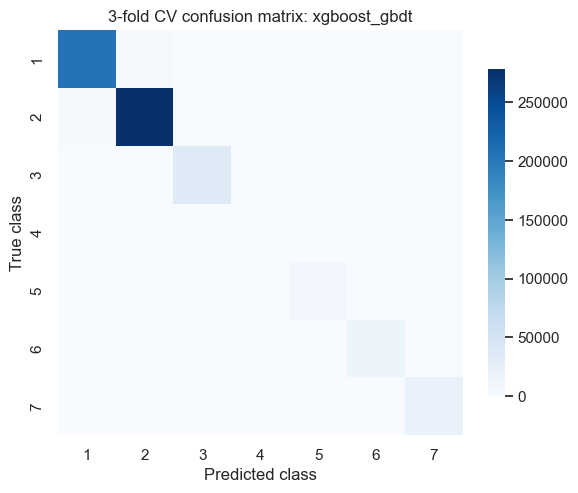

In [119]:

if (CV_REPORT_DIR / "notebook_cv_summary.csv").exists():
    cv_summary_df = pd.read_csv(CV_REPORT_DIR / "notebook_cv_summary.csv")
    display(cv_summary_df)
else:
    display(pd.DataFrame({"status": ["Run the CV cell above to create notebook_cv_summary.csv."]}))

if (CV_REPORT_DIR / "notebook_cv_stat_tests.json").exists():
    with (CV_REPORT_DIR / "notebook_cv_stat_tests.json").open("r", encoding="utf-8") as fh:
        display(json.load(fh))

if (CV_REPORT_DIR / "notebook_cv_mcnemar_tests_fold1.csv").exists():
    cv_mcnemar_df = pd.read_csv(CV_REPORT_DIR / "notebook_cv_mcnemar_tests_fold1.csv")
    display(cv_mcnemar_df.sort_values("mcnemar_exact_p").head(15))

if (CV_REPORT_DIR / "notebook_cv_confusion_matrices.csv").exists() and (CV_REPORT_DIR / "notebook_cv_summary.csv").exists():
    top_cv_model = cv_summary_df.iloc[0]["model"] if not cv_summary_df.empty else None
    if top_cv_model is not None:
        confusion_cv_df = pd.read_csv(CV_REPORT_DIR / "notebook_cv_confusion_matrices.csv")
        top_confusion = confusion_cv_df.loc[confusion_cv_df["model"] == top_cv_model]
        top_confusion = top_confusion.groupby(["true_class", "predicted_class"], as_index=False)["count"].sum()
        heatmap_data = top_confusion.pivot(index="true_class", columns="predicted_class", values="count").fillna(0)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(heatmap_data, cmap="Blues", square=True, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title(f"3-fold CV confusion matrix: {top_cv_model}")
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        plt.tight_layout()
        plt.show()


## Full Comparison Table

The comparison table now also labels each model family and saves the best final model from each family. This checks that the final stage is not only picking one overall winner, but also comparing the strongest candidate from each type of method.

In [120]:
MODEL_FAMILY = {
    "random_forest_entropy_40": "resource_tree_random_forest",
    "budgetpruned_random_forest": "resource_tree_budgetprune",
    "scale_invariant_online_linear": "online_linear",
    "l1_svm_newton_active_set": "linear_svm",
    "opf_log_euclidean": "opf_instance_graph",
    "knn_log_euclidean_loocv": "knn_instance_based",
    "efdt_nb_leaves": "stream_tree",
    "xgboost_gbdt": "prompt_boosted_tree",
    "catboost_gbdt": "prompt_boosted_tree",
    "sklearn_hist_gbdt_fallback": "prompt_boosted_tree",
    "tabular_resnet": "prompt_deep_tabular",
    "ft_transformer": "prompt_deep_tabular",
    "node_lite": "prompt_deep_tabular",
    "tabnet": "prompt_deep_tabular",
}

EXPECTED_FINAL_MODELS = [
    "random_forest_entropy_40",
    "budgetpruned_random_forest",
    "scale_invariant_online_linear",
    "l1_svm_newton_active_set",
    "opf_log_euclidean",
    "knn_log_euclidean_loocv",
    "efdt_nb_leaves",
    "xgboost_gbdt",
    "catboost_gbdt",
    "sklearn_hist_gbdt_fallback",
    "tabular_resnet",
    "ft_transformer",
    "node_lite",
    "tabnet",
]
DEEP_MODEL_NAMES = {"tabular_resnet", "ft_transformer", "node_lite", "tabnet"}
PROMPT_TREE_MODEL_NAMES = {"xgboost_gbdt", "catboost_gbdt", "sklearn_hist_gbdt_fallback"}

LITERATURE_ABLATION_COMBINED_PATH = REPORT_DIR / "notebook_literature_ablation_combined_results.csv"
LITERATURE_ABLATION_BEST_PATH = REPORT_DIR / "notebook_literature_ablation_best_configs.csv"
if "literature_ablation_results" not in globals() and LITERATURE_ABLATION_COMBINED_PATH.exists():
    literature_ablation_results = pd.read_csv(LITERATURE_ABLATION_COMBINED_PATH)
if "literature_ablation_best" not in globals() and LITERATURE_ABLATION_BEST_PATH.exists():
    literature_ablation_best = pd.read_csv(LITERATURE_ABLATION_BEST_PATH)
if "literature_ablation_results" not in globals():
    literature_ablation_results = pd.DataFrame()
if "literature_ablation_best" not in globals():
    literature_ablation_best = pd.DataFrame()

full_results_df = display_current_full_results().reset_index(drop=True)
full_results_df["model_family"] = full_results_df["model"].map(MODEL_FAMILY).fillna(full_results_df["model"])
full_results_df = full_results_df.sort_values(["accuracy", "kappa", "macro_f1"], ascending=False).reset_index(drop=True)

trained_models = set(full_results_df["model"].astype(str)) if not full_results_df.empty else set()
status_rows = []
for model_name in EXPECTED_FINAL_MODELS:
    family = MODEL_FAMILY.get(model_name, model_name)
    if model_name in trained_models:
        status = "trained_final"
        reason = "included in final comparison"
    elif model_name in DEEP_MODEL_NAMES and not optional_backend_available.get("torch", False):
        status = "skipped"
        reason = "required deep-tabular backend is not installed in this environment"
    elif model_name == "tabnet" and optional_backend_available.get("torch", False) and not optional_backend_available.get("pytorch_tabnet", False):
        status = "skipped"
        reason = "required TabNet backend is not installed"
    elif model_name in PROMPT_TREE_MODEL_NAMES and model_name not in trained_models:
        status = "not_selected_or_not_run"
        reason = "prompt tree full-training cell records only the best available prompt tree model"
    elif model_name in DEEP_MODEL_NAMES:
        status = "not_selected_or_not_run"
        reason = "full deep-tabular cell records only the best available deep model after prompt_deep tuning"
    else:
        status = "not_run"
        reason = "the corresponding full-training cell has not recorded a result in this kernel"
    status_rows.append({"model_family": family, "model": model_name, "final_status": status, "reason": reason})

final_model_status_df = pd.DataFrame(status_rows)
trained_full_results_df = full_results_df[full_results_df["model"].isin(trained_models)].copy()
best_full_by_family = (
    trained_full_results_df.sort_values(["model_family", "accuracy", "kappa", "macro_f1"], ascending=[True, False, False, False])
    .groupby("model_family", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

if not literature_ablation_results.empty:
    literature_ablation_results = literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False]).reset_index(drop=True)
    literature_ablation_best = (
        literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False])
        .groupby("ablation", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    literature_ablation_best.to_csv(LITERATURE_ABLATION_BEST_PATH, index=False)

full_results_df.to_csv(REPORT_DIR / "notebook_full_model_comparison.csv", index=False)
best_full_by_family.to_csv(REPORT_DIR / "notebook_best_full_model_by_family.csv", index=False)
final_model_status_df.to_csv(REPORT_DIR / "notebook_final_model_status.csv", index=False)

final_scope = full_results_df.copy()
final_scope["comparison_scope"] = "full_holdout_or_full_stream"
ablation_scope = literature_ablation_best.copy()
if not ablation_scope.empty:
    ablation_scope["comparison_scope"] = "sample_literature_ablation"
    ablation_scope["model_family"] = ablation_scope.get("model_family", ablation_scope["model"])
final_comparison_with_ablation = pd.concat([final_scope, ablation_scope], ignore_index=True, sort=False)
final_comparison_with_ablation.to_csv(REPORT_DIR / "notebook_final_comparison_with_literature_ablation.csv", index=False)

comparison_payload = {
    "sample_tuning_rows": int(sample_rows),
    "full_train_rows": int(len(X_train_full)),
    "full_test_rows": int(len(X_test_full)),
    "best_sample_configs": best_by_model_for_full_training.to_dict(orient="records"),
    "final_model_status": final_model_status_df.to_dict(orient="records"),
    "full_results": full_results_df.to_dict(orient="records"),
    "best_full_by_family": best_full_by_family.to_dict(orient="records"),
    "literature_ablation_results": literature_ablation_results.to_dict(orient="records") if not literature_ablation_results.empty else [],
    "literature_ablation_best": literature_ablation_best.to_dict(orient="records") if not literature_ablation_best.empty else [],
}
save_json(comparison_payload, REPORT_DIR / "notebook_full_comparison.json")

print("Final trained model results")
display(full_results_df)
print("Expected final model status")
display(final_model_status_df)
print("Best trained final model by family")
display(best_full_by_family)
print("Best literature-motivated sample ablation by group")
literature_ablation_best


Final trained model results


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle,newton_iterations,C,alpha,max_iter,backend,max_train_samples,best_k,weights,tune_k,evaluation,n,tree_type,grace_period,delta,tau,leaf_prediction,report_every,source,model_family
0,xgboost_gbdt,domain_top45_mi,0.974682,0.959333,0.950676,0.974654,0.065831,26.084,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree,prompt_boosted_tree
1,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,NaN,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,resource_tree_random_forest
2,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,NaN,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,resource_tree_budgetprune
3,tabular_resnet,domain_quantile_all,0.918789,0.869209,0.875458,0.918560,0.207558,2.527,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,59.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prompt_deep,prompt_deep_tabular
4,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179,0.911130,NaN,38.508,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,knn_instance_based
5,efdt_nb_leaves,all,0.752069,0.591300,NaN,NaN,NaN,0.047,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prequential_full_stream,581012.0,efdt,100.0,1.000000e-07,0.05,nba,50000.0,NaN,stream_tree
6,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,NaN,0.126,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,35.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.25,0.0001,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear_svm
7,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,NaN,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,online_linear
8,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,0.669224,NaN,7.522,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,opf_instance_graph


Expected final model status


,model_family,model,final_status,reason
0,resource_tree_random_forest,random_forest_entropy_40,trained_final,included in final comparison
1,resource_tree_budgetprune,budgetpruned_random_forest,trained_final,included in final comparison
2,online_linear,scale_invariant_online_linear,trained_final,included in final comparison
3,linear_svm,l1_svm_newton_active_set,trained_final,included in final comparison
4,opf_instance_graph,opf_log_euclidean,trained_final,included in final comparison
5,knn_instance_based,knn_log_euclidean_loocv,trained_final,included in final comparison
6,stream_tree,efdt_nb_leaves,trained_final,included in final comparison
7,prompt_boosted_tree,xgboost_gbdt,trained_final,included in final comparison
8,prompt_boosted_tree,catboost_gbdt,not_selected_or_not_run,prompt tree full-training cell records only th...
9,prompt_boosted_tree,sklearn_hist_gbdt_fallback,not_selected_or_not_run,prompt tree full-training cell records only th...


Best trained final model by family


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,model_path,selected_features,cache_loaded,n_estimators,criterion,max_features,min_samples_leaf,max_depth,selected_trees,feature_acquisition_cost,min_trees,budget,budget_fraction,cost_penalty,epochs,shuffle,newton_iterations,C,alpha,max_iter,backend,max_train_samples,best_k,weights,tune_k,evaluation,n,tree_type,grace_period,delta,tau,leaf_prediction,report_every,source,model_family
0,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179,0.911130,NaN,38.508,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,uniform,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,knn_instance_based
1,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,NaN,0.126,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,35.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0,0.25,0.0001,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear_svm
2,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,NaN,0.742,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,54.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,online_linear
3,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,0.669224,NaN,7.522,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,opf_instance_graph
4,xgboost_gbdt,domain_top45_mi,0.974682,0.959333,0.950676,0.974654,0.065831,26.084,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prompt_tree,prompt_boosted_tree
5,tabular_resnet,domain_quantile_all,0.918789,0.869209,0.875458,0.918560,0.207558,2.527,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,59.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prompt_deep,prompt_deep_tabular
6,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,NaN,4.794,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,80.0,entropy,0.4,1.0,NaN,80.0,45.0,5.0,29.0,0.65,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,resource_tree_budgetprune
7,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,NaN,2.798,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,45.0,True,80.0,entropy,0.4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,resource_tree_random_forest
8,efdt_nb_leaves,all,0.752069,0.591300,NaN,NaN,NaN,0.047,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,prequential_full_stream,581012.0,efdt,100.0,1.000000e-07,0.05,nba,50000.0,NaN,stream_tree


Best literature-motivated sample ablation by group


,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,log_loss,seconds,max_features,min_samples_leaf,n_estimators,max_depth,budget_fraction,cost_penalty,min_trees,budget,base_rf_accuracy,accuracy_delta_from_base_rf,selected_trees,feature_acquisition_cost,solver,base_rf_cache_path,base_rf_cache_loaded,cache_path,cache_loaded,ablation,experiment,reused_existing_result,literature_pass,epochs,C,alpha,max_train_samples,train_rows,backend,best_k,weights,delta,grace_period,leaf_prediction,stream_rows,tuning_pass,tau,reuse_source,learning_rate,reg_lambda,depth,iterations,l2_leaf_reg,l2_regularization,max_iter,max_leaf_nodes,lr,weight_decay,batch_size,width,scheduler,best_valid_loss,d_token,n_heads,n_trees,lambda_sparse,n_d,n_a,distance_transform,k_values,base_model,criterion,data_view,selected_features
0,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.857172,NaN,0.273,0.4,1.0,80.0,NaN,0.65,0.0,5.0,29.0,0.86016,0.0,80.0,45.0,lp_relaxation_fallback,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,budget_curve,budgetprune_accuracy_cost,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,knn_distance_loocv,top35_mi,0.73936,0.578459,0.603856,0.738388,NaN,0.437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,distance_metric,knn_distance_transform,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,5000.0,NaN,1.0,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,raw_euclidean,"[1, 3, 5]",NaN,NaN,NaN,NaN
2,efdt_nb_leaves,all,0.66050,0.603202,NaN,NaN,NaN,1.682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,stream_leaf_and_sensitivity,grace_period_sensitivity,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e-07,50.0,nba,10000.0,NaN,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,random_forest_feature_ablation,domain_top45_mi,0.87360,0.794309,0.796572,0.871572,NaN,0.226,0.4,1.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...,True,tree_feature_engineering,random_forest_raw_vs_domain_features,False,literature_ablation_after_related_work,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,entropy,domain_top45_mi,45.0


## Best Model Diagnostics

The next cells focus on the strongest final models rather than every tuning trial. They compare model families, runtime, saved model size, selected features, and class-level behavior. This makes the final results easier to judge than accuracy alone.


In [121]:
analysis_df = full_results_df.copy()
analysis_df["model_size_mb"] = analysis_df["model_path"].apply(
    lambda p: round(Path(p).stat().st_size / 1_048_576, 2) if isinstance(p, str) and Path(p).exists() else np.nan
)
if "selected_features" not in analysis_df.columns:
    analysis_df["selected_features"] = np.nan

rank_metrics = ["accuracy", "kappa", "macro_f1", "weighted_f1"]
available_rank_metrics = [m for m in rank_metrics if m in analysis_df.columns and analysis_df[m].notna().any()]
ranking_cols = [
    "model_family",
    "model",
    "feature_set",
    "accuracy",
    "kappa",
    "macro_f1",
    "weighted_f1",
    "seconds",
    "selected_features",
    "model_size_mb",
    "model_path",
]
ranking_cols = [c for c in ranking_cols if c in analysis_df.columns]

trained_ranking = analysis_df[ranking_cols].sort_values(["accuracy", "kappa", "macro_f1"], ascending=False)
missing_or_skipped = final_model_status_df.loc[
    final_model_status_df["final_status"] != "trained_final",
    ["model_family", "model", "final_status", "reason"],
]

print("Trained final models")
display(trained_ranking)
print("Expected models not included in the final trained-results table")
missing_or_skipped


Trained final models


,model_family,model,feature_set,accuracy,kappa,macro_f1,weighted_f1,seconds,selected_features,model_size_mb,model_path
0,prompt_boosted_tree,xgboost_gbdt,domain_top45_mi,0.974682,0.959333,0.950676,0.974654,26.084,45.0,52.36,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
1,resource_tree_random_forest,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,0.968744,2.798,45.0,415.37,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
2,resource_tree_budgetprune,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,0.964567,4.794,45.0,361.83,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
3,prompt_deep_tabular,tabular_resnet,domain_quantile_all,0.918789,0.869209,0.875458,0.918560,2.527,59.0,1.58,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
4,knn_instance_based,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179,0.911130,38.508,45.0,163.13,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
5,stream_tree,efdt_nb_leaves,all,0.752069,0.591300,NaN,NaN,0.047,NaN,1.99,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
6,linear_svm,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.687432,0.126,35.0,0.01,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
7,online_linear,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.684009,0.742,54.0,0.01,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
8,opf_instance_graph,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,0.669224,7.522,45.0,1.89,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...


Expected models not included in the final trained-results table


,model_family,model,final_status,reason
8,prompt_boosted_tree,catboost_gbdt,not_selected_or_not_run,prompt tree full-training cell records only th...
9,prompt_boosted_tree,sklearn_hist_gbdt_fallback,not_selected_or_not_run,prompt tree full-training cell records only th...
11,prompt_deep_tabular,ft_transformer,not_selected_or_not_run,full deep-tabular cell records only the best a...
12,prompt_deep_tabular,node_lite,not_selected_or_not_run,full deep-tabular cell records only the best a...
13,prompt_deep_tabular,tabnet,not_selected_or_not_run,full deep-tabular cell records only the best a...


**Interpretation.** Accuracy and Kappa show overall performance, while macro-F1 checks whether the model is doing well across smaller cover types too. Runtime, selected features, and model size show the resource cost. A model is more practical when it keeps strong accuracy without becoming too slow or too large.


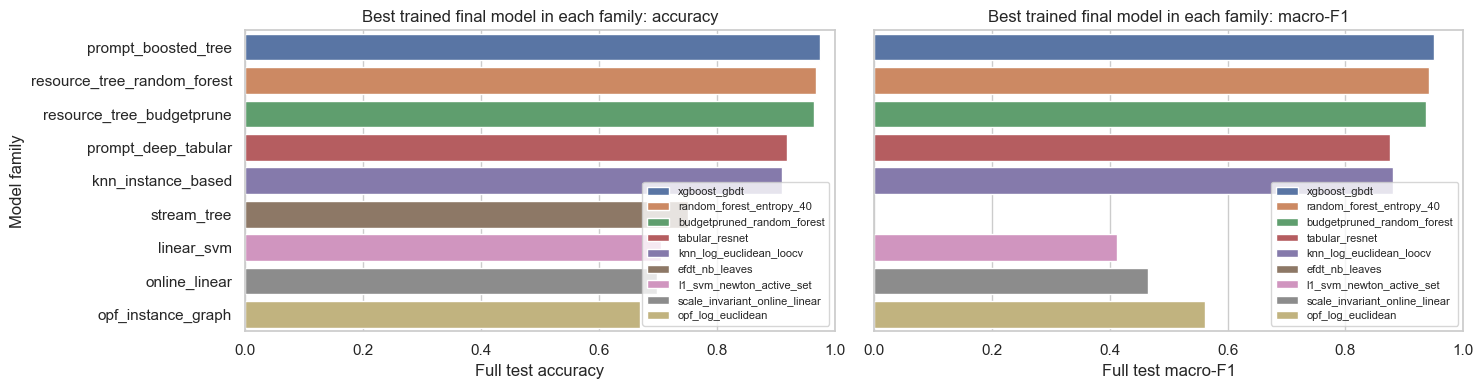

Best trained final model by family


,model_family,model,feature_set,accuracy,kappa,macro_f1,seconds,selected_features,model_size_mb
0,prompt_boosted_tree,xgboost_gbdt,domain_top45_mi,0.974682,0.959333,0.950676,26.084,45.0,52.36
1,resource_tree_random_forest,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411,2.798,45.0,415.37
2,resource_tree_budgetprune,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304,4.794,45.0,361.83
3,prompt_deep_tabular,tabular_resnet,domain_quantile_all,0.918789,0.869209,0.875458,2.527,59.0,1.58
4,knn_instance_based,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179,38.508,45.0,163.13
5,stream_tree,efdt_nb_leaves,all,0.752069,0.591300,NaN,0.047,NaN,1.99
6,linear_svm,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213,0.126,35.0,0.01
7,online_linear,scale_invariant_online_linear,all,0.699216,0.503992,0.465408,0.742,54.0,0.01
8,opf_instance_graph,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924,7.522,45.0,1.89


Family coverage, including skipped deep-learning models


,model_family,trained_models,model_statuses
0,knn_instance_based,True,trained_final
1,linear_svm,True,trained_final
2,online_linear,True,trained_final
3,opf_instance_graph,True,trained_final
4,prompt_boosted_tree,True,"not_selected_or_not_run, trained_final"
5,prompt_deep_tabular,True,"not_selected_or_not_run, trained_final"
6,resource_tree_budgetprune,True,trained_final
7,resource_tree_random_forest,True,trained_final
8,stream_tree,True,trained_final


In [122]:
family_view = best_full_by_family.copy()
if not family_view.empty:
    family_view["model_size_mb"] = family_view["model_path"].apply(
        lambda p: round(Path(p).stat().st_size / 1_048_576, 2) if isinstance(p, str) and Path(p).exists() else np.nan
    )
    family_view = family_view.sort_values("accuracy", ascending=False).reset_index(drop=True)

family_status_view = final_model_status_df.copy()
family_status_view["family_has_trained_result"] = family_status_view["model_family"].isin(family_view["model_family"] if not family_view.empty else [])
family_status_summary = (
    family_status_view.groupby("model_family", as_index=False)
    .agg(
        trained_models=("family_has_trained_result", "max"),
        model_statuses=("final_status", lambda values: ", ".join(sorted(set(values)))),
    )
    .sort_values("model_family")
)

if not family_view.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, 0.45 * len(family_view))), sharey=True)
    sns.barplot(data=family_view, y="model_family", x="accuracy", hue="model", dodge=False, ax=axes[0])
    axes[0].set_title("Best trained final model in each family: accuracy")
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel("Full test accuracy")
    axes[0].set_ylabel("Model family")
    axes[0].legend(loc="lower right", fontsize=8)

    sns.barplot(data=family_view, y="model_family", x="macro_f1", hue="model", dodge=False, ax=axes[1])
    axes[1].set_title("Best trained final model in each family: macro-F1")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Full test macro-F1")
    axes[1].set_ylabel("")
    axes[1].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

print("Best trained final model by family")
display(family_view[["model_family", "model", "feature_set", "accuracy", "kappa", "macro_f1", "seconds", "selected_features", "model_size_mb"]] if not family_view.empty else family_view)
print("Family coverage, including skipped deep-learning models")
family_status_summary


**Interpretation.** This is the fairest summary table for the end of the notebook: each method type gets one representative, selected by full-test performance. If one family is much faster or much smaller with only a small loss in accuracy, it may be a better deployment choice than the absolute top model.


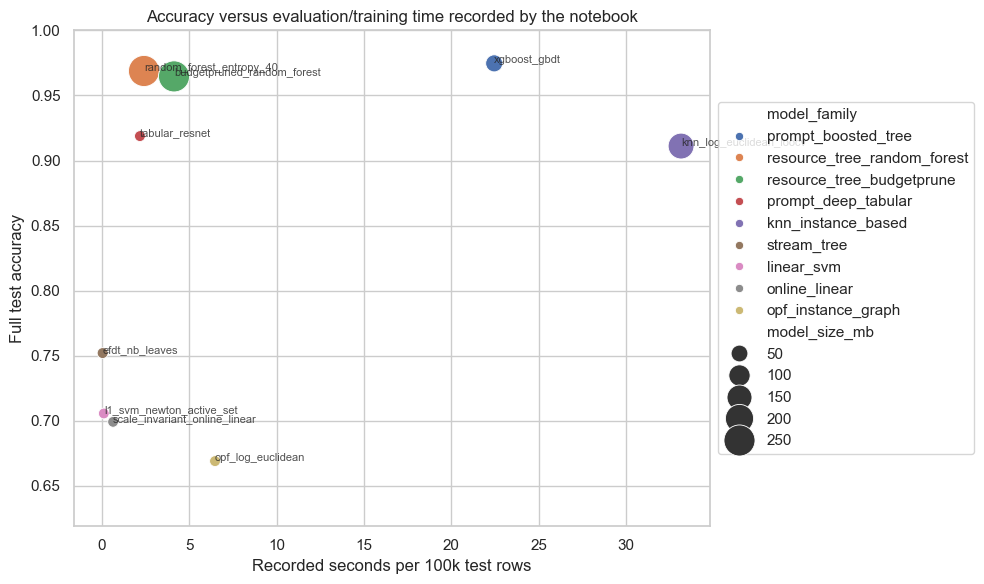

,model,model_family,accuracy,seconds,seconds_per_100k_test_rows,model_size_mb,selected_features
0,xgboost_gbdt,prompt_boosted_tree,0.974682,26.084,22.446925,52.36,45.0
1,random_forest_entropy_40,resource_tree_random_forest,0.968822,2.798,2.407855,415.37,45.0
2,budgetpruned_random_forest,resource_tree_budgetprune,0.964657,4.794,4.125539,361.83,45.0
3,tabular_resnet,prompt_deep_tabular,0.918789,2.527,2.174643,1.58,59.0
4,knn_log_euclidean_loocv,knn_instance_based,0.911138,38.508,33.138559,163.13,45.0
5,efdt_nb_leaves,stream_tree,0.752069,0.047,0.040446,1.99,NaN
6,l1_svm_newton_active_set,linear_svm,0.705662,0.126,0.108431,0.01,35.0
7,scale_invariant_online_linear,online_linear,0.699216,0.742,0.638538,0.01,54.0
8,opf_log_euclidean,opf_instance_graph,0.669062,7.522,6.473155,1.89,45.0


In [123]:
resource_df = analysis_df.dropna(subset=["seconds", "accuracy"]).copy()
resource_df["seconds_per_100k_test_rows"] = resource_df["seconds"] / max(len(X_test_full), 1) * 100_000

fig, ax = plt.subplots(figsize=(10, 6))
size_for_plot = resource_df["model_size_mb"].fillna(resource_df["model_size_mb"].median())
size_for_plot = np.clip(size_for_plot, 1, 250)
sns.scatterplot(
    data=resource_df,
    x="seconds_per_100k_test_rows",
    y="accuracy",
    hue="model_family",
    size=size_for_plot,
    sizes=(60, 500),
    ax=ax,
)
for _, row in resource_df.iterrows():
    ax.annotate(row["model"], (row["seconds_per_100k_test_rows"], row["accuracy"]), fontsize=8, alpha=0.8)
ax.set_title("Accuracy versus evaluation/training time recorded by the notebook")
ax.set_xlabel("Recorded seconds per 100k test rows")
ax.set_ylabel("Full test accuracy")
ax.set_ylim(max(0, resource_df["accuracy"].min() - 0.05), 1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

resource_df[["model", "model_family", "accuracy", "seconds", "seconds_per_100k_test_rows", "model_size_mb", "selected_features"]].sort_values("accuracy", ascending=False)


**Interpretation.** This chart is a practical resource view. Models near the top-left are preferable because they are accurate and cheap. Large points indicate larger saved models, which matters when disk or memory is limited.


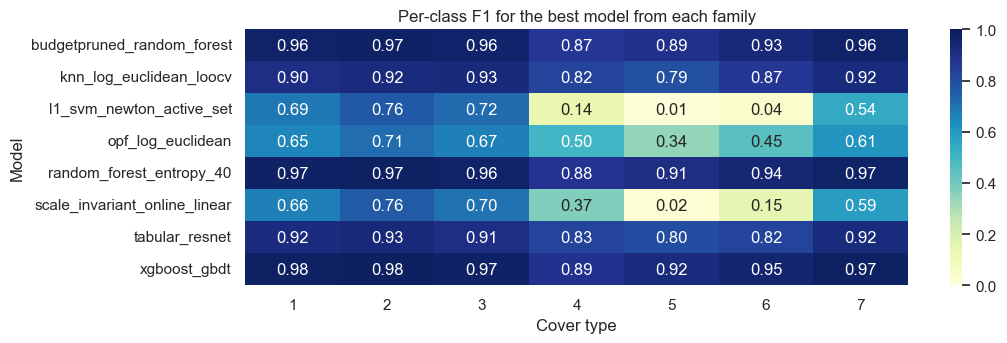

,cover_type,mean_f1,min_f1,support
4,5,0.584729,0.005230,1899.0
5,6,0.643703,0.041401,3473.0
3,4,0.662361,0.135747,549.0
6,7,0.812118,0.544503,4102.0
0,1,0.841248,0.650679,42368.0
2,3,0.851298,0.666009,7151.0
1,2,0.876919,0.713650,56661.0


In [124]:
if "per_class_df" not in globals() or per_class_df.empty:
    per_class_rows = []
    for model_name, report in full_reports.items():
        for label in sorted([k for k in report.keys() if k.isdigit()], key=int):
            per_class_rows.append(
                {
                    "model": model_name,
                    "cover_type": int(label),
                    "precision": report[label]["precision"],
                    "recall": report[label]["recall"],
                    "f1": report[label]["f1-score"],
                    "support": report[label]["support"],
                }
            )
    per_class_df = pd.DataFrame(per_class_rows)

best_models_for_heatmap = best_full_by_family["model"].drop_duplicates().tolist()
heatmap_df = per_class_df[per_class_df["model"].isin(best_models_for_heatmap)].copy()

if not heatmap_df.empty:
    f1_matrix = heatmap_df.pivot_table(index="model", columns="cover_type", values="f1")
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * len(f1_matrix))))
    sns.heatmap(f1_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
    ax.set_title("Per-class F1 for the best model from each family")
    ax.set_xlabel("Cover type")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()

    hard_classes = (
        heatmap_df.groupby("cover_type", as_index=False)
        .agg(mean_f1=("f1", "mean"), min_f1=("f1", "min"), support=("support", "max"))
        .sort_values("mean_f1")
    )
    display(hard_classes)
else:
    display(pd.DataFrame({"note": ["No per-class reports are available yet. Run the full model cells first."]}))


**Interpretation.** The heatmap shows whether the best models are only good on common classes or also work on minority classes. Low values in the same cover type across many models usually mean the class is hard because it has fewer examples, overlaps with nearby ecological conditions, or both.


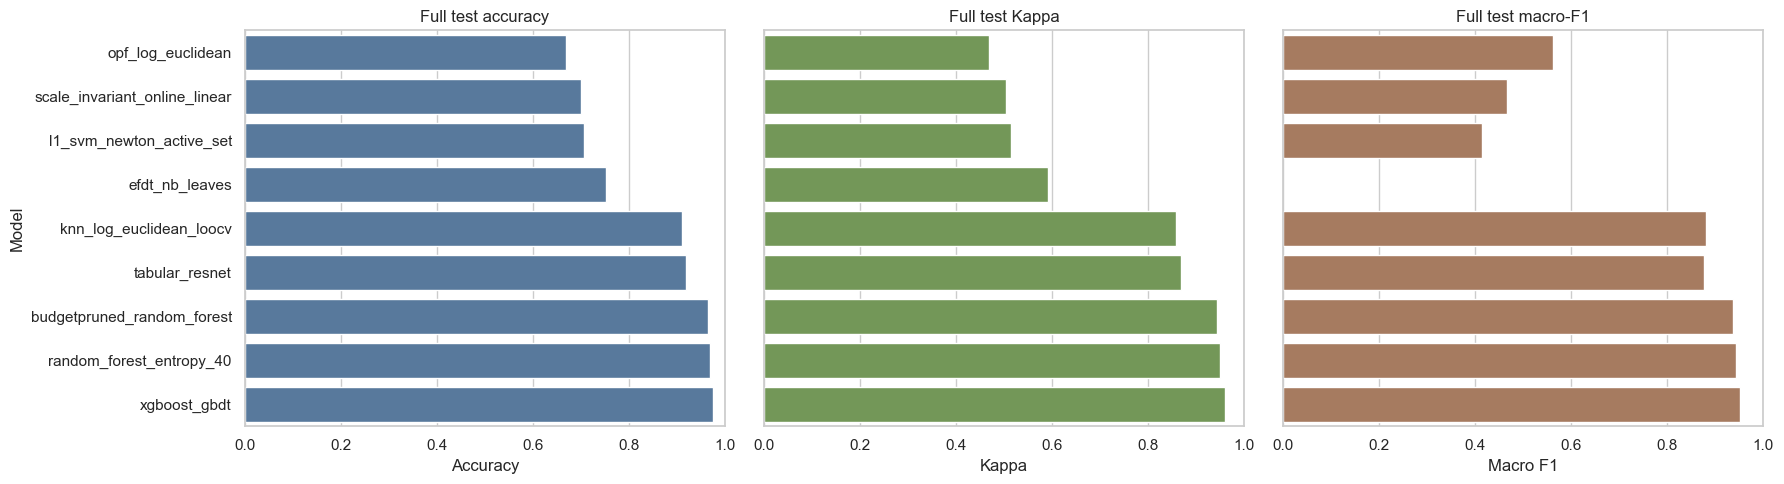

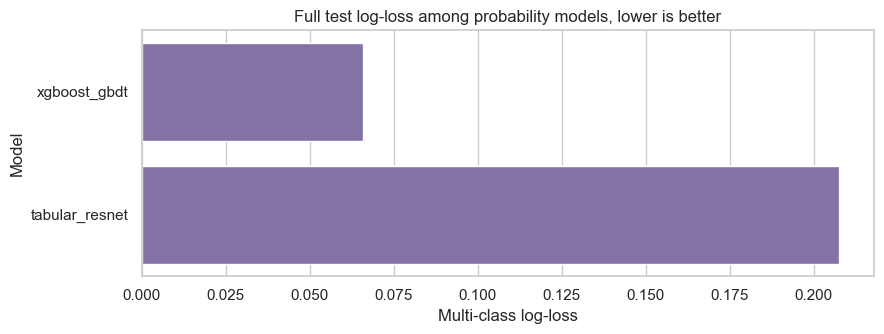

In [125]:
plot_metrics = ["accuracy", "kappa", "macro_f1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_df = full_results_df.sort_values("accuracy", ascending=True)

for ax, metric, color, title in zip(
    axes,
    plot_metrics,
    ["#4c78a8", "#72a24d", "#b27954"],
    ["Full test accuracy", "Full test Kappa", "Full test macro-F1"],
):
    sns.barplot(data=plot_df, y="model", x=metric, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_ylabel("Model" if ax is axes[0] else "")

plt.tight_layout()
plt.show()

loss_df = pd.DataFrame()
if "log_loss" in full_results_df.columns:
    loss_df = full_results_df.dropna(subset=["log_loss"]).sort_values("log_loss", ascending=True)

if len(loss_df) >= 2:
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.45 * len(loss_df))))
    sns.barplot(data=loss_df, y="model", x="log_loss", color="#7f6aad", ax=ax)
    ax.set_title("Full test log-loss among probability models, lower is better")
    ax.set_xlabel("Multi-class log-loss")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()
elif len(loss_df) == 1:
    display(pd.DataFrame({
        "note": ["Only one final model produced class probabilities, so a log-loss bar chart is not a real comparison."],
        "model": [loss_df.iloc[0]["model"]],
        "log_loss": [loss_df.iloc[0]["log_loss"]],
    }))
else:
    display(pd.DataFrame({"note": ["No final model produced probability outputs for log-loss in this run."]}))


## Literature-Ablation Addendum for Final Comparison

The table below keeps the full-test results separate from the sample ablations. This prevents sample validation scores from being treated as final model scores, while still showing which literature-driven ideas are worth testing on the full dataset next.

,ablation,experiment,model,feature_set,accuracy,kappa,macro_f1,budget_fraction,cost_penalty,distance_transform,leaf_prediction,data_view,reused_existing_result
0,budget_curve,budgetprune_accuracy_cost,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.65,0.0000,NaN,NaN,NaN,False
1,budget_curve,budgetprune_accuracy_cost,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.65,0.0001,NaN,NaN,NaN,False
2,budget_curve,budgetprune_accuracy_cost,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.65,0.0010,NaN,NaN,NaN,True
3,budget_curve,budgetprune_accuracy_cost,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.65,0.0100,NaN,NaN,NaN,True
4,budget_curve,budgetprune_accuracy_cost,budgetpruned_random_forest,top45_mi,0.86016,0.772115,0.766350,0.80,0.0000,NaN,NaN,NaN,False
5,distance_metric,knn_distance_transform,knn_distance_loocv,top35_mi,0.73936,0.578459,0.603856,NaN,NaN,raw_euclidean,NaN,NaN,False
6,distance_metric,knn_distance_transform,knn_distance_loocv,top35_mi,0.73936,0.578459,0.603856,NaN,NaN,raw_euclidean,NaN,NaN,False
7,distance_metric,knn_distance_transform,knn_distance_loocv,top45_mi,0.73936,0.578459,0.603856,NaN,NaN,raw_euclidean,NaN,NaN,False
8,distance_metric,knn_distance_transform,knn_distance_loocv,top45_mi,0.73936,0.578459,0.603856,NaN,NaN,raw_euclidean,NaN,NaN,False
9,distance_metric,knn_distance_transform,knn_distance_loocv,top45_mi,0.73184,0.569920,0.601428,NaN,NaN,standardized_euclidean,NaN,NaN,False


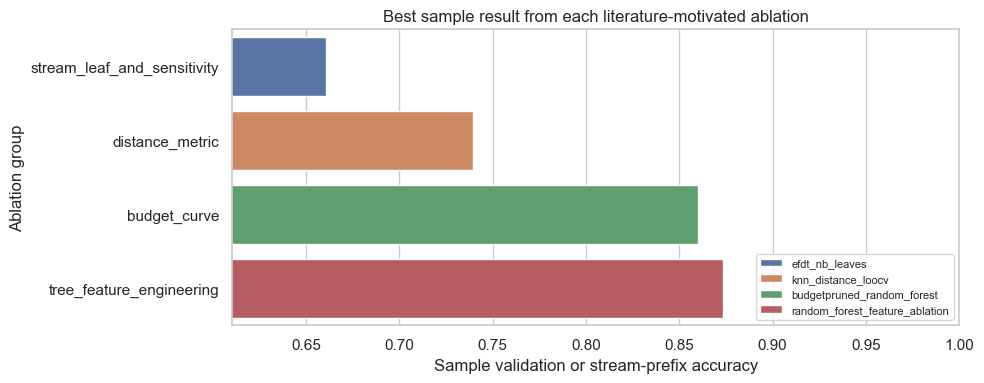

,comparison_scope,model,feature_set,accuracy,kappa,macro_f1
0,full_holdout_or_full_stream,xgboost_gbdt,domain_top45_mi,0.974682,0.959333,0.950676
1,full_holdout_or_full_stream,random_forest_entropy_40,top45_mi,0.968822,0.949862,0.942411
2,full_holdout_or_full_stream,budgetpruned_random_forest,top45_mi,0.964657,0.943143,0.936304
3,full_holdout_or_full_stream,tabular_resnet,domain_quantile_all,0.918789,0.869209,0.875458
4,full_holdout_or_full_stream,knn_log_euclidean_loocv,top45_mi,0.911138,0.857341,0.880179
5,full_holdout_or_full_stream,efdt_nb_leaves,all,0.752069,0.591300,NaN
6,full_holdout_or_full_stream,l1_svm_newton_active_set,top35_mi,0.705662,0.514318,0.413213
7,full_holdout_or_full_stream,scale_invariant_online_linear,all,0.699216,0.503992,0.465408
8,full_holdout_or_full_stream,opf_log_euclidean,top45_mi,0.669062,0.467972,0.561924
12,sample_literature_ablation,random_forest_feature_ablation,domain_top45_mi,0.873600,0.794309,0.796572


In [126]:
if "literature_ablation_results" not in globals() or literature_ablation_results.empty:
    path = REPORT_DIR / "notebook_literature_ablation_combined_results.csv"
    literature_ablation_results = pd.read_csv(path) if path.exists() else pd.DataFrame()

if literature_ablation_results.empty:
    display(pd.DataFrame({"note": ["No literature-ablation results are available yet. Run the literature ablation cells above, or set LITERATURE_ABLATION_ALLOW_NEW_TRAINING=False to only report missing configs."]}))
else:
    ablation_summary = (
        literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False])
        .groupby("ablation", as_index=False)
        .head(5)
        .reset_index(drop=True)
    )
    summary_cols = [
        "ablation",
        "experiment",
        "model",
        "feature_set",
        "accuracy",
        "kappa",
        "macro_f1",
        "budget_fraction",
        "cost_penalty",
        "distance_transform",
        "leaf_prediction",
        "data_view",
        "reused_existing_result",
    ]
    summary_cols = [c for c in summary_cols if c in ablation_summary.columns]
    display(ablation_summary[summary_cols])

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * literature_ablation_results["ablation"].nunique())))
    best_for_plot = (
        literature_ablation_results.sort_values(["ablation", "accuracy", "kappa"], ascending=[True, False, False])
        .groupby("ablation", as_index=False)
        .head(1)
        .sort_values("accuracy", ascending=True)
    )
    sns.barplot(data=best_for_plot, y="ablation", x="accuracy", hue="model", dodge=False, ax=ax)
    ax.set_title("Best sample result from each literature-motivated ablation")
    ax.set_xlabel("Sample validation or stream-prefix accuracy")
    ax.set_ylabel("Ablation group")
    ax.set_xlim(max(0, best_for_plot["accuracy"].min() - 0.05), 1)
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    full_vs_ablation = pd.concat(
        [
            full_results_df.assign(comparison_scope="full_holdout_or_full_stream"),
            best_for_plot.assign(comparison_scope="sample_literature_ablation"),
        ],
        ignore_index=True,
        sort=False,
    )
    full_vs_ablation.to_csv(REPORT_DIR / "notebook_final_comparison_with_literature_ablation.csv", index=False)
    display(full_vs_ablation[["comparison_scope", "model", "feature_set", "accuracy", "kappa", "macro_f1"]].sort_values(["comparison_scope", "accuracy"], ascending=[True, False]))


**Interpretation.** The final winner should still be chosen from the full-test table. The ablation addendum is for methodological evidence: if the budget curve keeps accuracy close while lowering feature cost, the pruned forest is stronger for resource-aware deployment; if Naive Bayes leaves beat majority leaves, the stream-tree design is justified; if Log-Euclidean k-NN wins over raw or standardized Euclidean distance, the distance preprocessing is justified; and if domain features improve the tree sample score, they should be promoted to full training.

## Per-Class Comparison

In [127]:
per_class_rows = []
for model_name, report in full_reports.items():
    for label in sorted([k for k in report.keys() if k.isdigit()], key=int):
        per_class_rows.append(
            {
                "model": model_name,
                "cover_type": int(label),
                "precision": report[label]["precision"],
                "recall": report[label]["recall"],
                "f1": report[label]["f1-score"],
                "support": report[label]["support"],
            }
        )

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(REPORT_DIR / "notebook_full_per_class_metrics.csv", index=False)
per_class_df.head(1000)


,model,cover_type,precision,recall,f1,support
0,random_forest_entropy_40,1,0.972111,0.965870,0.968981,42368.0
1,random_forest_entropy_40,2,0.969980,0.978557,0.974249,56661.0
2,random_forest_entropy_40,3,0.955353,0.969515,0.962382,7151.0
3,random_forest_entropy_40,4,0.902111,0.856102,0.878505,549.0
4,random_forest_entropy_40,5,0.950318,0.866245,0.906336,1899.0
5,random_forest_entropy_40,6,0.952282,0.925137,0.938513,3473.0
6,random_forest_entropy_40,7,0.972674,0.963189,0.967908,4102.0
7,budgetpruned_random_forest,1,0.969624,0.959852,0.964713,42368.0
8,budgetpruned_random_forest,2,0.964856,0.976351,0.970569,56661.0
9,budgetpruned_random_forest,3,0.951842,0.964620,0.958189,7151.0


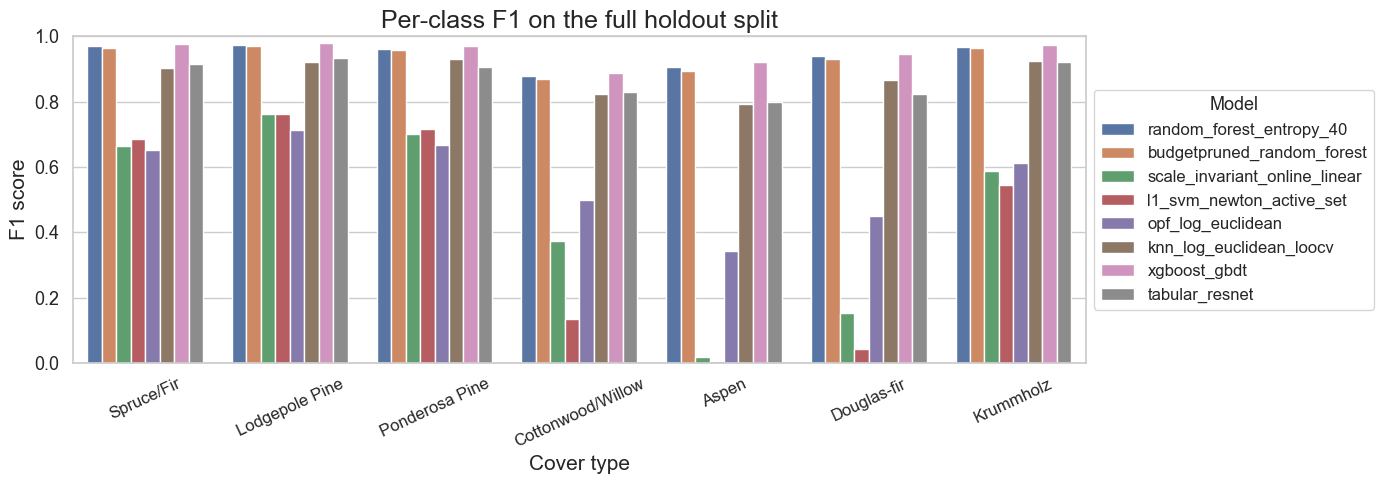

In [128]:
cover_type_labels = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz",
}

per_class_plot_df = per_class_df.copy()
per_class_plot_df["cover_type_label"] = (
    per_class_plot_df["cover_type"]
    .astype(int)
    .map(cover_type_labels)
)

if not per_class_plot_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))

    sns.barplot(
        data=per_class_plot_df,
        x="cover_type_label",
        y="f1",
        hue="model",
        ax=ax,
    )

    ax.set_title("Per-class F1 on the full holdout split", fontsize=18)
    ax.set_xlabel("Cover type", fontsize=15)
    ax.set_ylabel("F1 score", fontsize=15)

    ax.tick_params(axis="x", labelsize=12, rotation=25)
    ax.tick_params(axis="y", labelsize=13)

    ax.set_ylim(0, 1)

    ax.legend(
        title="Model",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=12,
        title_fontsize=13,
    )

    plt.tight_layout()
    plt.show()


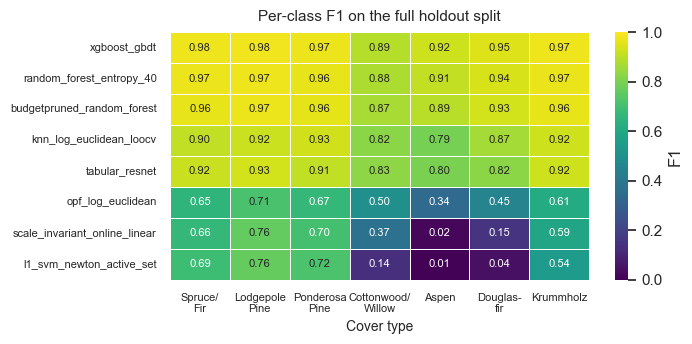

In [129]:
cover_type_labels_short = {
    1: "Spruce/\nFir",
    2: "Lodgepole\nPine",
    3: "Ponderosa\nPine",
    4: "Cottonwood/\nWillow",
    5: "Aspen",
    6: "Douglas-\nfir",
    7: "Krummholz",
}

per_class_plot_df = per_class_df.copy()
per_class_plot_df["cover_type"] = per_class_plot_df["cover_type"].astype(int)
per_class_plot_df["cover_type_label"] = per_class_plot_df["cover_type"].map(cover_type_labels_short)

heatmap_df = (
    per_class_plot_df
    .pivot_table(
        index="model",
        columns="cover_type_label",
        values="f1",
        aggfunc="mean",
    )
    .reindex(columns=list(cover_type_labels_short.values()))
)

model_order = heatmap_df.mean(axis=1).sort_values(ascending=False).index
heatmap_df = heatmap_df.loc[model_order]

fig, ax = plt.subplots(figsize=(7.2, 3.6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "F1"},
    annot_kws={"fontsize": 8},
    ax=ax,
)

ax.set_title("Per-class F1 on the full holdout split", fontsize=11, pad=8)
ax.set_xlabel("Cover type", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=8, rotation=0)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/per_class_f1_heatmap.png", bbox_inches="tight")

plt.show()


Plot for paper

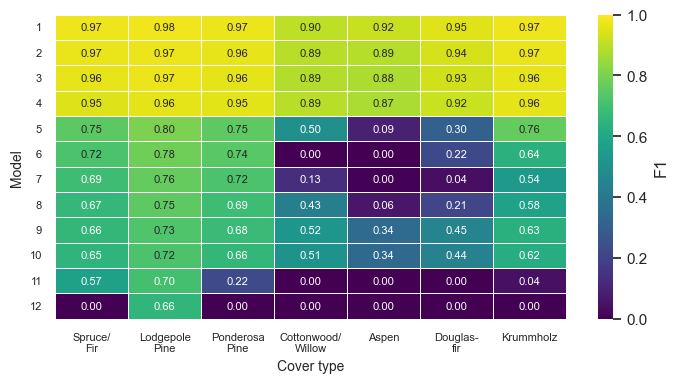

Figure X. Mean per-class F1 across 3-fold cross-validation. Models: 1 XGBoost; 2 RF; 3 BP RF; 4 CatBoost; 5 Tabular ResNet; 6 FT-Transformer; 7 $\ell_1$ SVM; 8 Scale-inv. linear; 9 Log-Euclidean k-NN; 10 OPF-style; 11 TabNet; 12 EFDT/NB leaves.


In [ ]:
from pathlib import Path

cover_type_labels_short = {
    1: "Spruce/\nFir",
    2: "Lodgepole\nPine",
    3: "Ponderosa\nPine",
    4: "Cottonwood/\nWillow",
    5: "Aspen",
    6: "Douglas-\nfir",
    7: "Krummholz",
}

model_display_names = {
    "xgboost_gbdt": "XGBoost",
    "random_forest_entropy_40": "RF",
    "budgetpruned_random_forest": "BP RF",
    "catboost_gbdt": "CatBoost",
    "sklearn_hist_gbdt_fallback": "HistGBDT",
    "tabular_resnet": "Tabular ResNet",
    "ft_transformer": "FT-Transformer",
    "logistic_regression_l2": "Logistic Reg.",
    "l1_svm_newton_active_set": r"$\ell_1$ SVM",
    "scale_invariant_online_linear": "Scale-inv. linear",
    "knn_log_euclidean_loocv": "Log-Euclidean k-NN",
    "linear_discriminant_shrinkage": "LDA",
    "opf_log_euclidean": "OPF-style",
    "tabnet": "TabNet",
    "efdt_nb_leaves": "EFDT/NB leaves",
    "node_lite": "NODE-lite",
}

cv_per_class_path = Path("reports/notebook_cv/notebook_cv_per_class_metrics.csv")
cv_summary_path = Path("reports/notebook_cv/notebook_cv_summary.csv")

cv_per_class_df = pd.read_csv(cv_per_class_path)
cv_summary_df = pd.read_csv(cv_summary_path)

per_class_plot_df = cv_per_class_df.rename(columns={"class": "cover_type"}).copy()
per_class_plot_df["cover_type"] = per_class_plot_df["cover_type"].astype(int)
per_class_plot_df["cover_type_label"] = per_class_plot_df["cover_type"].map(cover_type_labels_short)


heatmap_df = (
    per_class_plot_df
    .pivot_table(
        index="model",
        columns="cover_type_label",
        values="f1",
        aggfunc="mean",
    )
    .reindex(columns=list(cover_type_labels_short.values()))
)

excluded_models = {"sklearn_hist_gbdt_fallback", "node_lite", "linear_discriminant_shrinkage", "logistic_regression_l2"}

model_order = (
    cv_summary_df[~cv_summary_df["model"].isin(excluded_models)]
    .sort_values("accuracy_mean", ascending=False)["model"]
    .tolist()
)

heatmap_df = heatmap_df.reindex(model_order).dropna(how="all")
model_number_map = {model: i + 1 for i, model in enumerate(heatmap_df.index)}
heatmap_df.index = [str(model_number_map[model]) for model in heatmap_df.index]

fig, ax = plt.subplots(figsize=(7.2, max(4.0, 0.32 * len(heatmap_df))))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "F1"},
    annot_kws={"fontsize": 8},
    ax=ax,
)

ax.set_title("")
ax.set_xlabel("Cover type", fontsize=10)
ax.set_ylabel("Model", fontsize=10)
ax.tick_params(axis="x", labelsize=8, rotation=0)
ax.tick_params(axis="y", labelsize=8, rotation=0)

plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/cv_per_class_f1_heatmap_numbered.png", bbox_inches="tight", dpi=300)

plt.show()

caption_model_list = "; ".join(
    f"{model_number_map[model]} {model_display_names.get(model, model)}"
    for model in model_order
    if model in model_number_map
)

print(
    "Figure X. Mean per-class F1 across 3-fold cross-validation. "
    f"Models: {caption_model_list}."
)

## Reload the Best Saved Model

In [131]:
best_full = full_results_df.iloc[0]
best_model_path = Path(best_full["model_path"])

if best_model_path.suffix == ".pkl":
    import pickle
    with best_model_path.open("rb") as fh:
        reloaded_model = pickle.load(fh)
else:
    reloaded_model = joblib.load(best_model_path)

pd.DataFrame({"best_model": [best_full["model"]], "path": [str(best_model_path)]})


,best_model,path
0,xgboost_gbdt,c:\Users\vladm\VisualStudioCodeProjects\ATW Co...
